# Phyloseq analysis
- going to use CCD's 16S data and PS object to compare to my seqs
- CCD workflow here: https://github.com/cdesouza02/BEL_16S_ITS2/blob/main/BEL_16S_outputs/ps_processing.ipynb

In [1]:
getwd()

[1] "/project/pi_sarah_gignouxwolfsohn_uml_edu/brooke/CBC_metagenomics/all_sctld"

In [2]:
library(tidyverse)
library(vegan)
library(dplyr)
library(phyloseq)
#library(VennDiagram)
library("DESeq2")
library(RColorBrewer)
library(ggplot2)
library(cowplot)
library(lubridate)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.3     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute

Loading required package: lattice

This is vegan 2.6-5

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:s

## Upload and Clean Data

In [3]:
# upload CCD's phyloseq object
ps<-readRDS(file = "/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/BEL_16S_outputs/ps_16S.rds")
#removing any taxa that don't show up in any samples to speed up the process
ps

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 268938 taxa and 479 samples ]
sample_data() Sample Data:       [ 479 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 268938 taxa by 6 taxonomic ranks ]

In [4]:
# remove low read counts
ps_high <- prune_samples(sample_sums(ps) >= 10000, ps)

In [5]:
# which samples were removed?
setdiff(sample_names(ps), sample_names(ps_high))

[1] "122022_BEL_CBC_T3_142_MCAV" "042024_BEL_CBC_T3_960_OFAV"
[3] "Negative"                   "012024_BEL_CBC_T1_561_OANN"
[5] "Negative.4"

In [6]:
#isolate just bacteria
ps_bac=subset_taxa(ps_high, Kingdom=="Bacteria")
#remove chloroplast order
ps_nochlo=subset_taxa(ps_bac, Order!="Chloroplast")
#remove mitochondria Family
ps_nomit=subset_taxa(ps_nochlo, Family!="Mitochondria")

#removing any taxa that don't show up in any samples to speed up the process
ps_prune <- prune_taxa(taxa_sums(ps_nomit) > 0, ps_nomit)
ps_prune

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46536 taxa and 474 samples ]
sample_data() Sample Data:       [ 474 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 46536 taxa by 6 taxonomic ranks ]

In [7]:
# subset sctld samples
ps_sctld<-subset_samples(ps_prune, Month_year %in% c("Jun 2019", "Oct 2019", "May 2022", "Dec 2022"))

### Replace metadata

In [8]:
# upload my PS metadata
bks_ps<-readRDS(file = "/project/pi_sarah_gignouxwolfsohn_uml_edu/brooke/CBC_metagenomics/all_sctld/raw_sctld_metagenomics.rds")
bks_meta<-data.frame(sample_data(bks_ps))
# sample_data=read.csv('/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/CBC_samples.csv', header = TRUE)
# colony=read.csv('/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/CBC_ColonyData.csv',header=TRUE)

In [9]:
# caroline's metadata
meta_df<-data.frame(sample_data(ps_sctld))
# adjust colony id labels to match my metadata
meta_df$colony_id<-paste0("T", meta_df$colony,"_",meta_df$Species)

In [10]:
# filter to match my samples
bks_samples<-rownames(bks_meta)
filtered_meta<-meta_df %>%
    filter(rownames(meta_df) %in% bks_samples)

In [11]:
# which samples does caroline have 
# which samples do i have 
ccd_samples<-rownames(meta_df)
shared_samples<-intersect(bks_samples,ccd_samples)

# shared sample list

In [12]:
# add tubelabel species back to mine 
bks_meta <- bks_meta %>%
  rownames_to_column("Tubelabel_species")

In [13]:
shared_bks_meta<-bks_meta %>%
    filter(Tubelabel_species %in% shared_samples)
dim(shared_bks_meta)
# 133 sample subset 

[1] 133  23

In [14]:
# add RS status, date conditions, from my metadata
filtered_meta<-filtered_meta %>%
    left_join(bks_meta %>% select(colony_id, Tubelabel_species, sampleid, group, X062019_Condition, X102019_Condition, X052022_Condition, 
                                  X122022_Condition, X092023_Condition, RS, year),
              by = c('colony_id','Tubelabel_species'))
# set tubelabel species as row names
rownames(filtered_meta) <- filtered_meta$Tubelabel_species

In [15]:
dim(filtered_meta)

[1] 133  20

In [16]:
head(filtered_meta)

,Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted,Tubelabel_species,colony_id,sampleid,group,X062019_Condition,X102019_Condition,X052022_Condition,X122022_Condition,X092023_Condition,RS,year
,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
052022_BEL_CBC_T3_11_PAST,Healthy,3_6,2_24_2025,Healthy,PAST,May 2022,1,Lagoon,2022-05-20,052022_BEL_CBC_T3_11_PAST,T3_6_PAST,052022_T3_11_PAST,52022_PAST_Healthy,Healthy,,Healthy,Healthy,CLB,Resistant,2022
062019_BEL_CBC_T1_22_MCAV,Healthy,1_24,2_24_2025,Healthy,MCAV,Jun 2019,1,CBC30N,2019-06-24,062019_BEL_CBC_T1_22_MCAV,T1_24_MCAV,062019_T1_22_MCAV,62019_MCAV_Healthy,Healthy,,Healthy,Healthy,CLP,Resistant,2019
052022_BEL_CBC_T2_71_OFAV,Healthy,2_79,2_24_2025,Healthy,OFAV,May 2022,1,SR30N,2022-05-24,052022_BEL_CBC_T2_71_OFAV,T2_79_OFAV,052022_T2_71_OFAV,52022_OFAV_Healthy,NA,,Healthy,Healthy,CLB,Resistant,2022
052022_BEL_CBC_T3_8_PAST,Healthy,3_10,2_24_2025,Healthy,PAST,May 2022,1,Lagoon,2022-05-20,052022_BEL_CBC_T3_8_PAST,T3_10_PAST,052022_T3_8_PAST,52022_PAST_Healthy,Healthy,,Healthy,Healthy,CLP,Resistant,2022
122022_BEL_CBC_T3_123_PAST,Healthy,3_10,2_24_2025,Healthy,PAST,Dec 2022,1,Lagoon,2022-12-03,122022_BEL_CBC_T3_123_PAST,T3_10_PAST,122022_T3_123_PAST,122022_PAST_Healthy,Healthy,,Healthy,Healthy,CLP,Resistant,2022
102019_BEL_CBC_T1_29_PSTR,Healthy,1_12,2_24_2025,Healthy,PSTR,Oct 2019,1,CBC30N,2019-10-15,102019_BEL_CBC_T1_29_PSTR,T1_12_PSTR,102019_T1_29_PSTR,102019_PSTR_Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Resistant,2019


In [17]:
# what health status is NA?
filtered_meta %>%
    filter(is.na(Condition))

Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted,Tubelabel_species,colony_id,sampleid,group,X062019_Condition,X102019_Condition,X052022_Condition,X122022_Condition,X092023_Condition,RS,year
<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>


In [18]:
unique(filtered_meta$Species)

[1] "PAST" "MCAV" "OFAV" "PSTR" "OANN"

In [19]:
# set factor levels
filtered_meta$Species <- factor(filtered_meta$Species, levels = c('PSTR','MCAV','OANN','OFAV','PAST'))
filtered_meta$RS<- factor(filtered_meta$RS)
filtered_meta$Transect <- factor(filtered_meta$Transect)
filtered_meta$Health_status <- factor(filtered_meta$Health_status)
filtered_meta$year <- factor(filtered_meta$year, levels = c('2019','2022'))

In [20]:
# are there any bleached statuses now that i have filtered for overlapping samples?

# meta_df<-meta_df %>%
#     mutate(Condition = if_else(Condition == "CLB","Healthy",Condition)) %>%
#     mutate(Health_status = if_else(Health_status == "Bleached_Tissue","Healthy",Health_status))

In [21]:
# filtered_meta %>%
#     filter(is.na(RS))

# no more NAs in RS status

In [22]:
ps_sctld

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46536 taxa and 169 samples ]
sample_data() Sample Data:       [ 169 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 46536 taxa by 6 taxonomic ranks ]

In [23]:
# prune samples 
ps <- prune_samples(sample_names(ps_sctld) %in% shared_samples, ps_sctld)
# Update sampledata
new_sampledf<-sample_data(filtered_meta)
sample_data(ps) <- new_sampledf

In [24]:
unique(new_sampledf$Health_status)

[1] Healthy         Diseased_Tissue Diseased_Margin
Levels: Diseased_Margin Diseased_Tissue Healthy

In [25]:
ps

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46536 taxa and 133 samples ]
sample_data() Sample Data:       [ 133 samples by 20 sample variables ]
tax_table()   Taxonomy Table:    [ 46536 taxa by 6 taxonomic ranks ]

In [26]:
# reorder dates
sample_data(ps)$Month_year<-factor(sample_data(ps)$Month_year,levels = 
                                        c("Jun 2019", "Oct 2019", "May 2022", "Dec 2022"))

#### Filtering Outliers

In [27]:
# remove MCAV mistake 
mistake<- c("052022_BEL_CBC_T1_54_MCAV")
ps <- prune_samples(!(sample_names(ps) %in% mistake), ps)
# remove outliers for now??
outlier<- c("122022_BEL_CBC_T2_93_OFAV","102019_BEL_CBC_T1_29_PSTR")
ps_sctld <- prune_samples(!(sample_names(ps) %in% outlier), ps)

In [28]:
# and remove human skin microbes - cutibacterium acnes
# keep <- as.vector(tax_table(ps2)[, "Family"] != "Cutibacterium")
# ps2 <- prune_taxa(keep, ps2)
# ps <- prune_taxa(keep, ps)

## Diversity

In [29]:
library(paletteer)
library(scales)


Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




In [30]:
custom_list<-c("#7290ba",
"#d77a51",
"#8748c6",
"#759b50",
"#cc5893",
"#b05e3f")

In [31]:
# names(coral_colors) <- unique(metadata$Species)
names(custom_list) <- unique(meta_df$Species)

In [32]:
# coral_colors
custom_list

SSID      PAST      MCAV      OFAV      PSTR      OANN 
"#7290ba" "#d77a51" "#8748c6" "#759b50" "#cc5893" "#b05e3f"

In [60]:
ps_sctld.ord <- ordinate(ps, "NMDS", "bray", trymax=1000)

Square root transformation
Wisconsin double standardization
Run 0 stress 0.2074446 
Run 1 stress 0.2206734 
Run 2 stress 0.2186438 
Run 3 stress 0.2171949 
Run 4 stress 0.2135453 
Run 5 stress 0.2070277 
... New best solution
... Procrustes: rmse 0.03609946  max resid 0.1814177 
Run 6 stress 0.2174275 
Run 7 stress 0.2215809 
Run 8 stress 0.2155062 
Run 9 stress 0.2038406 
... New best solution
... Procrustes: rmse 0.03429984  max resid 0.184267 
Run 10 stress 0.2166651 
Run 11 stress 0.2162287 
Run 12 stress 0.2214154 
Run 13 stress 0.2203628 
Run 14 stress 0.2132346 
Run 15 stress 0.2142077 
Run 16 stress 0.2088953 
Run 17 stress 0.2102 
Run 18 stress 0.2192965 
Run 19 stress 0.2108944 
Run 20 stress 0.2200017 
Run 21 stress 0.2128628 
Run 22 stress 0.2158435 
Run 23 stress 0.207917 
Run 24 stress 0.2056631 
Run 25 stress 0.2148504 
Run 26 stress 0.2147921 
Run 27 stress 0.215128 
Run 28 stress 0.2176934 
Run 29 stress 0.2208443 
Run 30 stress 0.2156726 
Run 31 stress 0.2127528 
Run 

Warning message in postMDS(out$points, dis, plot = max(0, plot - 1), ...):
“skipping half-change scaling: too few points below threshold”


In [61]:
options(repr.plot.width=15, repr.plot.height=10)

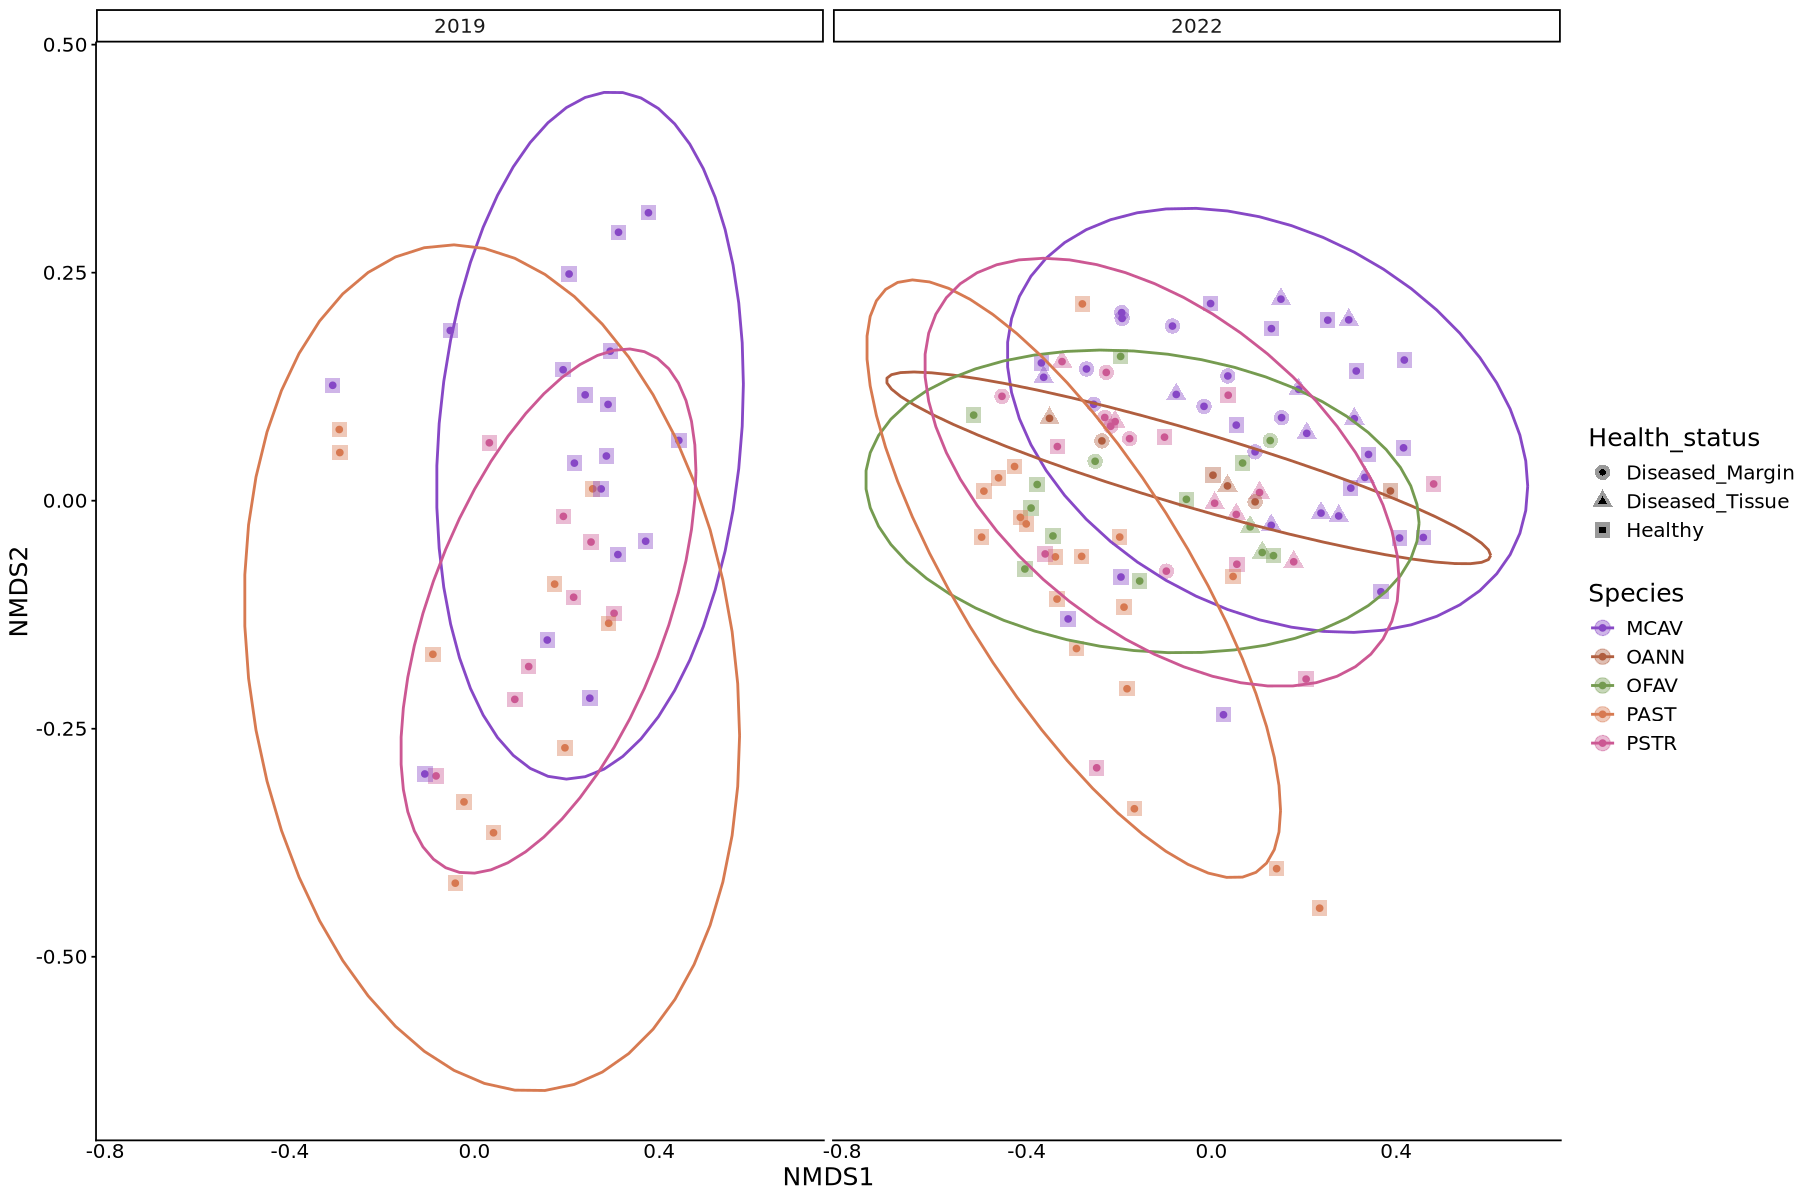

In [81]:
# facet by year
plot_ordination(ps, ps_sctld.ord, type = "samples", color="Species") +
  geom_point(aes(color = Species, shape = Health_status), size = 4, alpha = 0.4) + 
  stat_ellipse(aes(color = Species, group = Species), level = 0.95, size = 0.8) +
  scale_color_manual(values = custom_list) +
  facet_wrap(~year)+
  theme_classic()+
  theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))
# all samples - separated by 2019 and 2022

In [37]:
ps_sctld.ord
# stress 0.203 
# stress = 0.2 is not great..

# species clustering is not very clear. 


Call:
metaMDS(comm = veganifyOTU(physeq), distance = distance, trymax = 1000) 

global Multidimensional Scaling using monoMDS

Data:     wisconsin(sqrt(veganifyOTU(physeq))) 
Distance: bray 

Dimensions: 2 
Stress:     0.2043791 
Stress type 1, weak ties
Best solution was not repeated after 1000 tries
The best solution was from try 361 (random start)
Scaling: centring, PC rotation 
Species: expanded scores based on ‘wisconsin(sqrt(veganifyOTU(physeq)))’ 


In [62]:
# Calculate the Bray-Curtis distance matrix
bray_dist <- phyloseq::distance(ps, method = "bray")
metadata2 <- as(phyloseq::sample_data(ps), "data.frame")

In [63]:
permanova <- vegan::adonis2(bray_dist ~ RS * Species * year, data = metadata2, permutations = 999)
print(permanova)
# all samples

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ RS * Species * year, data = metadata2, permutations = 999)
                 Df SumOfSqs      R2      F Pr(>F)    
RS                1    1.882 0.03325 4.9843  0.001 ***
Species           4    6.436 0.11373 4.2619  0.001 ***
year              1    0.950 0.01678 2.5159  0.001 ***
RS:Species        3    1.296 0.02291 1.1445  0.092 .  
RS:year           1    0.697 0.01232 1.8472  0.004 ** 
Species:year      2    1.131 0.01998 1.4977  0.006 ** 
RS:Species:year   1    0.406 0.00718 1.0756  0.315    
Residual        116   43.792 0.77385                  
Total           129   56.590 1.00000                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [64]:
permanova2 <- vegan::adonis2(bray_dist ~ Health_status * RS * Species * year, data = metadata2, permutations = 999)
print(permanova2)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Species * year, data = metadata2, permutations = 999)
                       Df SumOfSqs      R2      F Pr(>F)    
Health_status           2    2.389 0.04221 3.2301  0.001 ***
RS                      1    1.676 0.02961 4.5316  0.001 ***
Species                 4    6.371 0.11258 4.3073  0.001 ***
year                    1    0.610 0.01079 1.6508  0.010 ** 
Health_status:Species   6    2.635 0.04656 1.1875  0.021 *  
RS:Species              3    1.195 0.02112 1.0775  0.200    
RS:year                 1    0.373 0.00660 1.0095  0.415    
Species:year            2    1.050 0.01856 1.4201  0.013 *  
RS:Species:year         1    0.357 0.00630 0.9645  0.589    
Residual              108   39.934 0.70568                  
Total                 129   56.590 1.00000                  
---
Signif. codes:  

In [65]:
permanova3 <- vegan::adonis2(bray_dist ~ Health_status * RS * Species * year * Transect, data = metadata2, permutations = 999)
print(permanova3)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Species * year * Transect, data = metadata2, permutations = 999)
                                Df SumOfSqs      R2      F Pr(>F)    
Health_status                    2    2.389 0.04221 3.2953  0.001 ***
RS                               1    1.676 0.02961 4.6230  0.001 ***
Species                          4    6.371 0.11258 4.3942  0.001 ***
year                             1    0.610 0.01079 1.6840  0.009 ** 
Transect                         3    1.555 0.02748 1.4302  0.004 ** 
Health_status:Species            6    2.575 0.04550 1.1840  0.017 *  
RS:Species                       3    1.168 0.02064 1.0742  0.205    
RS:year                          1    0.378 0.00668 1.0431  0.324    
Species:year                     2    1.017 0.01798 1.4035  0.006 ** 
Health_status:Transect           6    2.4

In [66]:
# location is more important than health status?

In [67]:
# look at 2022 subset - how much does health status vary
dis_ps<- subset_samples(ps, year == '2022')
bray_dist <- phyloseq::distance(dis_ps, method = "bray")
dis_meta <- as(phyloseq::sample_data(dis_ps), "data.frame")
dis_perma <- vegan::adonis2(bray_dist ~ Health_status * Species * Transect, data = dis_meta, permutations = 999)
print(dis_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * Species * Transect, data = dis_meta, permutations = 999)
                               Df SumOfSqs      R2      F Pr(>F)    
Health_status                   2    2.349 0.05708 3.0679  0.001 ***
Species                         4    4.470 0.10863 2.9191  0.001 ***
Transect                        3    1.562 0.03796 1.3601  0.001 ***
Health_status:Species           6    2.524 0.06134 1.0988  0.089 .  
Health_status:Transect          6    2.473 0.06011 1.0768  0.150    
Species:Transect                8    3.509 0.08527 1.1456  0.015 *  
Health_status:Species:Transect  4    1.292 0.03139 0.8436  0.984    
Residual                       60   22.969 0.55821                  
Total                          93   41.148 1.00000                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’

In [68]:
# species is more important than health status - same as from prelim results

In [69]:
#mcav only
# look at 2022 subset - how much does health status vary
mcav_ps<- subset_samples(ps_sctld, Species == "MCAV" & year == '2022')
bray_dist <- phyloseq::distance(mcav_ps, method = "bray")
mcav_meta <- as(phyloseq::sample_data(mcav_ps), "data.frame")
mcav_perma <- vegan::adonis2(bray_dist ~ Health_status * RS * Transect, data = mcav_meta, permutations = 999)
print(mcav_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Transect, data = mcav_meta, permutations = 999)
                       Df SumOfSqs      R2      F Pr(>F)    
Health_status           2   1.6775 0.11510 2.1970  0.001 ***
RS                      1   0.4003 0.02746 1.0485  0.409    
Transect                3   1.4221 0.09758 1.2416  0.022 *  
Health_status:Transect  4   1.5299 0.10498 1.0019  0.455    
Residual               25   9.5444 0.65488                  
Total                  35  14.5743 1.00000                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [70]:
# orbi_ps<- subset_samples(ps_sctld, Species == "ORBI")
# bray_dist <- phyloseq::distance(orbi_ps, method = "bray")
# orbi_meta <- as(phyloseq::sample_data(orbi_ps), "data.frame")
# orbi_perma <- vegan::adonis2(bray_dist ~ Health_status * RS * Transect, data = orbi_meta, permutations = 999)
# print(orbi_perma)

In [71]:
# maybe we do need to separate out orbi species...

In [72]:
#### 2019 

In [40]:
# 2019 only - RS
RS_ps <- subset_samples(ps, year == "2019")
RS.ord <- ordinate(RS_ps, "NMDS", "bray", trymax=1000)

Square root transformation
Wisconsin double standardization
Run 0 stress 0.2437093 
Run 1 stress 0.2384673 
... New best solution
... Procrustes: rmse 0.06768366  max resid 0.1992573 
Run 2 stress 0.2587234 
Run 3 stress 0.2373138 
... New best solution
... Procrustes: rmse 0.03345863  max resid 0.1174391 
Run 4 stress 0.24072 
Run 5 stress 0.2636857 
Run 6 stress 0.2392088 
Run 7 stress 0.2548547 
Run 8 stress 0.2394256 
Run 9 stress 0.2578059 
Run 10 stress 0.2380862 
Run 11 stress 0.259997 
Run 12 stress 0.2373788 
... Procrustes: rmse 0.02256541  max resid 0.1098439 
Run 13 stress 0.2379176 
Run 14 stress 0.2565317 
Run 15 stress 0.2574039 
Run 16 stress 0.235247 
... New best solution
... Procrustes: rmse 0.04753852  max resid 0.2426015 
Run 17 stress 0.2379707 
Run 18 stress 0.2654619 
Run 19 stress 0.2376994 
Run 20 stress 0.266321 
Run 21 stress 0.2398937 
Run 22 stress 0.2352469 
... New best solution
... Procrustes: rmse 6.106797e-05  max resid 0.0002184397 
... Similar to pr

Warning message in postMDS(out$points, dis, plot = max(0, plot - 1), ...):
“skipping half-change scaling: too few points below threshold”


Warning message:
“The following aesthetics were dropped during statistical transformation: shape.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?”


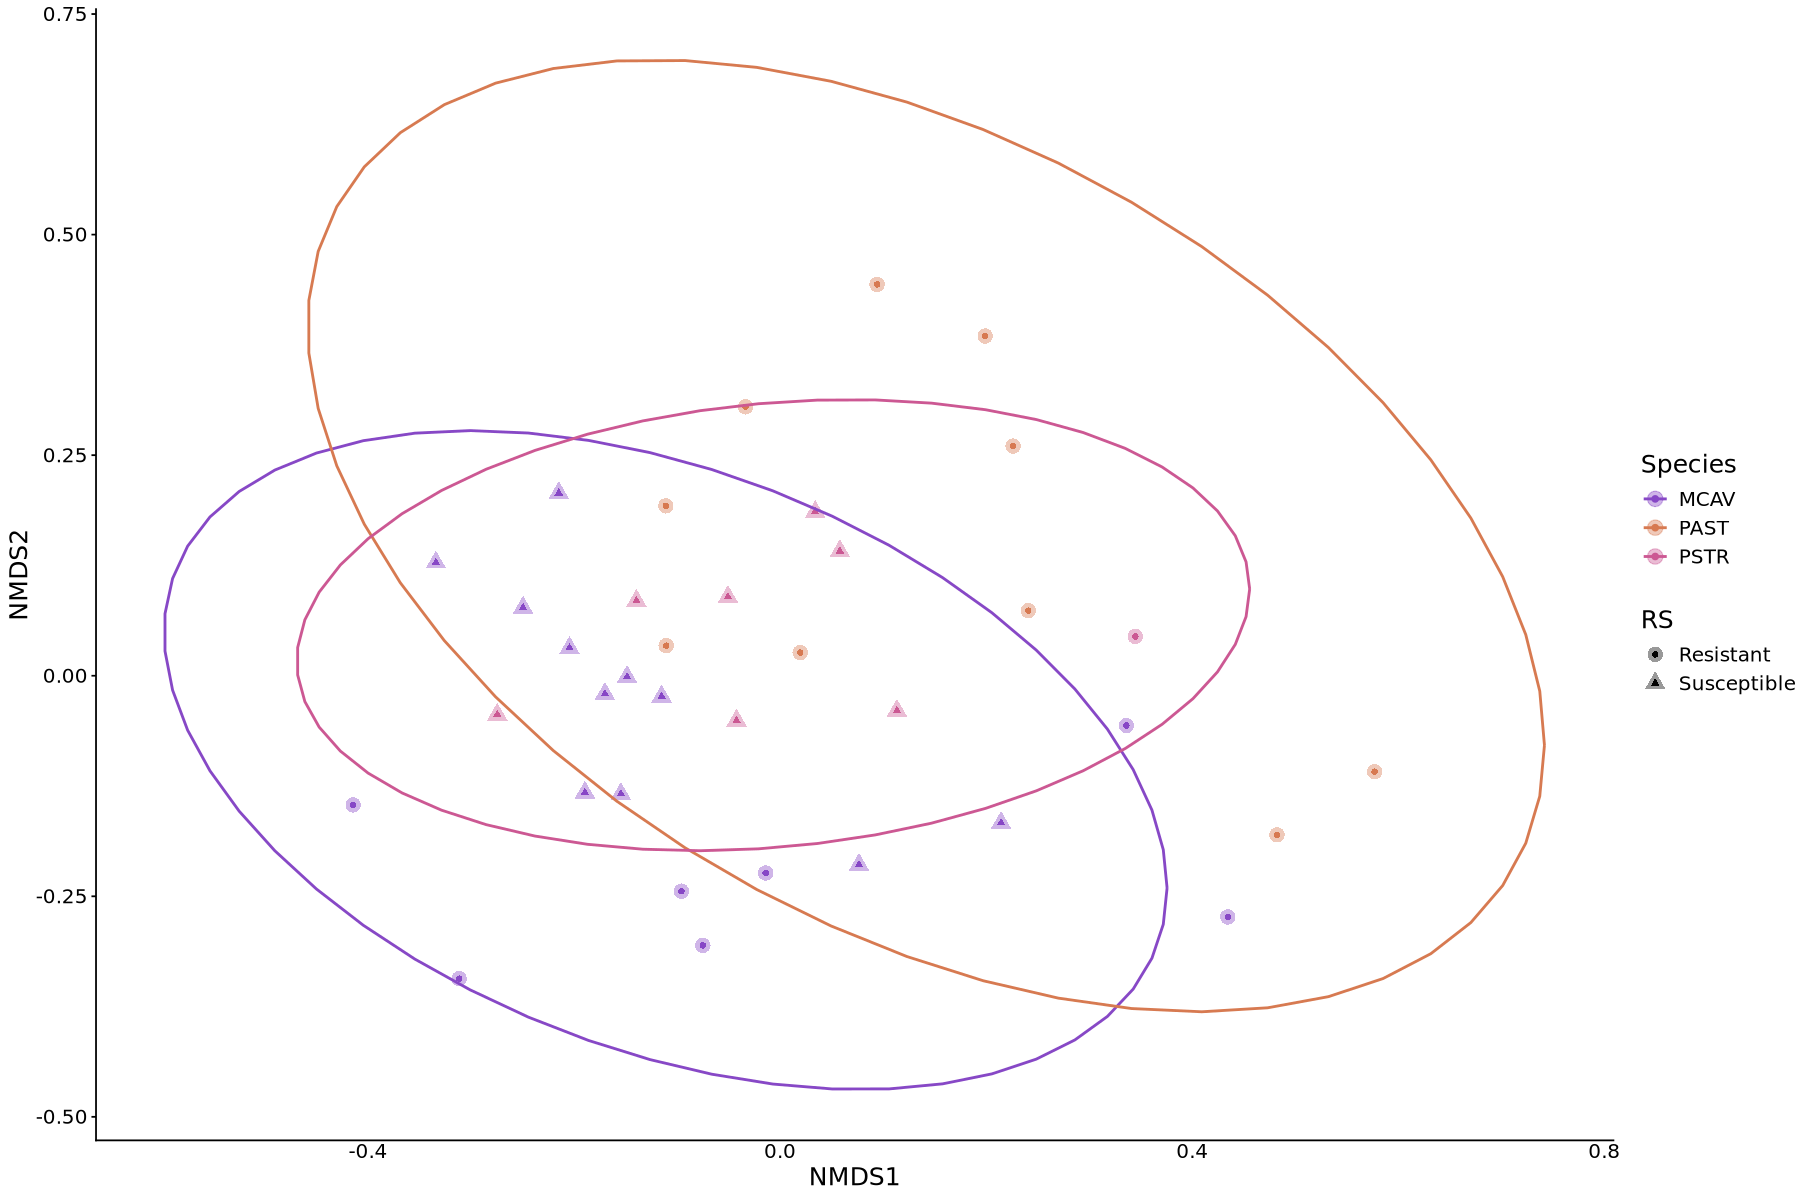

In [84]:
nmds_2019<-plot_ordination(RS_ps, RS.ord, type="samples", color="Species", shape="RS")+
geom_point(size=4, alpha = 0.4) + 
# scale_color_brewer(palette = "Dark2")+
scale_color_manual(values = custom_list)+
stat_ellipse(aes(group = Species), level = 0.95, size = 0.8) +
# facet_wrap(~year)+
# geom_label(aes(label = sample_data(ps2)$sampleid), vjust = -1, color = "black") +
theme_classic()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))
nmds_2019


# 2019 only 

In [75]:
RS.ord
# Stress: 0.2278
# > 0.2 is not good...


Call:
metaMDS(comm = veganifyOTU(physeq), distance = distance, trymax = 1000) 

global Multidimensional Scaling using monoMDS

Data:     wisconsin(sqrt(veganifyOTU(physeq))) 
Distance: bray 

Dimensions: 2 
Stress:     0.2278231 
Stress type 1, weak ties
Best solution was repeated 1 time in 20 tries
The best solution was from try 7 (random start)
Scaling: centring, PC rotation 
Species: expanded scores based on ‘wisconsin(sqrt(veganifyOTU(physeq)))’ 


In [76]:
# 2019 only 

In [77]:
bray_dist <- phyloseq::distance(RS_ps, method = "bray")
dis_meta <- as(phyloseq::sample_data(RS_ps), "data.frame")
dis_perma <- vegan::adonis2(bray_dist ~ RS * Species * Transect, data = dis_meta, permutations = 999)
print(dis_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ RS * Species * Transect, data = dis_meta, permutations = 999)
                 Df SumOfSqs      R2      F Pr(>F)    
RS                1   1.3900 0.09765 4.4914  0.001 ***
Species           2   2.6848 0.18862 4.3377  0.001 ***
Transect          2   0.6789 0.04770 1.0969  0.288    
RS:Species        1   0.3925 0.02757 1.2683  0.127    
RS:Transect       2   0.5029 0.03533 0.8125  0.823    
Species:Transect  4   1.4671 0.10307 1.1852  0.104    
Residual         23   7.1178 0.50006                  
Total            35  14.2340 1.00000                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [78]:
#### stress is low in ordination, but species is significant in microbiome composition (19% of variation) 
                                    # and RS is significant in microbiome composition (10% of variation) 

In [79]:
dis_perma <- vegan::adonis2(bray_dist ~ RS + Species + Transect, data = dis_meta, permutations = 999, by = "margin")
print(dis_perma)

Permutation test for adonis under reduced model
Marginal effects of terms
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ RS + Species + Transect, data = dis_meta, permutations = 999, by = "margin")
         Df SumOfSqs      R2      F Pr(>F)    
RS        1   0.4823 0.03388 1.5261  0.066 .  
Species   2   2.6475 0.18600 4.1889  0.001 ***
Transect  2   0.6789 0.04770 1.0742  0.327    
Residual 30   9.4803 0.66603                  
Total    35  14.2340 1.00000                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [80]:
disp_species <- vegan::betadisper(bray_dist, dis_meta$Species)
anova(disp_species)

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Groups,2,0.07271402,0.03635701,1.617377,0.2137531
Residuals,33,0.74180702,0.02247900,NA,NA


In [81]:
# within species, how much does RS explain difference

In [82]:
mcav_ps<- subset_samples(RS_ps, Species == "MCAV")
bray_dist <- phyloseq::distance(mcav_ps, method = "bray")
mcav_meta <- as(phyloseq::sample_data(mcav_ps), "data.frame")
mcav_perma <- vegan::adonis2(bray_dist ~  RS * Transect, data = mcav_meta, permutations = 999)
print(mcav_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ RS * Transect, data = mcav_meta, permutations = 999)
            Df SumOfSqs      R2      F Pr(>F)  
RS           1   0.4386 0.07457 1.3833  0.118  
Transect     2   1.0100 0.17170 1.5927  0.012 *
RS:Transect  2   0.6289 0.10690 0.9916  0.494  
Residual    12   3.8051 0.64683                
Total       17   5.8826 1.00000                
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [83]:
# ggsave(filename = "/project/pi_sarah_gignouxwolfsohn_uml_edu/brooke/CBC_metagenomics/all_sctld/plots/RS_2019_nmds.png", plot = nmds_2019, 
#       width = 10,
#       height = 10,
#       units = "in",
#       dpi = 300)

In [84]:
#### alpha diversity ####

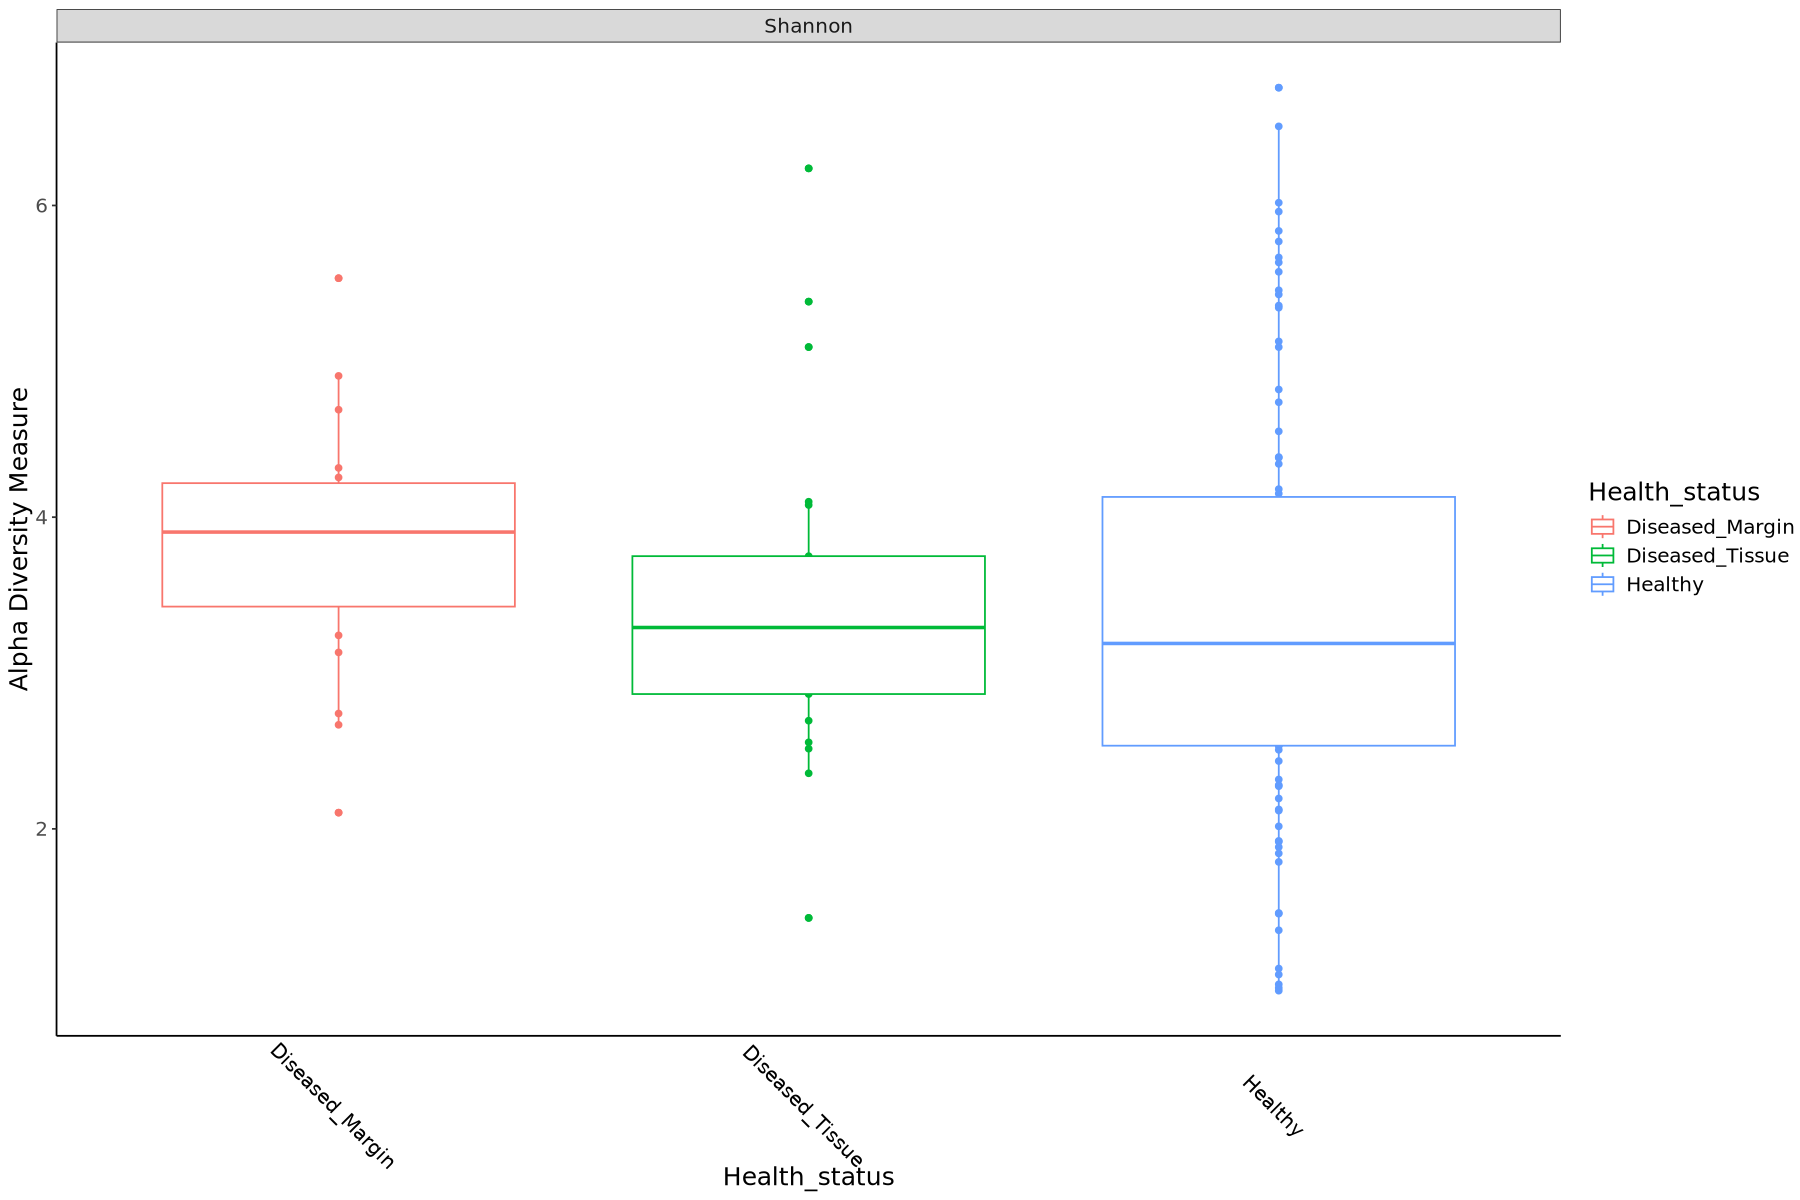

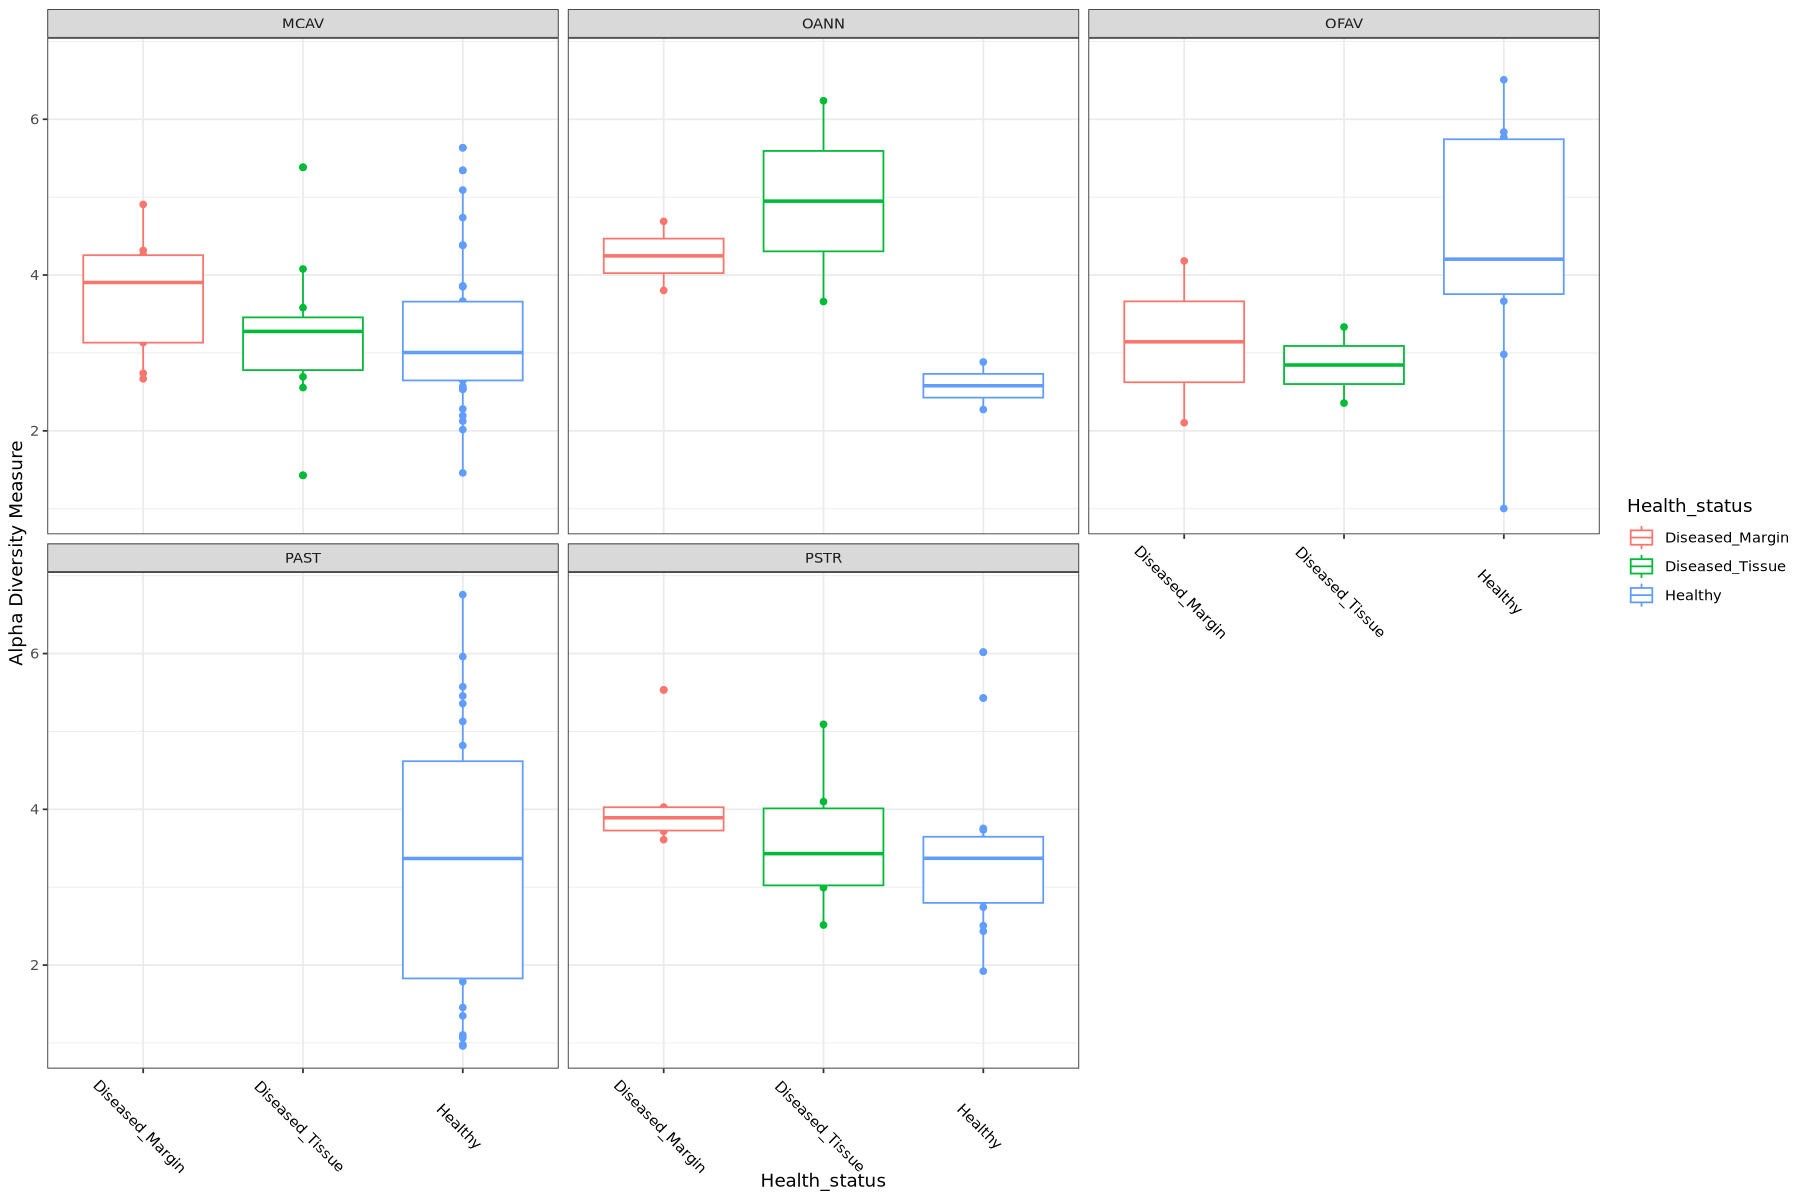

In [85]:
rich_status <- plot_richness(ps_sctld, x="Health_status", color="Health_status", measures=c("Shannon")) + 
    geom_boxplot() +
    # facet_wrap(~Species)+
    theme_bw()+
     theme(legend.position = "right",
        panel.border = element_blank(),
        panel.grid.major.x = element_blank(),
        panel.grid.minor.x = element_blank(),
        panel.grid.major.y = element_blank(),
        panel.grid.minor.y = element_blank(),
        axis.ticks.x = element_blank(),
        axis.line = element_line(color = "black"),
        axis.text.x = element_text(color = "black", angle = -45, hjust = 0.5),
        text = element_text(size = 15))
rich_status

plot_richness(ps_sctld, x="Health_status", color="Health_status", measures=c("Shannon")) + 
geom_boxplot() +
facet_wrap(~Species)+
theme_bw()+
theme(axis.text.x = element_text(color = "black", angle = -45, hjust = 0.5))

# all samples - spp x disease status

In [86]:
# except in ofav, with 16S it looks like diseased samples are more diverse (which you couldn't really tell with metagenomics)

In [87]:
# ggsave(filename = "shannon_richness_sample_type.png", plot = rich_status, 
#       width = 10,
#       height = 10,
#       units = "in",
#       dpi = 300)

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”
Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”


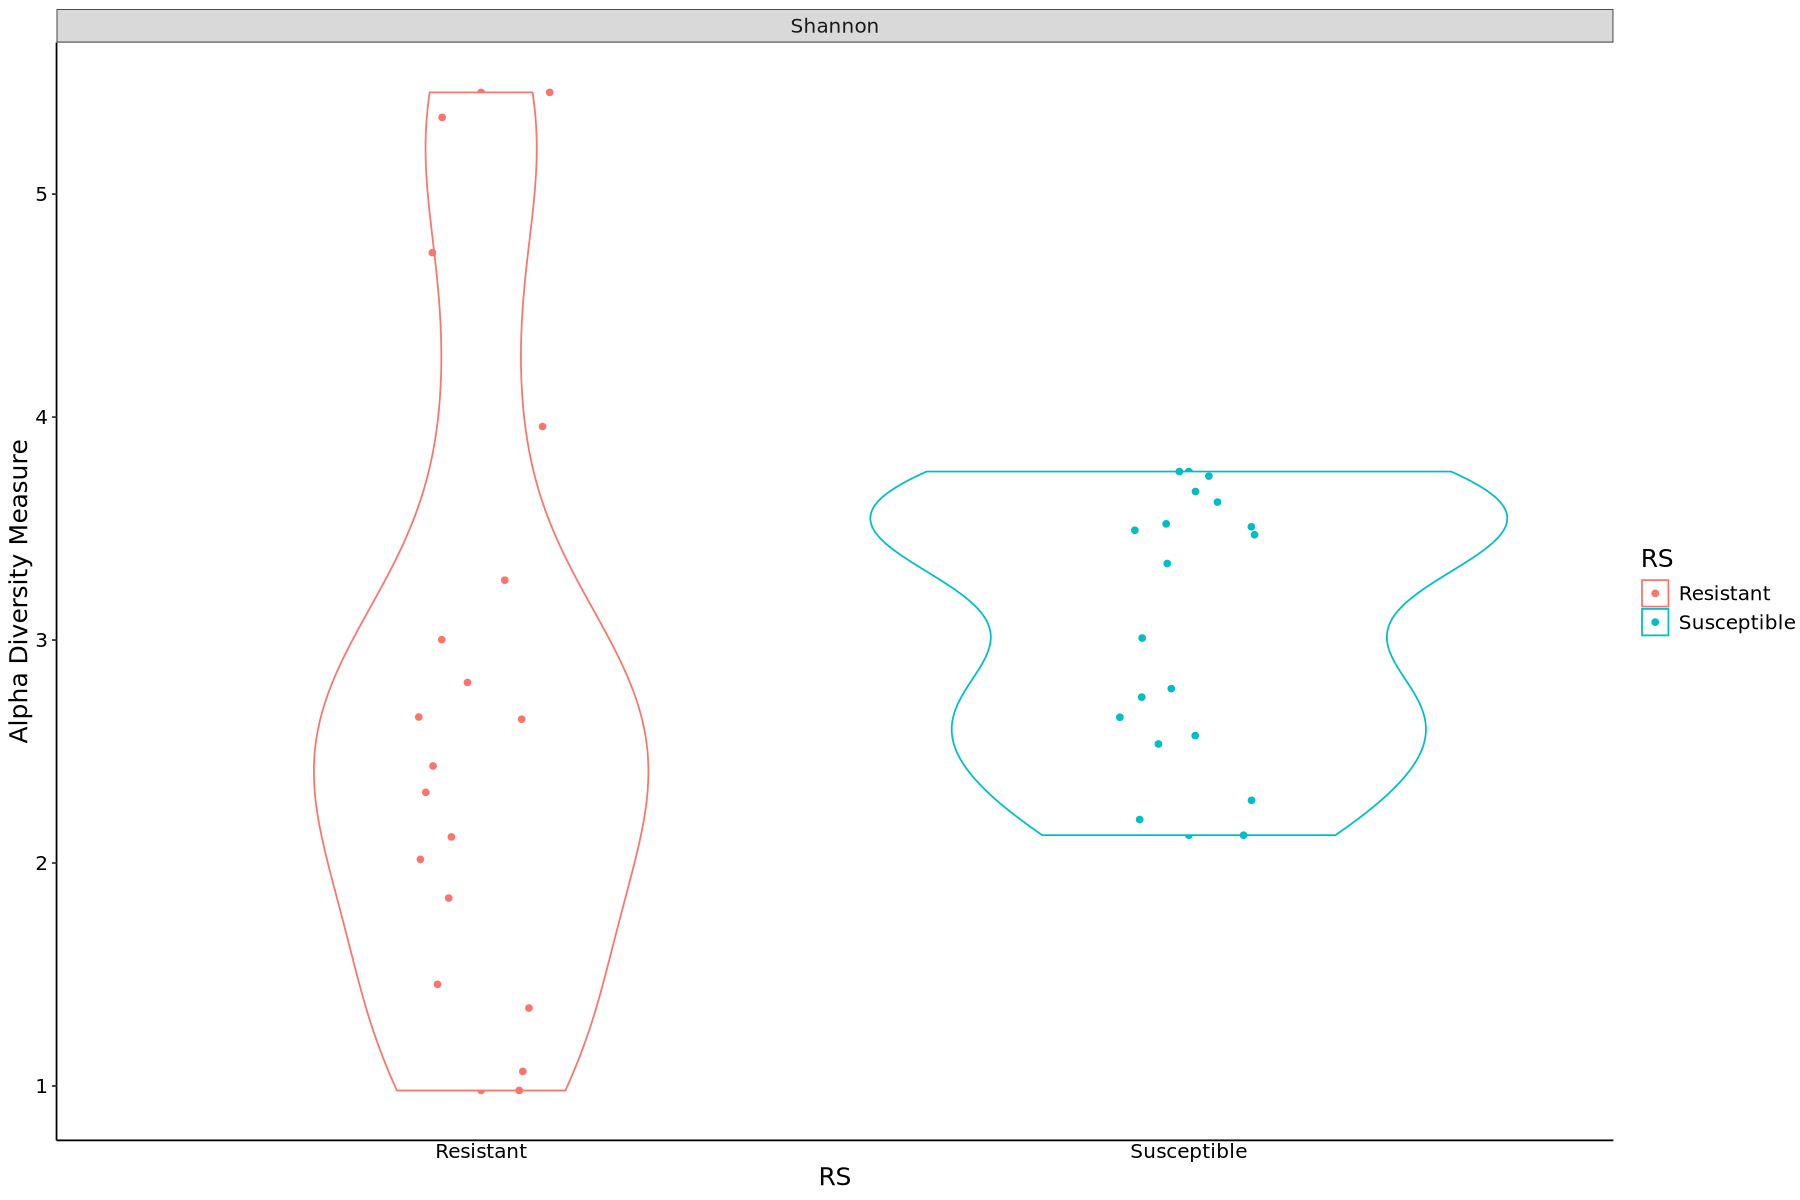

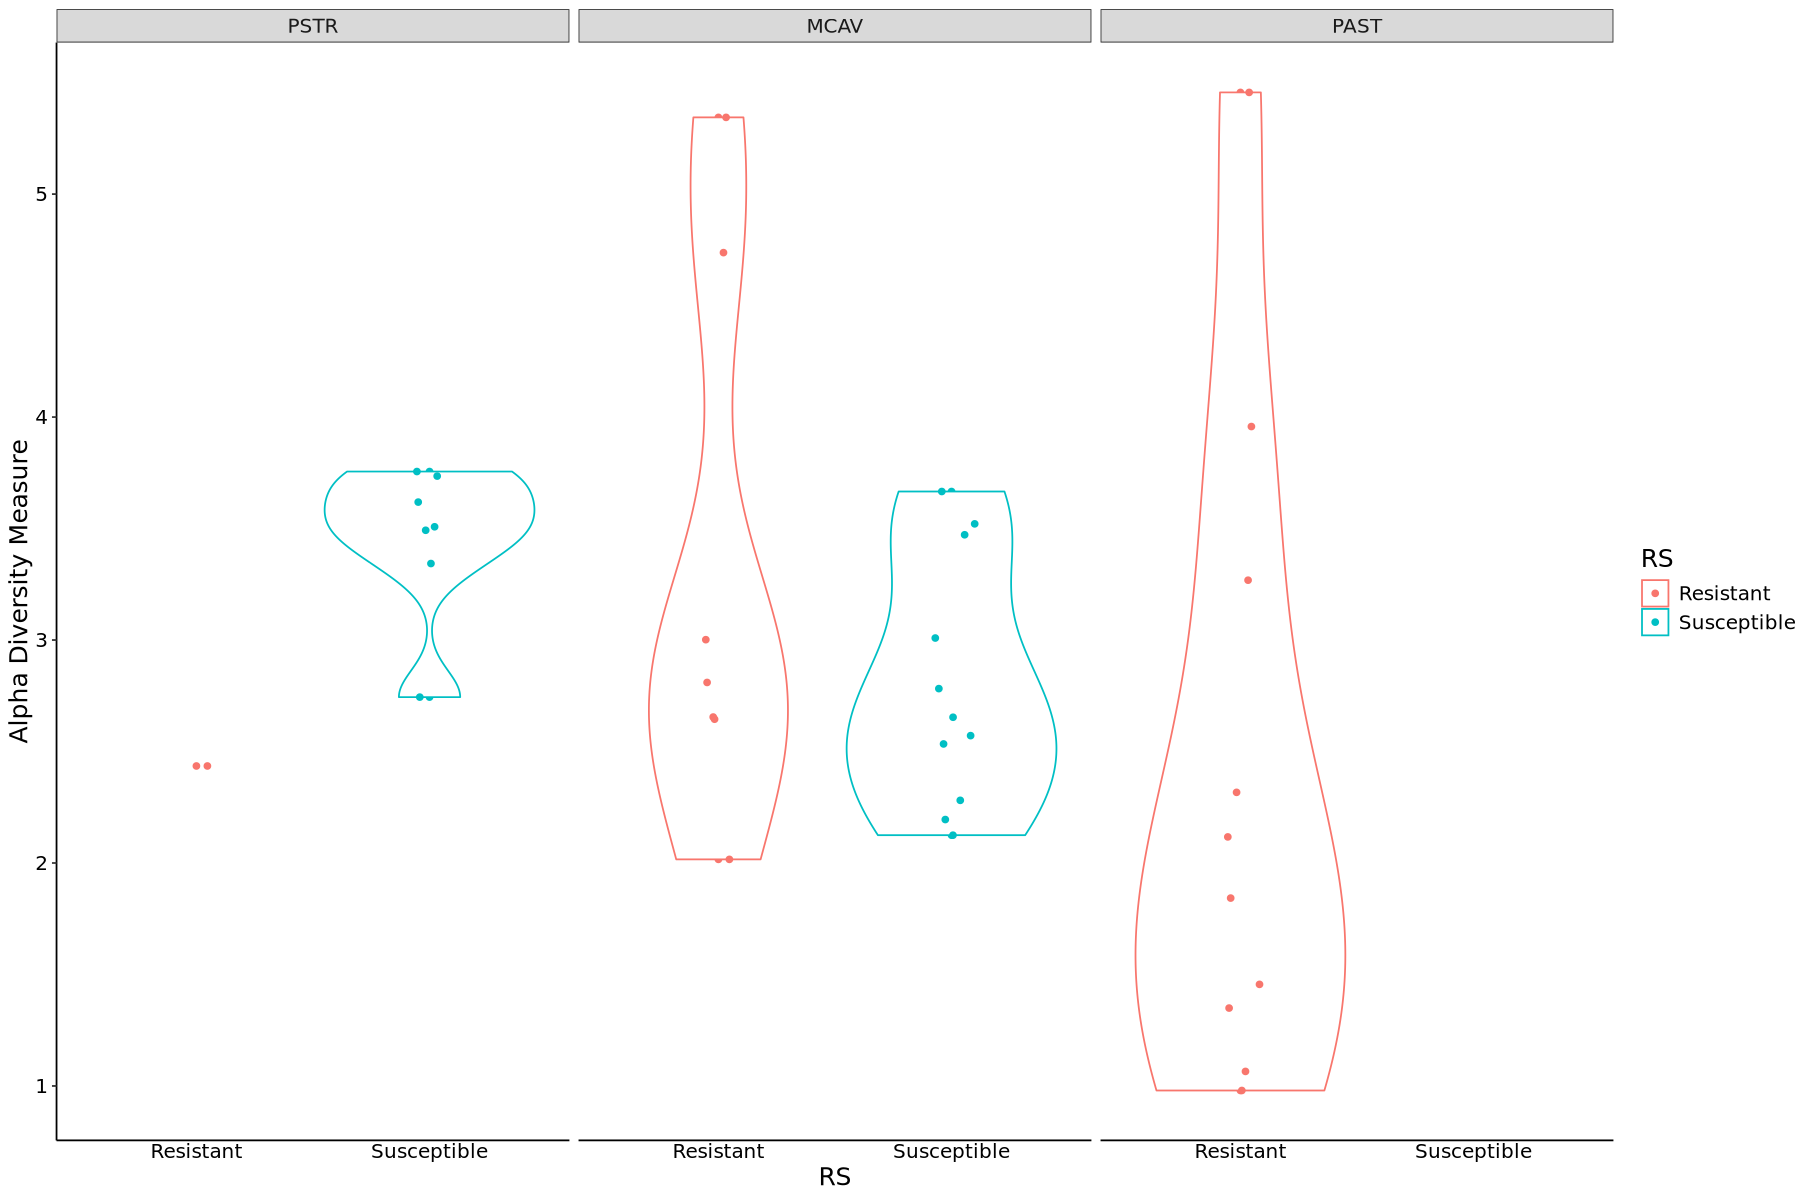

In [88]:
# order of species susceptibility 
# reorder colonies most -> least sus
spp_order<-c("MMEA",'PSTR','MCAV','PAST')
df_meta<-data.frame(sample_data(RS_ps))
sample_data(RS_ps)$Species <-
  factor(sample_data(RS_ps)$Species, levels = spp_order)

rich_status1 <- plot_richness(RS_ps, x="RS", color="RS", measures=c("Shannon")) + geom_violin() +
geom_jitter(height = 0, width = 0.1)+
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))
rich_status1

rich_status1+
    facet_grid(~Species)

# R vs S - 2019 only 

In [89]:
# most susceptible species are still more diverse (same in metagenomics results)

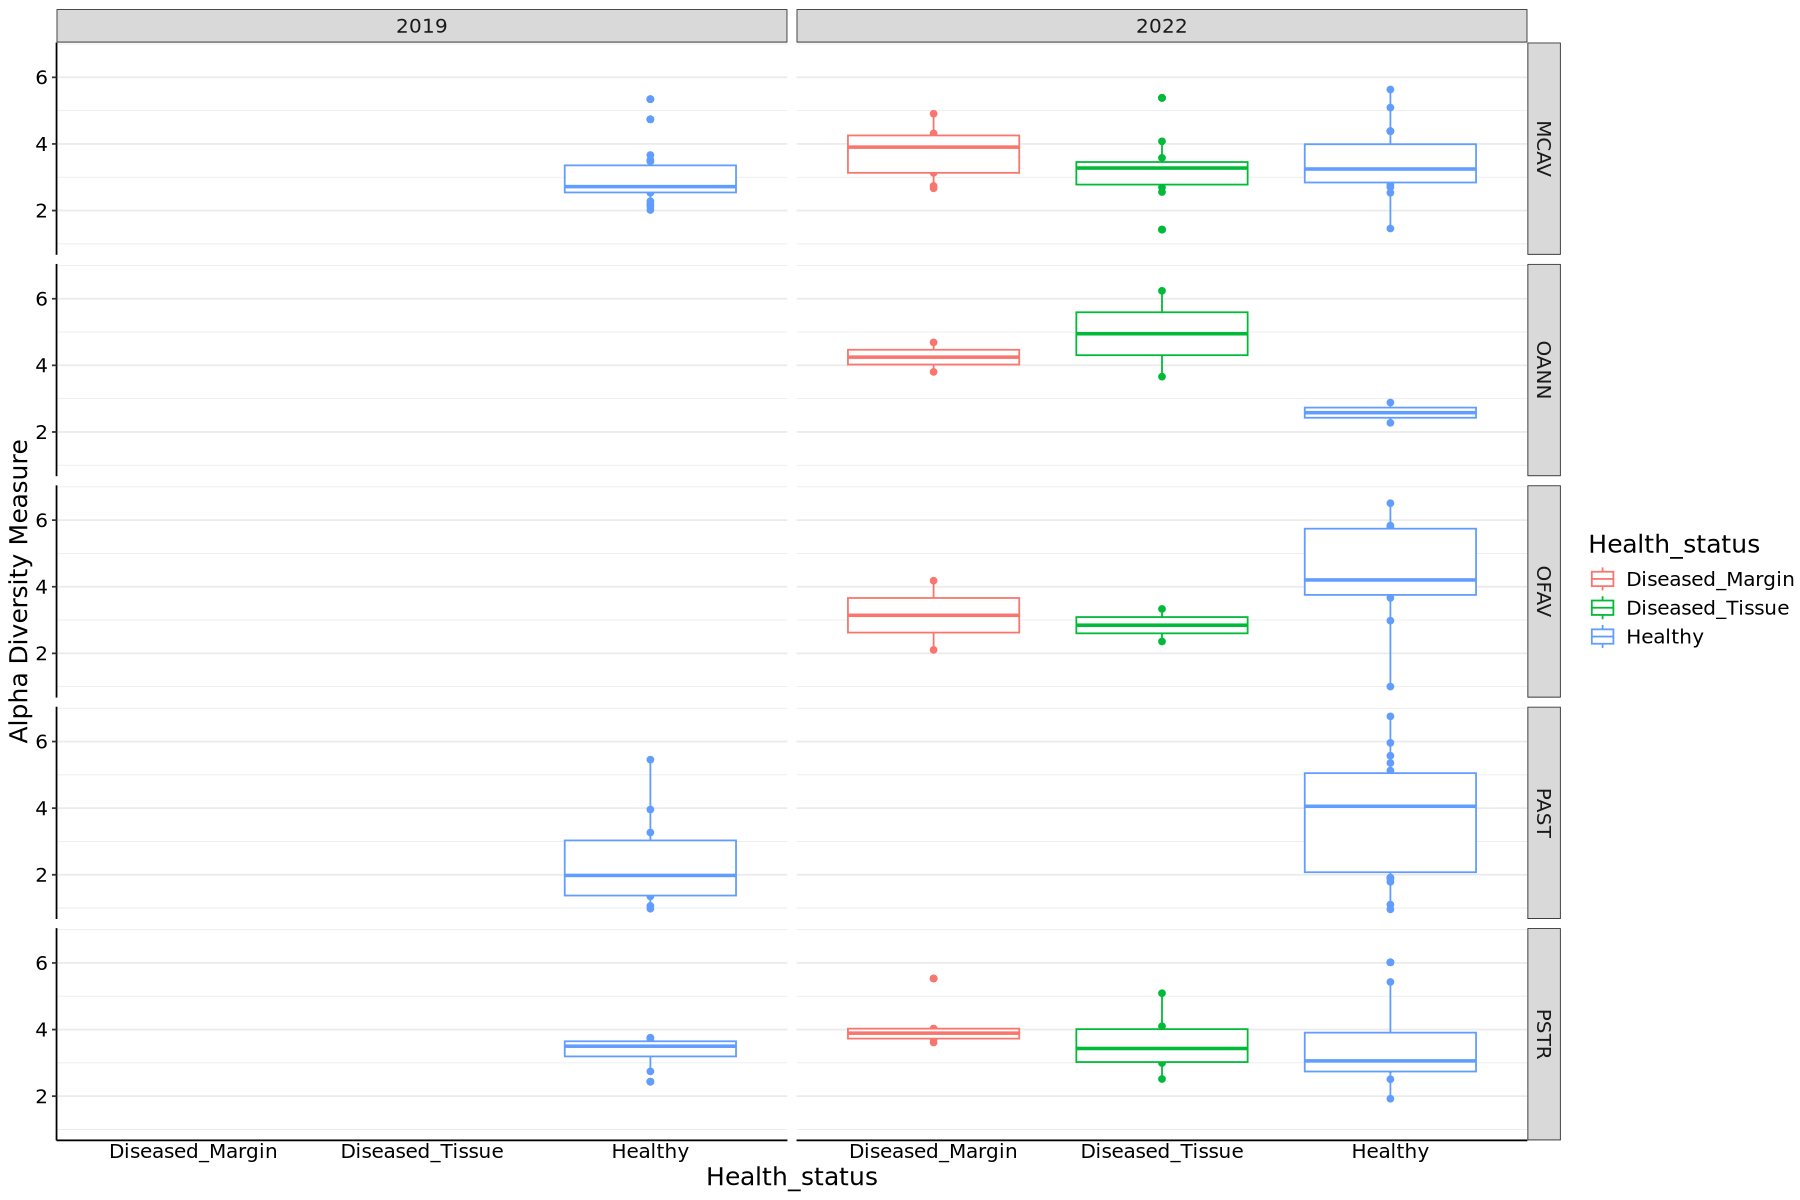

In [90]:
rich_species <- plot_richness(ps_sctld, x="Health_status", color="Health_status", measures=c("Shannon")) + geom_boxplot() +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))

rich_species+
    facet_grid(Species~year)

# all samples - year x spp x health status

### Taxa Bar Plots

In [33]:
# subset taxa and normalzie out of 100 - Family level
ps_sctld_10 = prune_taxa(names(sort(taxa_sums(ps_sctld),TRUE)[1:10]), ps_sctld)
ps_sctld_10_norm <- transform_sample_counts(ps_sctld_10, function(x) x / sum(x))
     
ps_sctld_30 = prune_taxa(names(sort(taxa_sums(ps_sctld),TRUE)[1:30]), ps_sctld)
ps_sctld_30_norm <- transform_sample_counts(ps_sctld_30, function(x) x / sum(x))

ps_sctld_100 = prune_taxa(names(sort(taxa_sums(ps_sctld),TRUE)[1:100]), ps_sctld)
ps_sctld_100_norm <- transform_sample_counts(ps_sctld_100, function(x) x / sum(x))

In [34]:
g_colors <- c( "#b73962", "#e994a6", "#be6b7c", "#944557", "#ea2c68", "#e65e74", "#b33841", "#dd3640", "#dd7267", "#de2b1c", "#a46452", "#c04926", "#9b4426", "#ec5825", "#e6a485", "#c2744d", "#e77d46", "#a3601b", "#845526", "#e28c23", "#d79651", "#a4844d", "#aa8523", "#d2b067", "#d3b135", "#726520", "#81871c", "#b4b75d", "#a5c030", "#829055", "#7a9a3c", "#566935", "#a7bc85", "#4e7023", "#64a422", "#89c45e", "#57ce3c", "#2f7f2d", "#3aa83a", "#5d9b58", "#7ec485", "#47cc7a", "#2c6f47", "#32a064", "#2f8970", "#53ae93", "#3fc9a6", "#64d3c2", "#41bbc8", "#3da5c4", "#4b8ebf", "#72b3e8", "#3270a7", "#2e5b88", "#4795e0", "#5790ed", "#2b6abe", "#2580fe", "#415691", "#6274b2", "#4b80ec", "#95a0e6", "#4362c2", "#7c89e9", "#5166ec", "#3c4dbb", "#5756a0", "#695dbf", "#8476c6", "#675cd3", "#4e45a3", "#4d4adc", "#8f76e8", "#72619d", "#9b87be", "#6b4fa0", "#7048b1", "#7532e8", "#b58aea", "#9655e8", "#cda8e4", "#7c608c", "#8a52ae", "#634872", "#bc6aea", "#b436e6", "#9235b6", "#7e4990", "#b175b9", "#9b43a1", "#dd7adc", "#e635ea", "#d043cc", "#915882", "#d78bbb", "#ba3291", "#ea3db5", "#a24680", "#e670af", "#e3418b" )
colors <- c( "#b73962", "#e994a6", "#be6b7c", "#944557", "#ea2c68", "#e65e74", "#b33841", "#dd3640", "#dd7267", "#de2b1c", "#a46452", "#c04926", "#9b4426", "#ec5825", "#e6a485", "#c2744d", "#e77d46", "#a3601b", "#845526", "#e28c23", "#d79651", "#a4844d", "#aa8523", "#d2b067", "#d3b135", "#726520", "#81871c", "#b4b75d", "#a5c030", "#829055", "#7a9a3c", "#566935", "#a7bc85", "#4e7023", "#64a422", "#89c45e", "#57ce3c", "#2f7f2d", "#3aa83a", "#5d9b58", "#7ec485", "#47cc7a", "#2c6f47", "#32a064", "#2f8970", "#53ae93", "#3fc9a6", "#64d3c2", "#41bbc8", "#3da5c4", "#4b8ebf", "#72b3e8", "#3270a7", "#2e5b88", "#4795e0", "#5790ed", "#2b6abe", "#2580fe", "#415691", "#6274b2", "#4b80ec", "#95a0e6", "#4362c2", "#7c89e9", "#5166ec", "#3c4dbb", "#5756a0", "#695dbf", "#8476c6", "#675cd3", "#4e45a3", "#4d4adc", "#8f76e8", "#72619d", "#9b87be", "#6b4fa0", "#7048b1", "#7532e8", "#b58aea", "#9655e8", "#cda8e4", "#7c608c", "#8a52ae", "#634872", "#bc6aea", "#b436e6", "#9235b6", "#7e4990", "#b175b9", "#9b43a1", "#dd7adc", "#e635ea", "#d043cc", "#915882", "#d78bbb", "#ba3291", "#ea3db5", "#a24680", "#e670af", "#e3418b" )
colors_30 <- c( "#e28d99", "#ee7473", "#f2703f", "#dc966f", "#de9435", "#d6b36e", "#dbbf37", "#abb160", "#bdd630", "#bade6b", "#7ead3b", "#bcdc9c", "#66d34d", "#65d77c", "#66af7a", "#5ae5ac", "#77e3c6", "#47b1a5", "#5ae4e5", "#41aec3", "#5eceed", "#3ba1d2", "#78b0e7", "#7796ed", "#b5a5dd", "#aa7df5", "#c891e3", "#e66dd5", "#de95c9", "#f2699f" )

In [35]:
# map list of 100 fam to same color
names(colors) <- unique(tax_table(ps_sctld_100)[, "Family"])
head(colors)
names(g_colors) <- unique(tax_table(ps_sctld_100)[, "Genus"])
head(g_colors)

Vibrionaceae Endozoicomonadaceae    Terasakiellaceae    Methylophagaceae 
          "#b73962"           "#e994a6"           "#be6b7c"           "#944557" 
  Blastocatellaceae     Amoebophilaceae 
          "#ea2c68"           "#e65e74"

Vibrio             Parendozoicomonas 
                    "#b73962"                     "#e994a6" 
                   Marivibrio Marine Methylotrophic Group 3 
                    "#be6b7c"                     "#944557" 
                         <NA>       Candidatus Amoebophilus 
                    "#ea2c68"                     "#e65e74"

In [36]:
options(repr.plot.height = 15, repr.plot.width = 30)

In [37]:
# how many unique family taxa are there total?
length(unique(tax_table(ps)[, "Phylum"]))
length(unique(tax_table(ps)[, "Order"]))
length(unique(tax_table(ps)[, "Family"]))
length(unique(tax_table(ps)[, "Genus"]))

[1] 46

[1] 210

[1] 469

[1] 1289

#### All Spp 2019 only

In [38]:
# view each spp R vs S in 2019

In [41]:
# aggregate to family before filtering for top 100 OTUs (to make it comparable to shotgun seq analysis)
# then normalize
sctld_fam <- tax_glom(RS_ps, taxrank = "Family", NArm = FALSE)
sctld_fam_norm <- transform_sample_counts(sctld_fam, function(x) x / sum(x))
                                          
# filter for top families and normalize within each subsetted PS object
top100_names <- names(sort(taxa_sums(sctld_fam), decreasing = TRUE)[1:100])
sctld_100_2019 <- prune_taxa(top100_names, sctld_fam)
sctld_100_2019_norm <- transform_sample_counts(sctld_100_2019, function(x) x / sum(x))
                                          
top50_names <- names(sort(taxa_sums(sctld_fam), decreasing = TRUE)[1:50])
sctld_50_2019 <- prune_taxa(top50_names, sctld_fam)
sctld_50_2019_norm <- transform_sample_counts(sctld_50_2019, function(x) x / sum(x))

top30_names <- names(sort(taxa_sums(sctld_fam), decreasing = TRUE)[1:30])
sctld_30_2019 <- prune_taxa(top30_names, sctld_fam)
sctld_30_2019_norm <-  transform_sample_counts(sctld_30_2019, function(x) x / sum(x))

top10_names <- names(sort(taxa_sums(sctld_fam), decreasing = TRUE)[1:10])
sctld_10_2019 <- prune_taxa(top10_names, sctld_fam)
sctld_10_2019_norm <- transform_sample_counts(sctld_10_2019, function(x) x / sum(x))

In [42]:
## just look at family level bc i think there's a lot of unidentified genera??
    # see previous commit history 

In [43]:
top100family_16S<-as.character(unique(tax_table(sctld_100_2019)[, "Family"]))

In [44]:
# map list of 100 fam to same color
names(colors) <- unique(tax_table(sctld_100_2019)[, "Family"])
head(colors)
# names(g_colors) <- unique(tax_table(sctld_100_2019)[, "Genus"])
# head(g_colors)

Endozoicomonadaceae        Vibrionaceae   Alcanivoracaceae1   Blastocatellaceae 
          "#b73962"           "#e994a6"           "#be6b7c"           "#944557" 
    Amoebophilaceae     Spirochaetaceae 
          "#ea2c68"           "#e65e74"

In [45]:
options(repr.plot.height = 15, repr.plot.width = 18)

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the phyloseq package.
  Please report the issue at <https://github.com/joey711/phyloseq/issues>.”


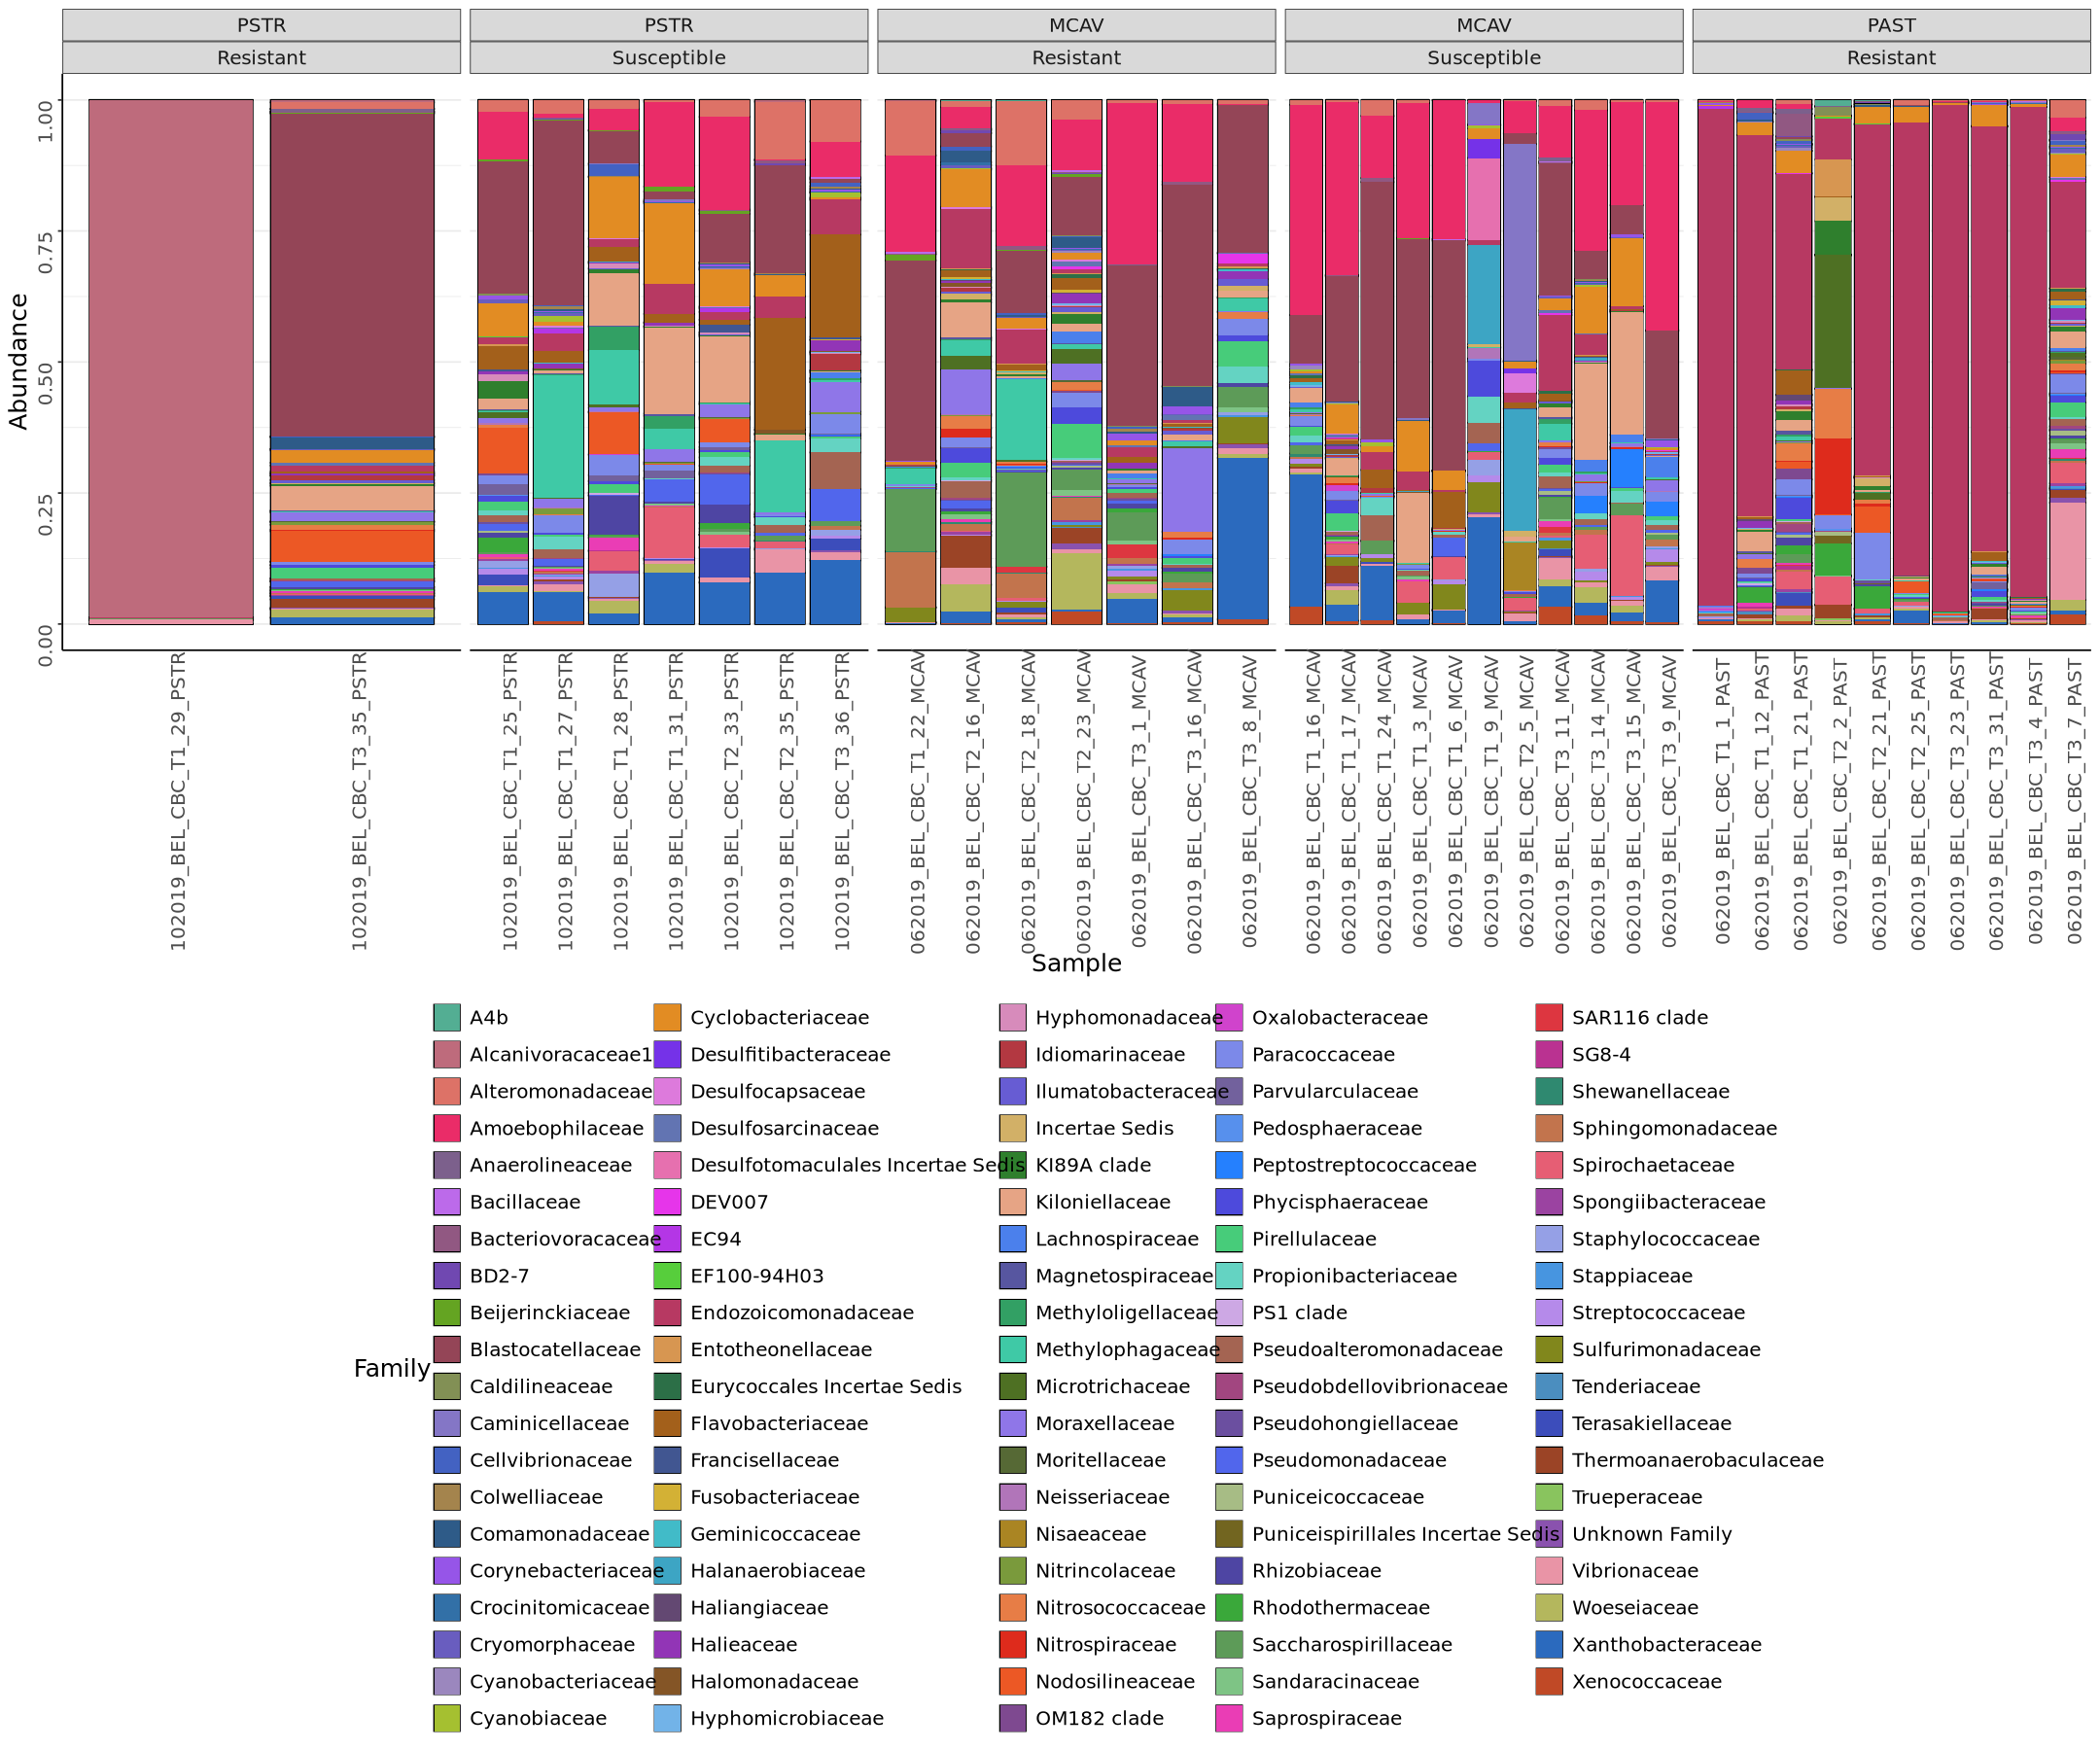

In [46]:
plot_bar(sctld_100_2019_norm,x = "Sample",fill='Family')+
    facet_grid(~ Species + RS, scales = "free_x") +
    geom_bar(aes(fill=Family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# 2019: Top 100 OTUs (Family)

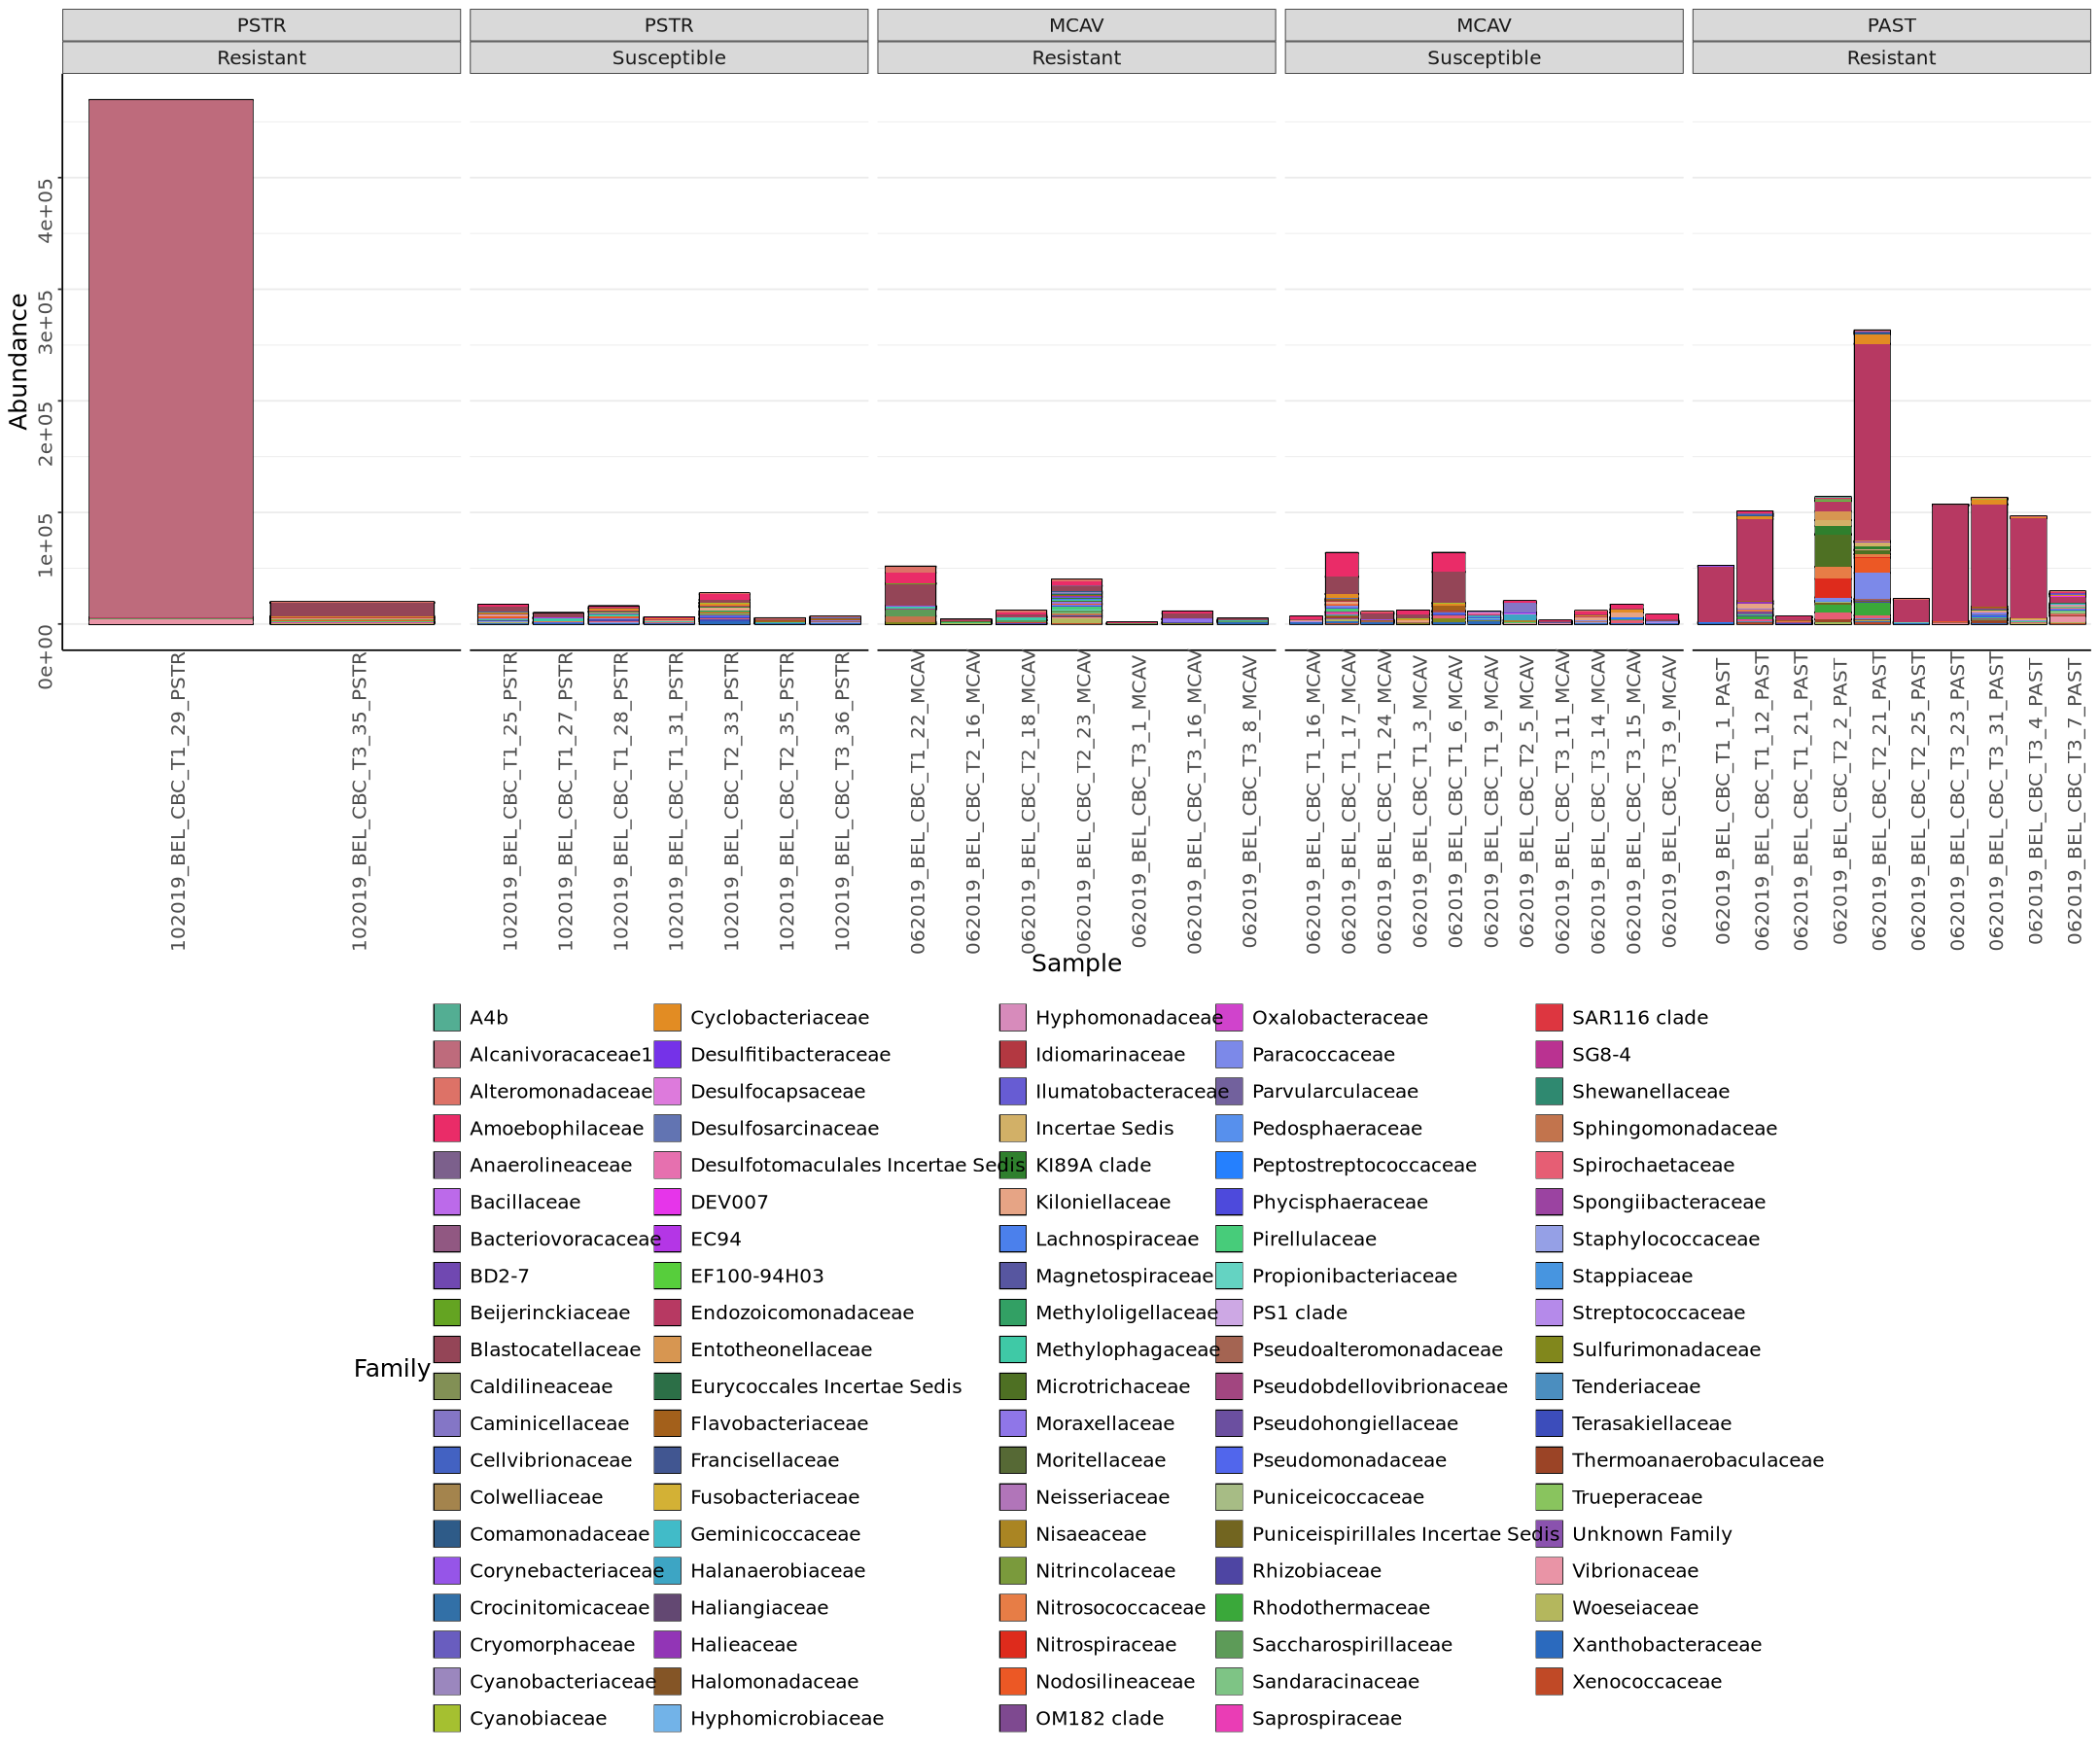

In [47]:
plot_bar(sctld_100_2019,x = "Sample",fill='Family')+
    facet_grid(~ Species + RS, scales = "free_x") +
    geom_bar(aes(fill=Family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# 2019: Top 100 OTUs (Family) rel abun

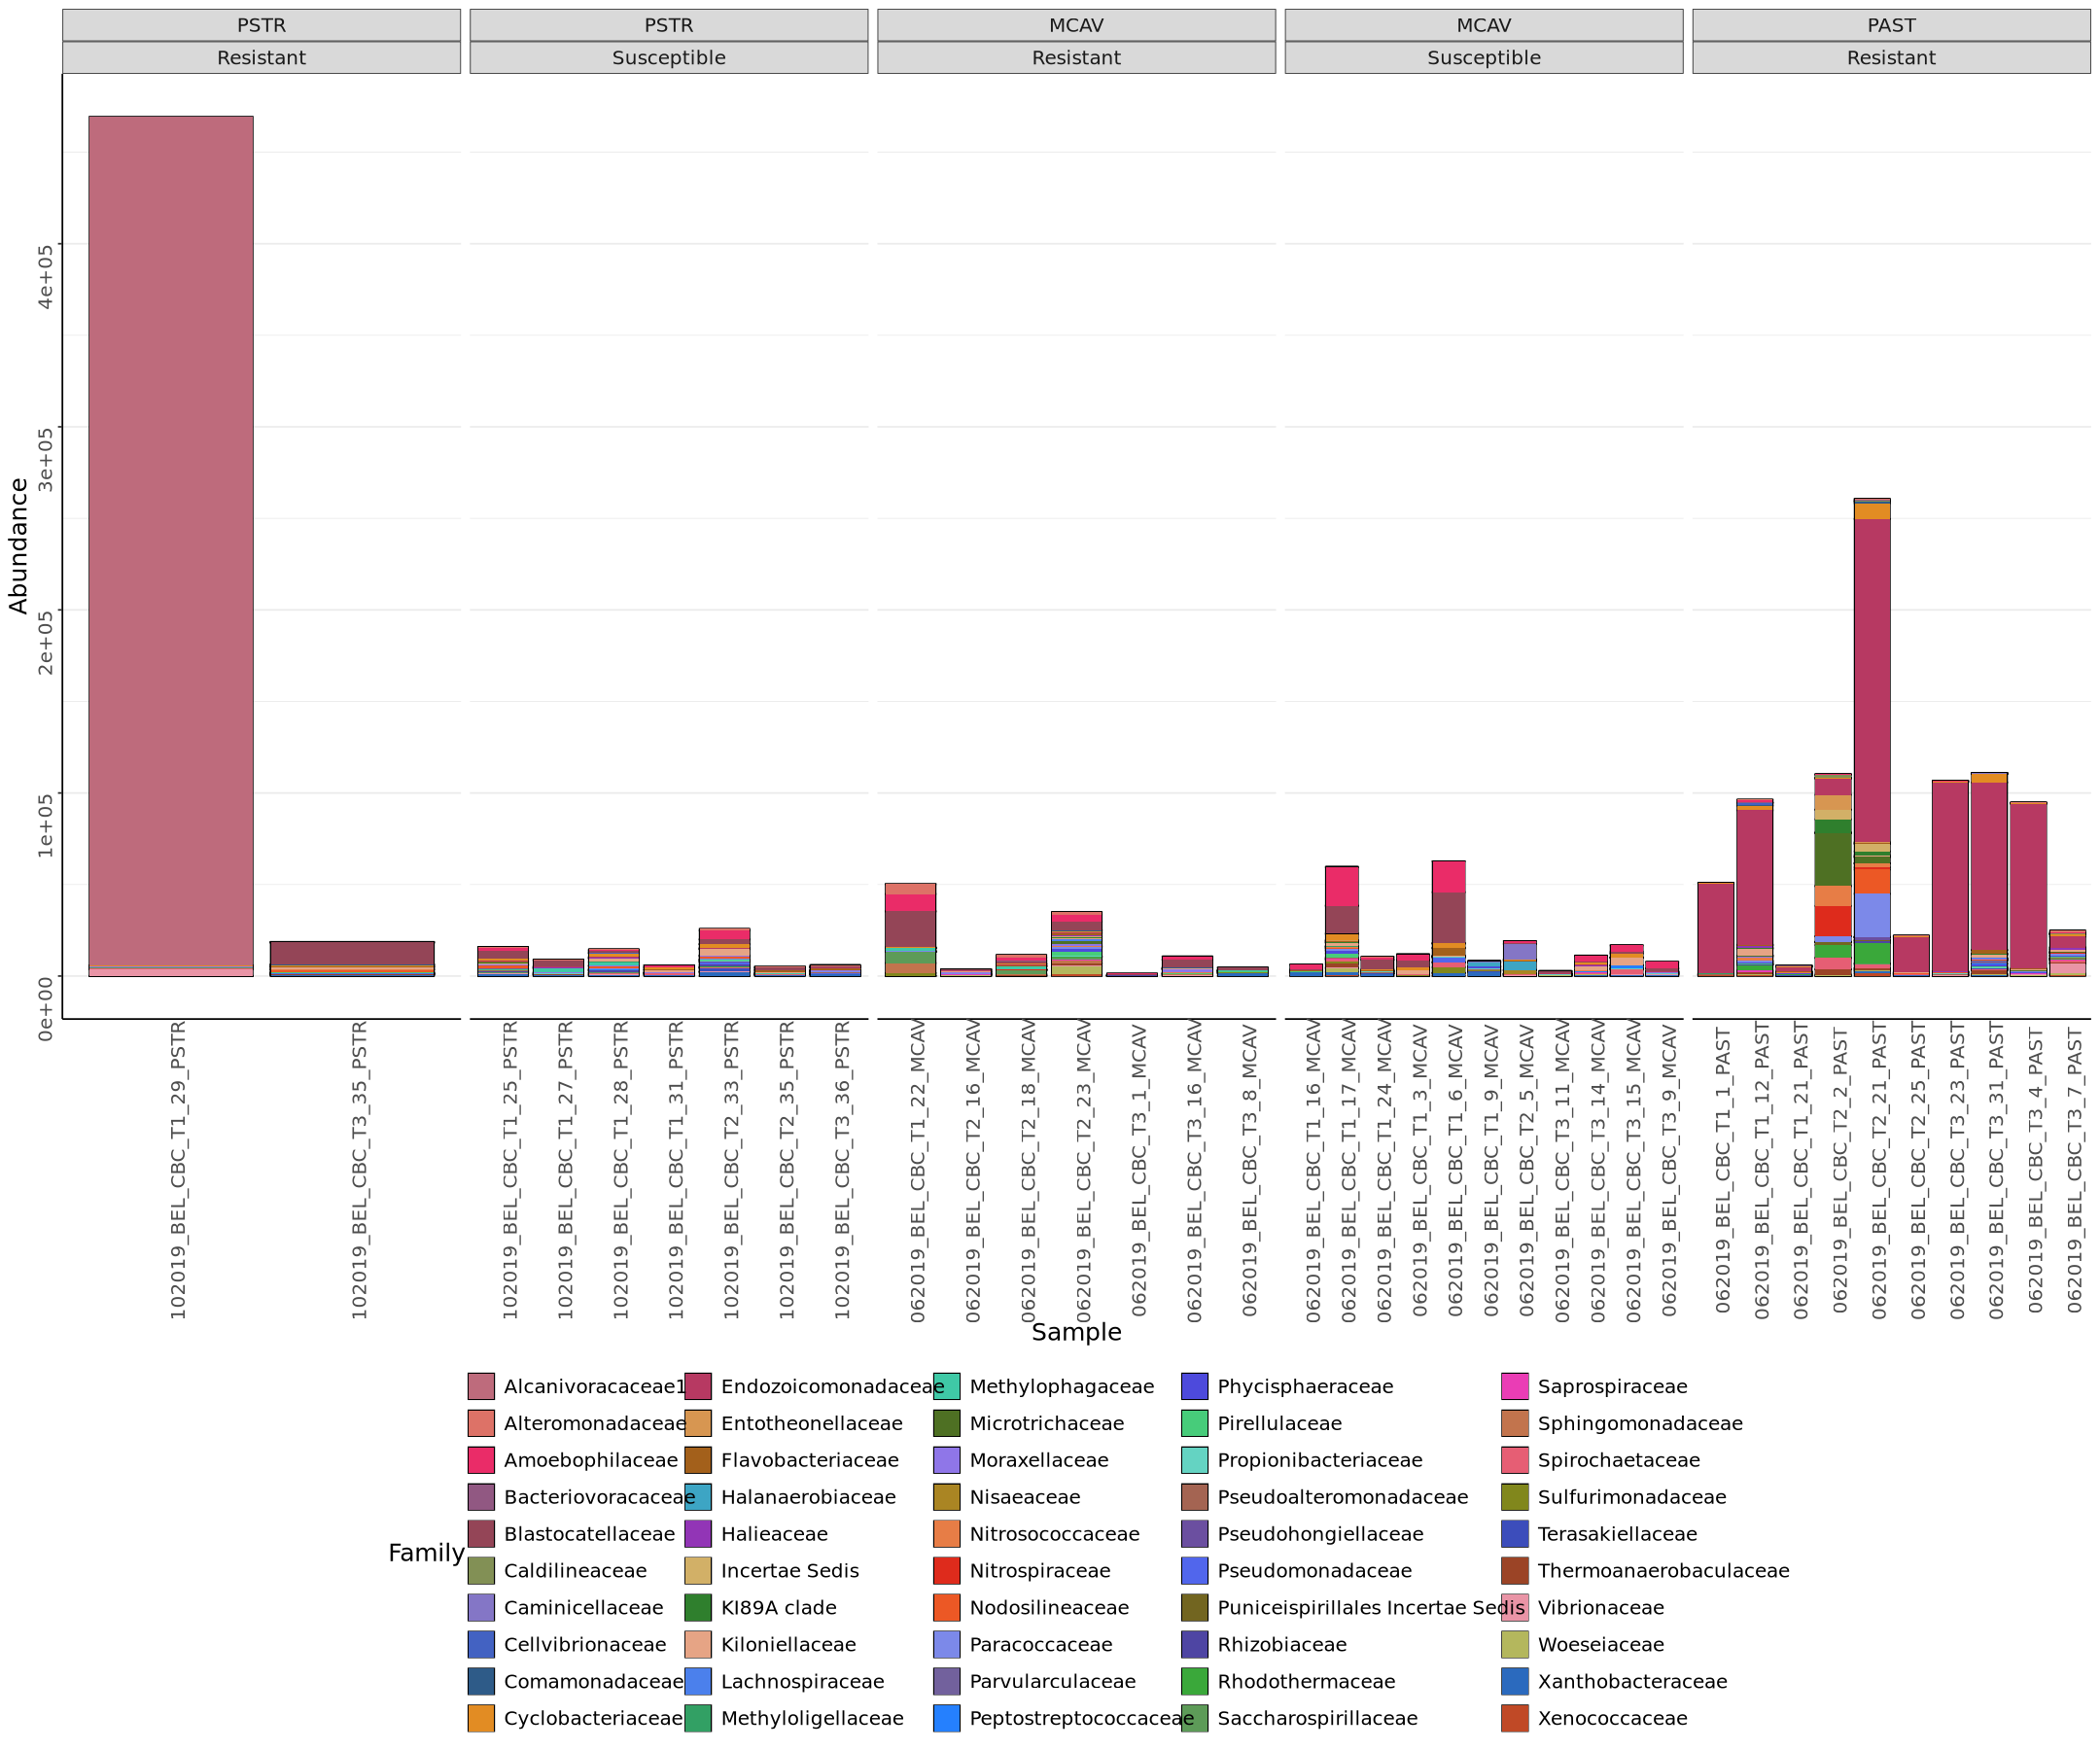

In [48]:
plot_bar(sctld_50_2019,x = "Sample",fill='Family')+
    facet_grid(~ Species + RS, scales = "free_x") +
    geom_bar(aes(fill=Family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# top 50 OTUs (genus) 2019 only - rel abun

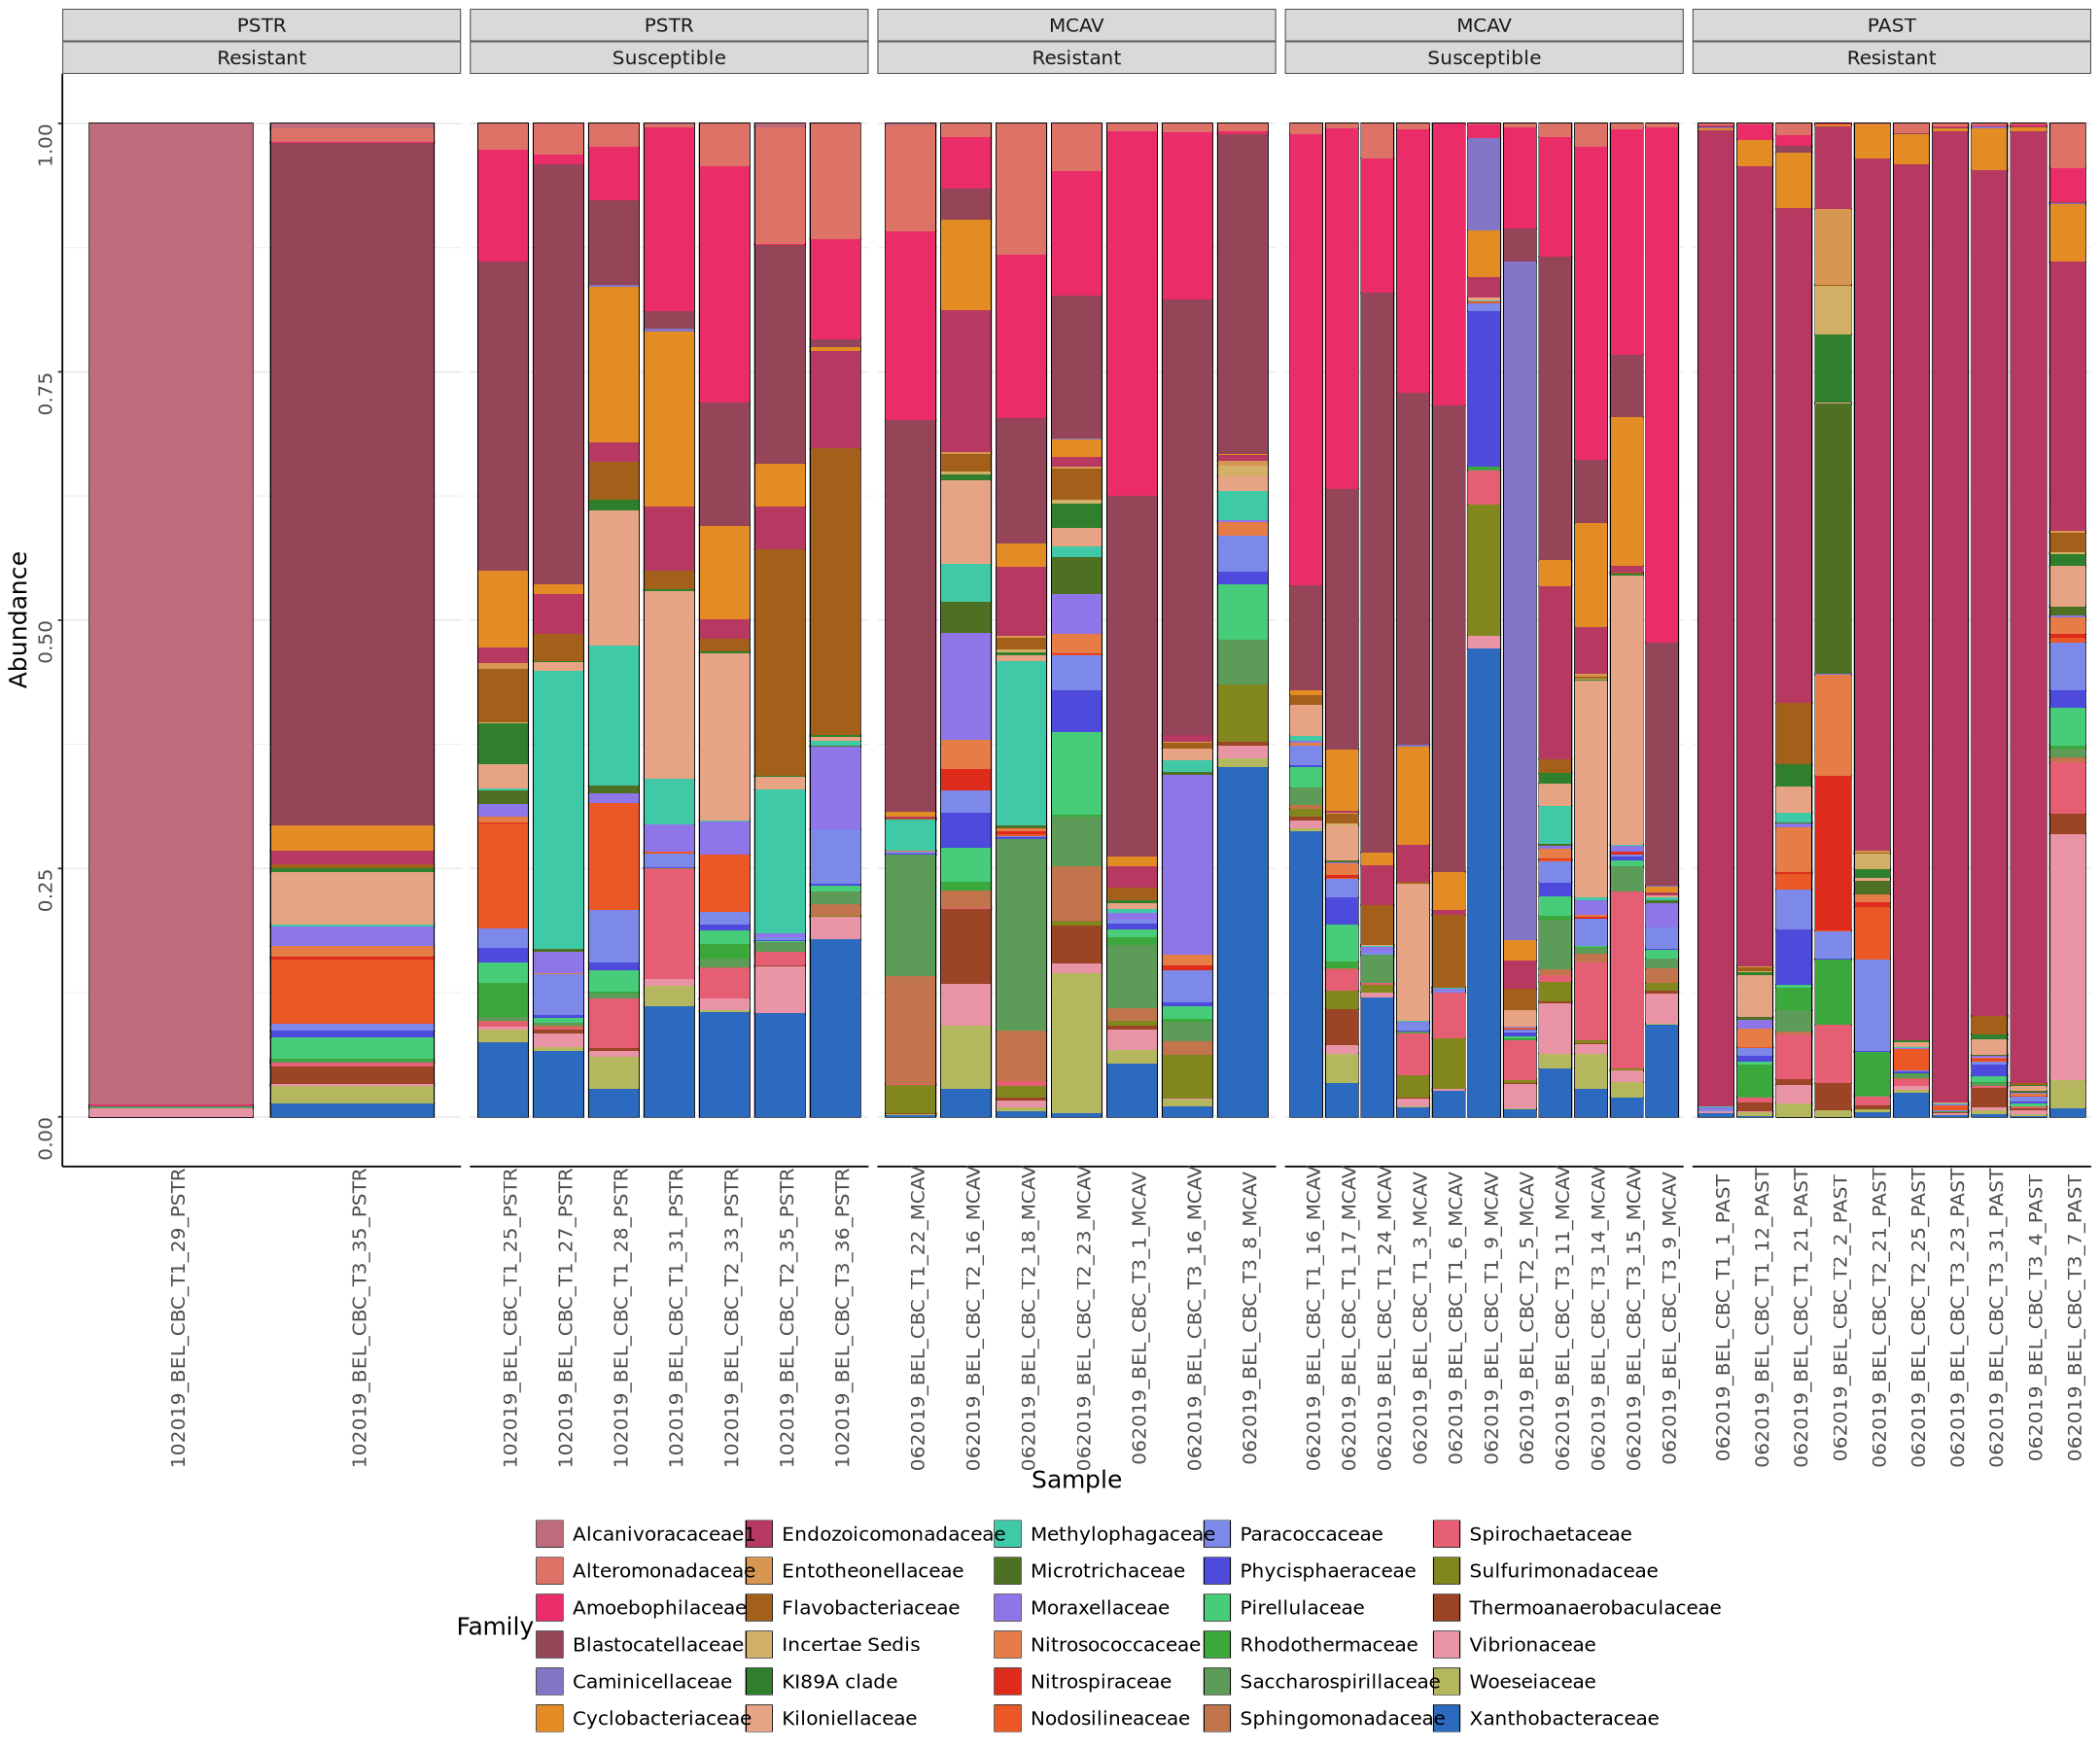

In [49]:
plot_bar(sctld_30_2019_norm,x = "Sample",fill='Family')+
    facet_grid(~ Species + RS, scales = "free_x") +
    geom_bar(aes(fill=Family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# top 30 family 2019 only 

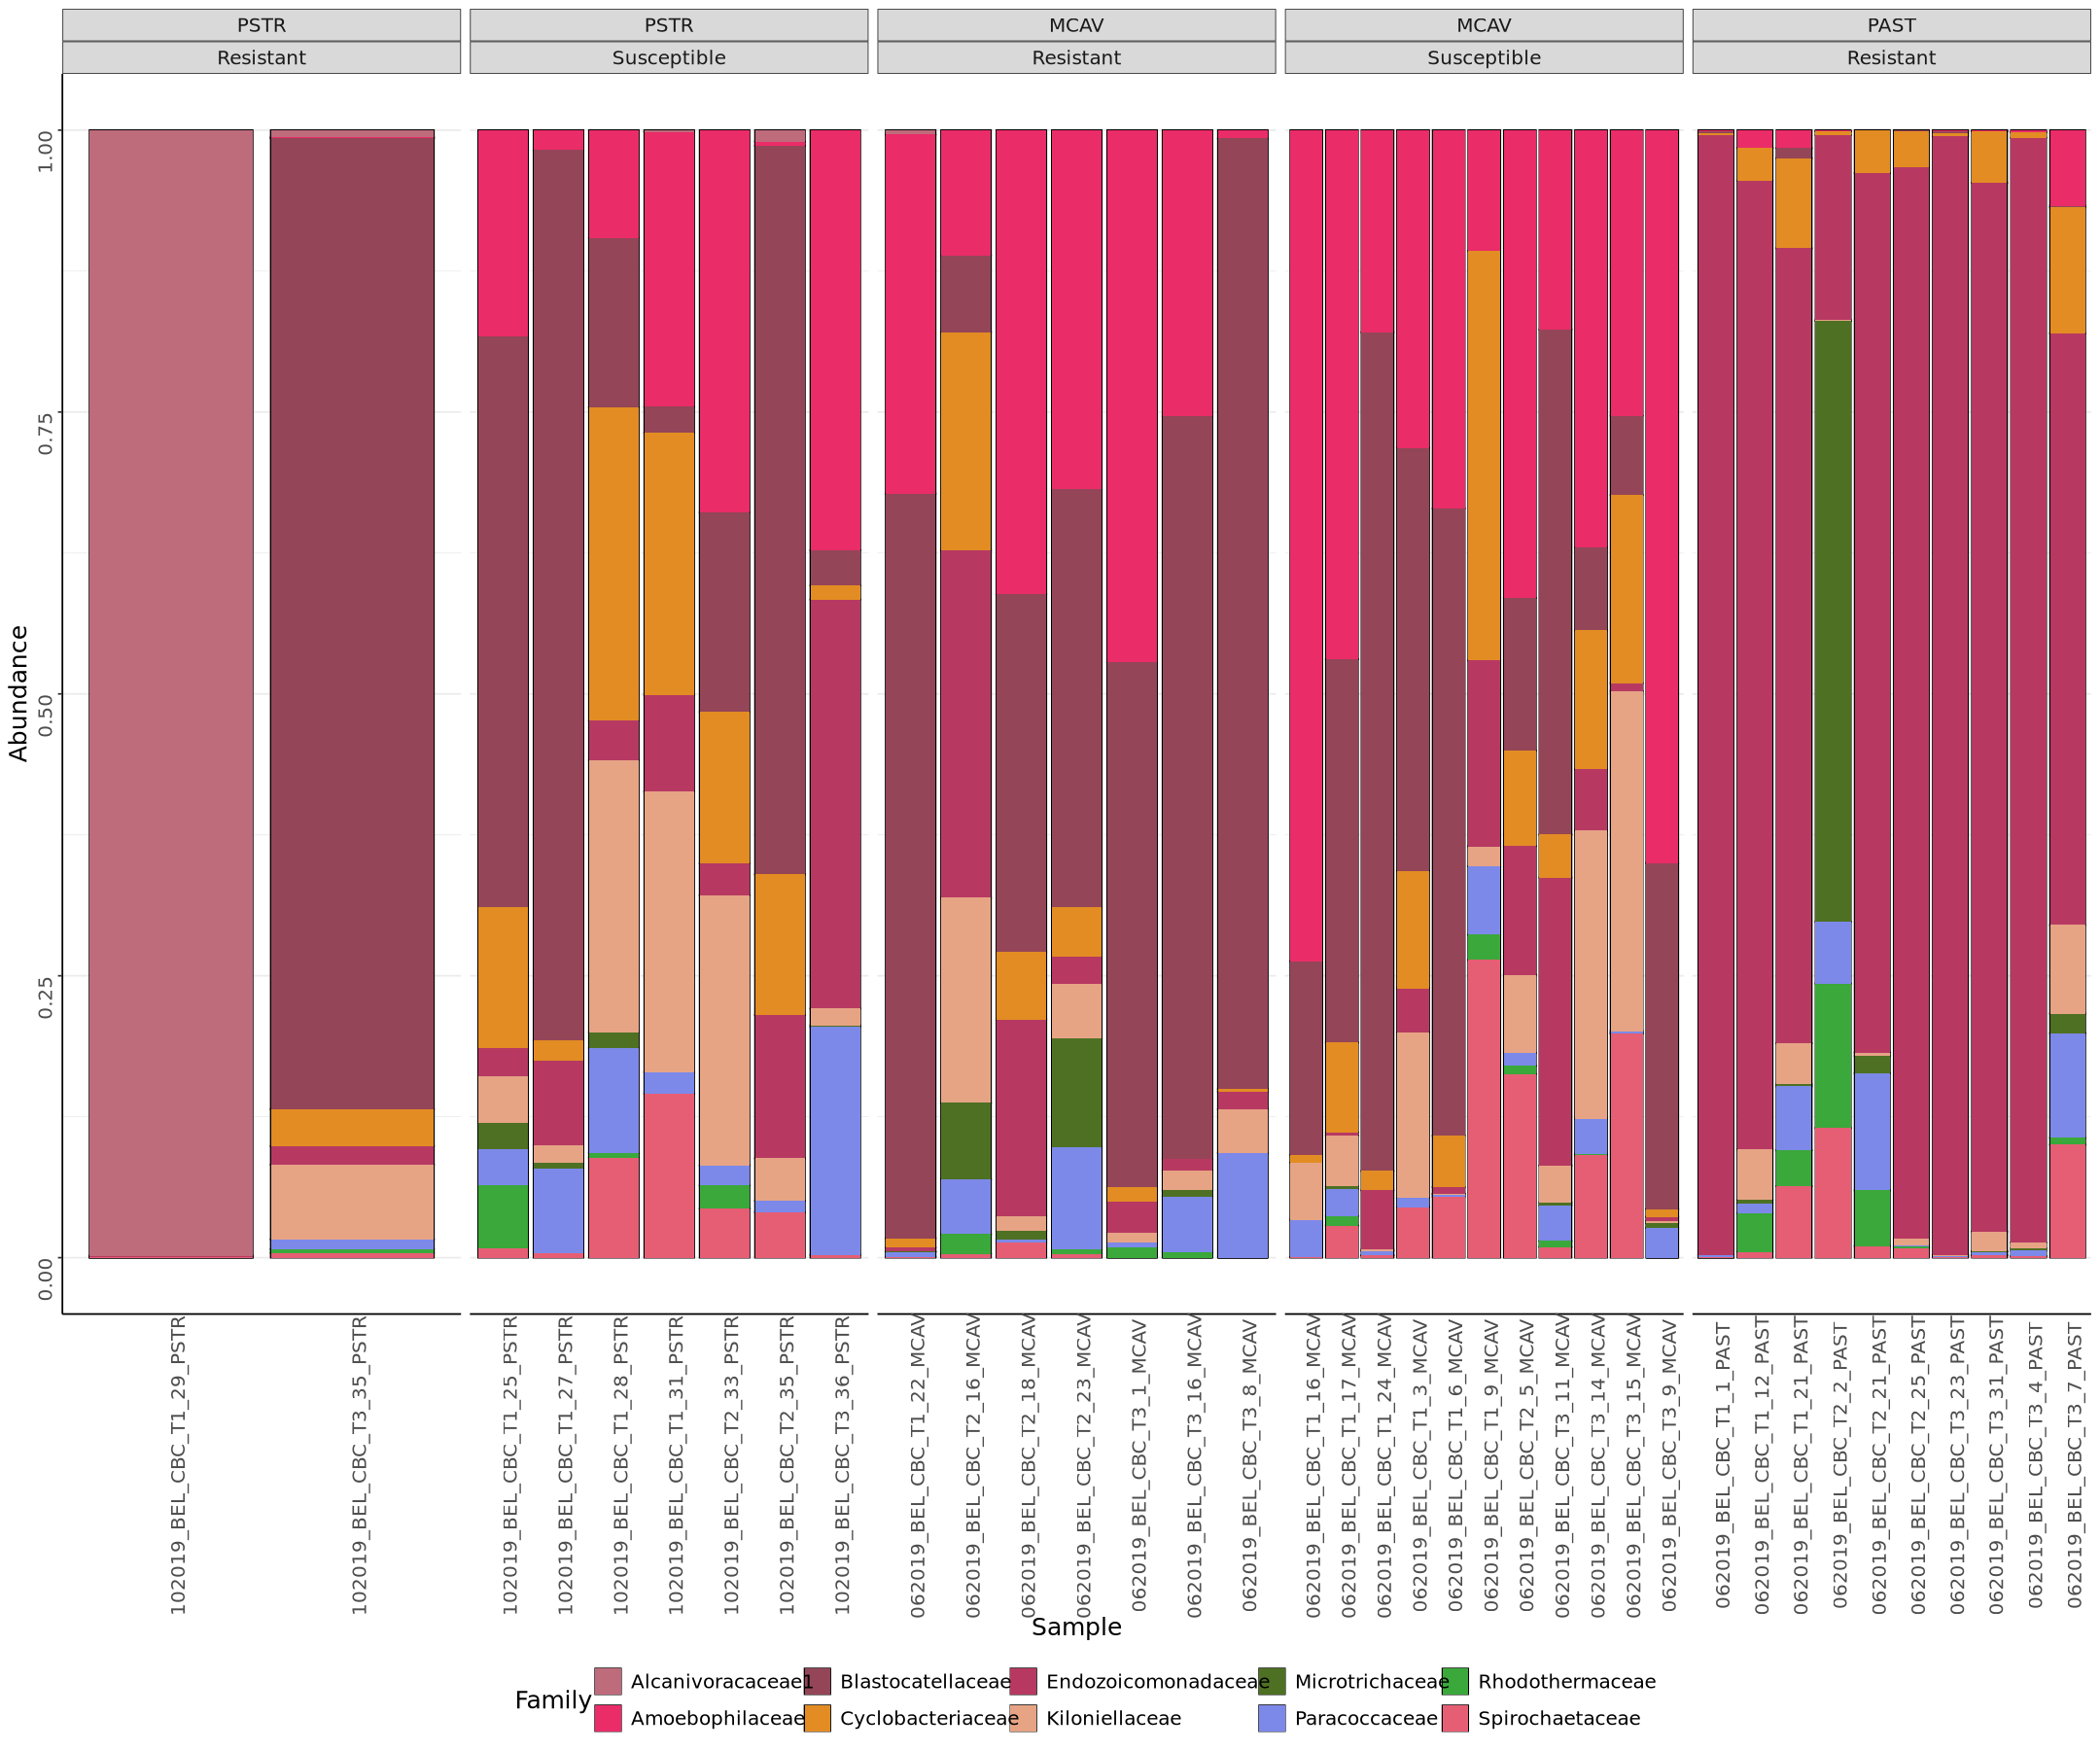

In [50]:
plot_bar(sctld_10_2019_norm,x = "Sample",fill='Family')+
    facet_grid(~ Species + RS, scales = "free_x") +
    geom_bar(aes(fill=Family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# top 10 genera 2019 only 

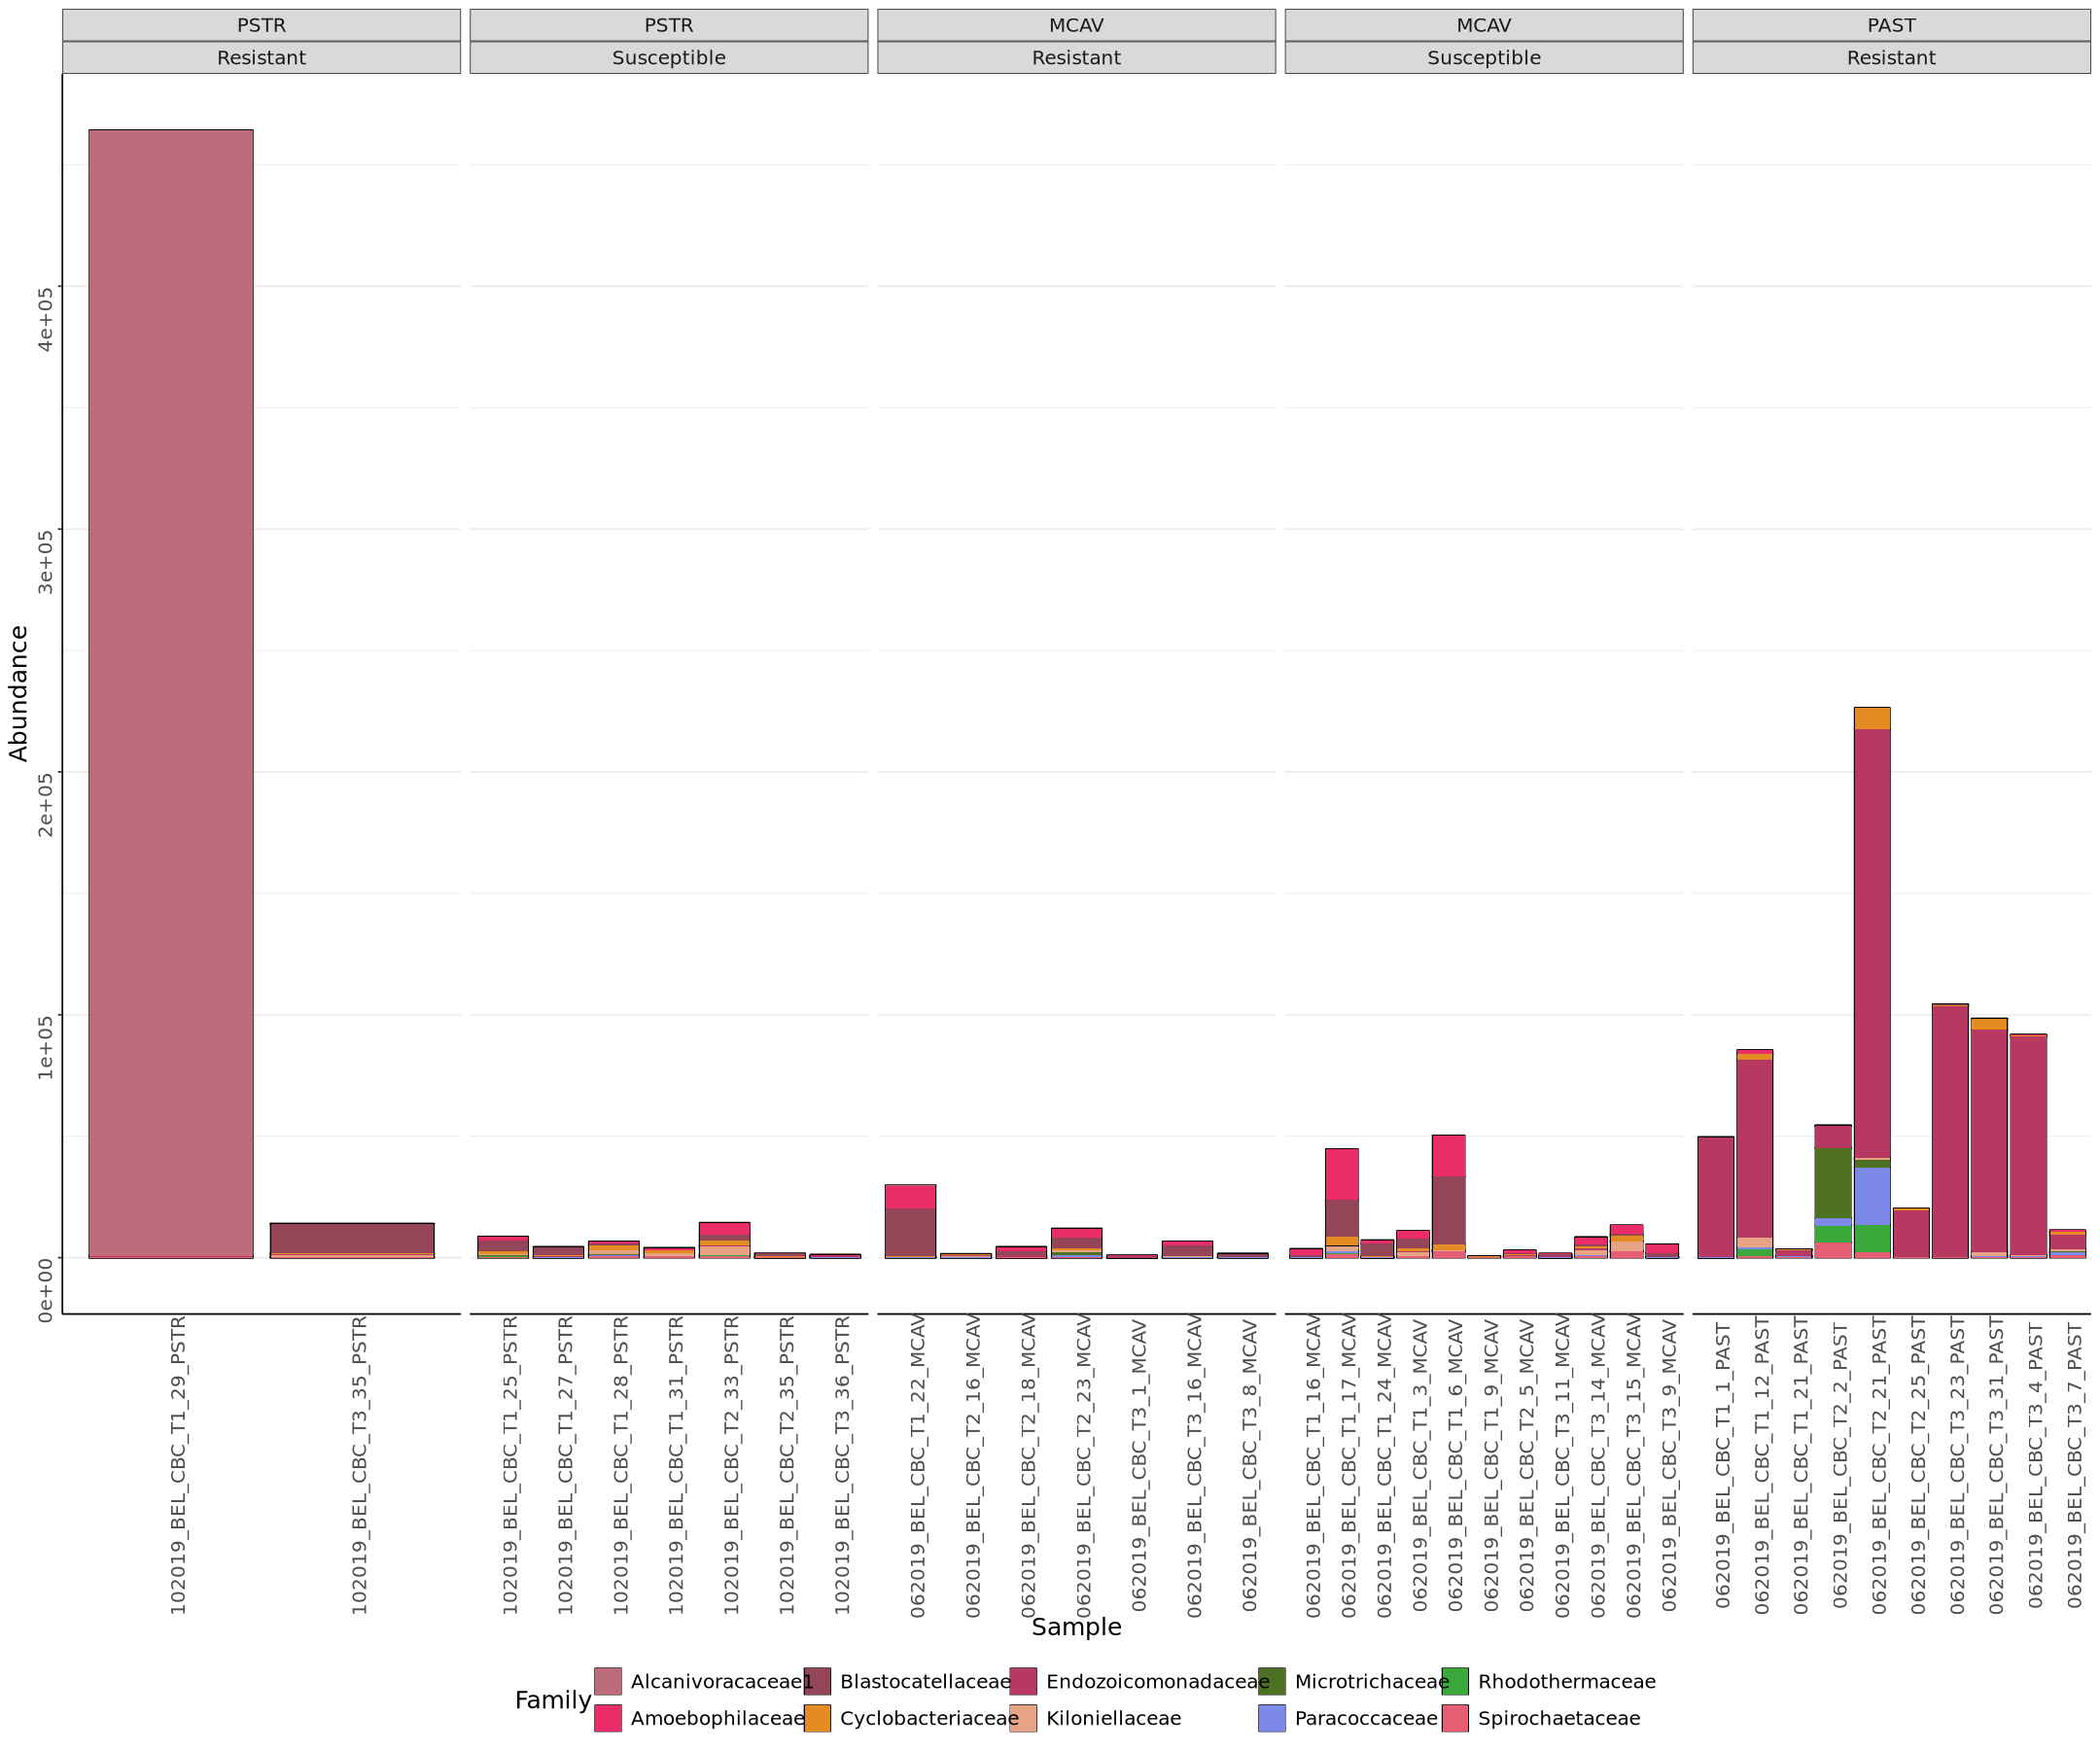

In [51]:
plot_bar(sctld_10_2019,x = "Sample",fill='Family')+
    facet_grid(~ Species + RS, scales = "free_x") +
    geom_bar(aes(fill=Family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# top 10 genera 2019 only - rel abun

In [52]:
# plot each spp individually...

#### MCAV --------------------------------------------------------------------------------

In [53]:
library(ggh4x)
library(patchwork)


Attaching package: ‘ggh4x’


The following object is masked from ‘package:cowplot’:

    save_plot



Attaching package: ‘patchwork’


The following object is masked from ‘package:cowplot’:

    align_plots




In [54]:
options(repr.plot.height = 13, repr.plot.width = 18)

In [55]:
# looking just at mcav, remove disease margin

subset_mcav<- subset_samples(ps, (Species == "MCAV" & Health_status != "Diseased_Margin"))
# and remove newly tagged colonies in 2022 
# dec_tags<-c('12/03/22','12/05/22')
# subset_mcav<- subset_samples(subset_mcav, (!(Date_InitialTag %in% dec_tags)))

In [60]:
mcav_fam <- tax_glom(subset_mcav, taxrank = "Family", NArm = FALSE)
mcav_fam_norm <- transform_sample_counts(mcav_fam, function(x) x / sum(x))
                                          
# filter for top families and normalize within each subsetted PS object
top100_names <- names(sort(taxa_sums(mcav_fam), decreasing = TRUE)[1:100])
mcav_100 <- prune_taxa(top100_names, mcav_fam)
mcav_100_norm <- transform_sample_counts(mcav_100_2019, function(x) x / sum(x))
                                          
top50_names <- names(sort(taxa_sums(mcav_fam), decreasing = TRUE)[1:50])
mcav_50 <- prune_taxa(top50_names, mcav_fam)
mcav_50_norm <- transform_sample_counts(mcav_50_2019, function(x) x / sum(x))

top30_names <- names(sort(taxa_sums(mcav_fam), decreasing = TRUE)[1:30])
mcav_30 <- prune_taxa(top30_names, mcav_fam)
mcav_30_norm <-  transform_sample_counts(mcav_30_2019, function(x) x / sum(x))

top10_names <- names(sort(taxa_sums(mcav_fam), decreasing = TRUE)[1:10])
mcav_10 <- prune_taxa(top10_names, mcav_fam)
mcav_10_norm <- transform_sample_counts(mcav_10_2019, function(x) x / sum(x))

In [61]:
df_meta <- data.frame(sample_data(subset_mcav))

# 2. Re-level Sample IDs based on Month_year order
df_meta <- df_meta %>% 
  arrange(colony_id,Month_year) %>% 
  mutate(sampleid = factor(sampleid, levels = unique(sampleid)))

# 3. Update sample_data in your phyloseq object
sample_data(subset_mcav) <- sample_data(df_meta)

In [62]:
# reorder colonies
mcav_g_S<-subset_samples(subset_mcav, RS == "Susceptible")
df_meta<-data.frame(sample_data(mcav_g_S))
# make order for X122022_Condition
df_meta <- df_meta %>% 
    mutate(X122022_Condition = factor(X122022_Condition, levels = c('Healthy','Diseased','Dead','Not_Visited'))) %>%
    arrange(colony_id, X122022_Condition)
# reorder colonies by condition factor levels
col_order <- df_meta %>%
  distinct(colony_id, X122022_Condition) %>%
  arrange(X122022_Condition, colony_id) %>%
  pull(colony_id)

sample_data(mcav_g_S)$colony_id <-
  factor(sample_data(mcav_g_S)$colony_id, levels = col_order)

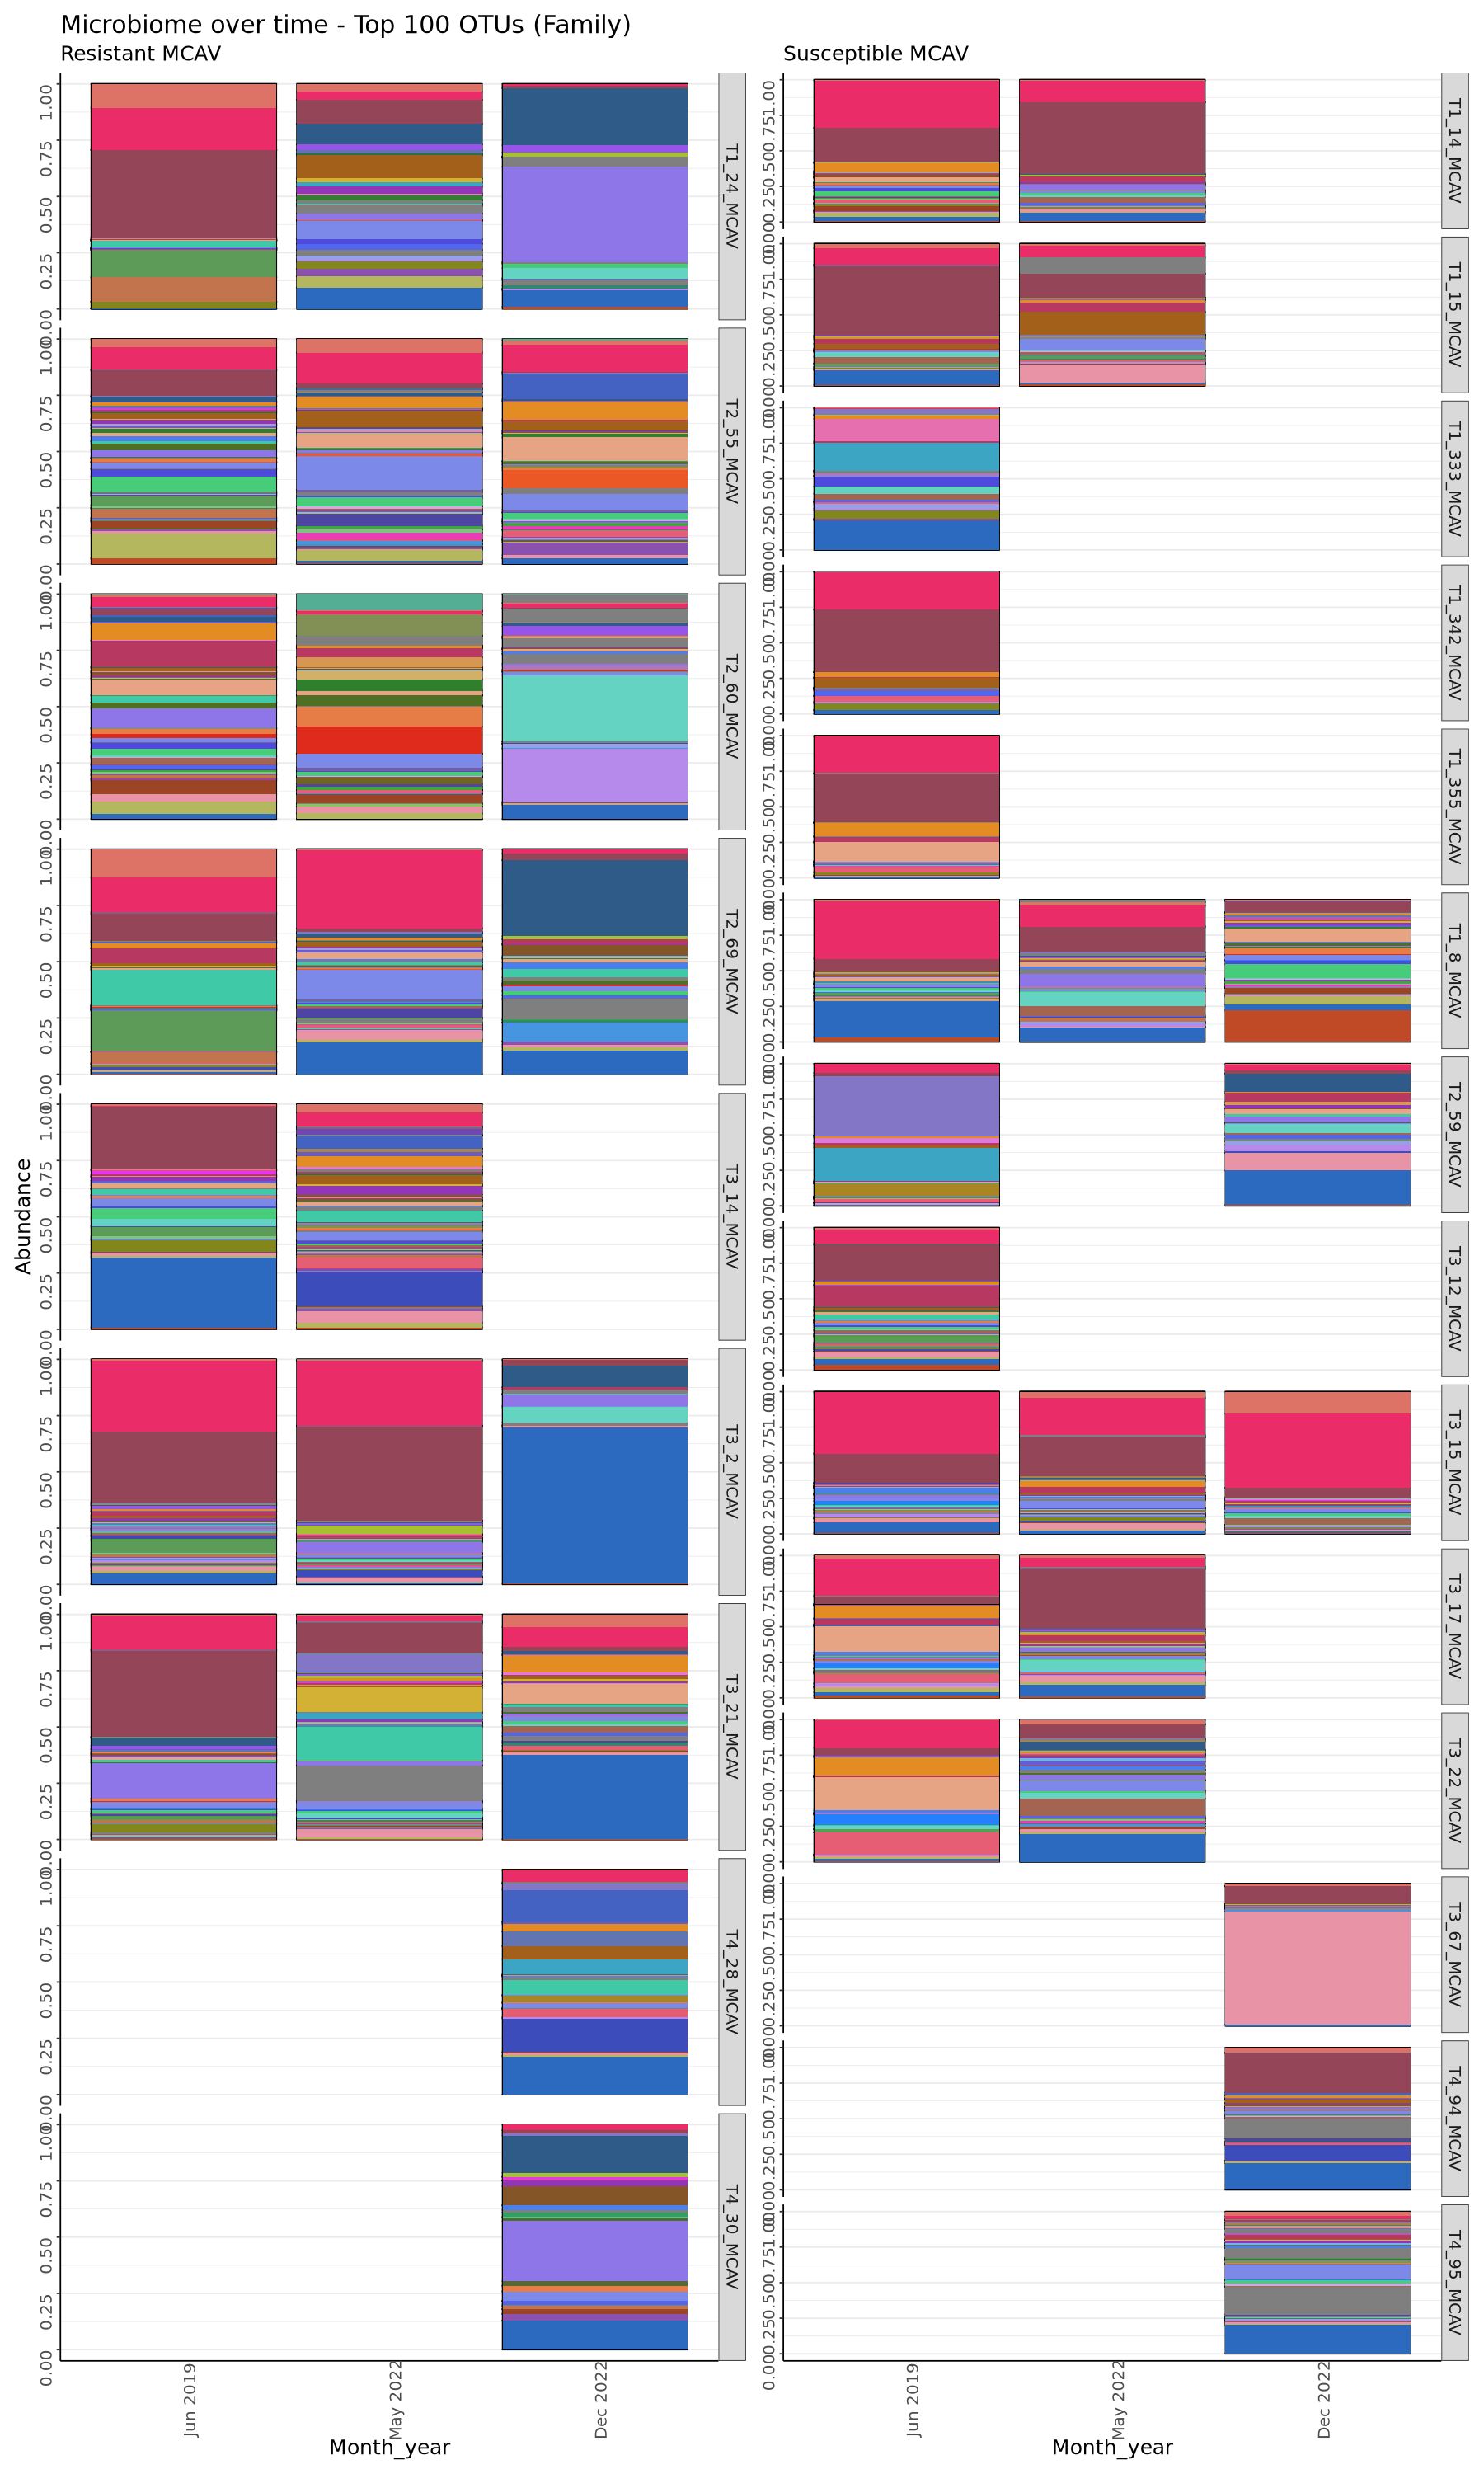

In [63]:
options(repr.plot.height = 25, repr.plot.width = 15)
p_R <- plot_bar(subset_samples(mcav_100_norm, RS == "Resistant"),x = "Month_year", fill = "Family")+
    facet_grid(colony_id ~ .)+
    geom_bar(aes(x = Month_year,fill=Family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position = "none",panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))+
    labs(title = "Microbiome over time - Top 100 OTUs (Family)",subtitle = "Resistant MCAV")

p_S <- plot_bar(subset_samples(mcav_100_norm, RS == "Susceptible"),x = "Month_year", fill = "Family") +
    facet_grid(colony_id ~ .)+
    geom_bar(aes(x = Month_year,fill=Family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position = "none",panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))+
    labs(subtitle = "Susceptible MCAV", y = NULL)
p_R | p_S +
  plot_layout(guides = "collect") +
  theme(legend.position = "none")

In [64]:
# see legend for below plot

# label when colonies died and sort
# should i remove colonies tagged in dec 2022? 

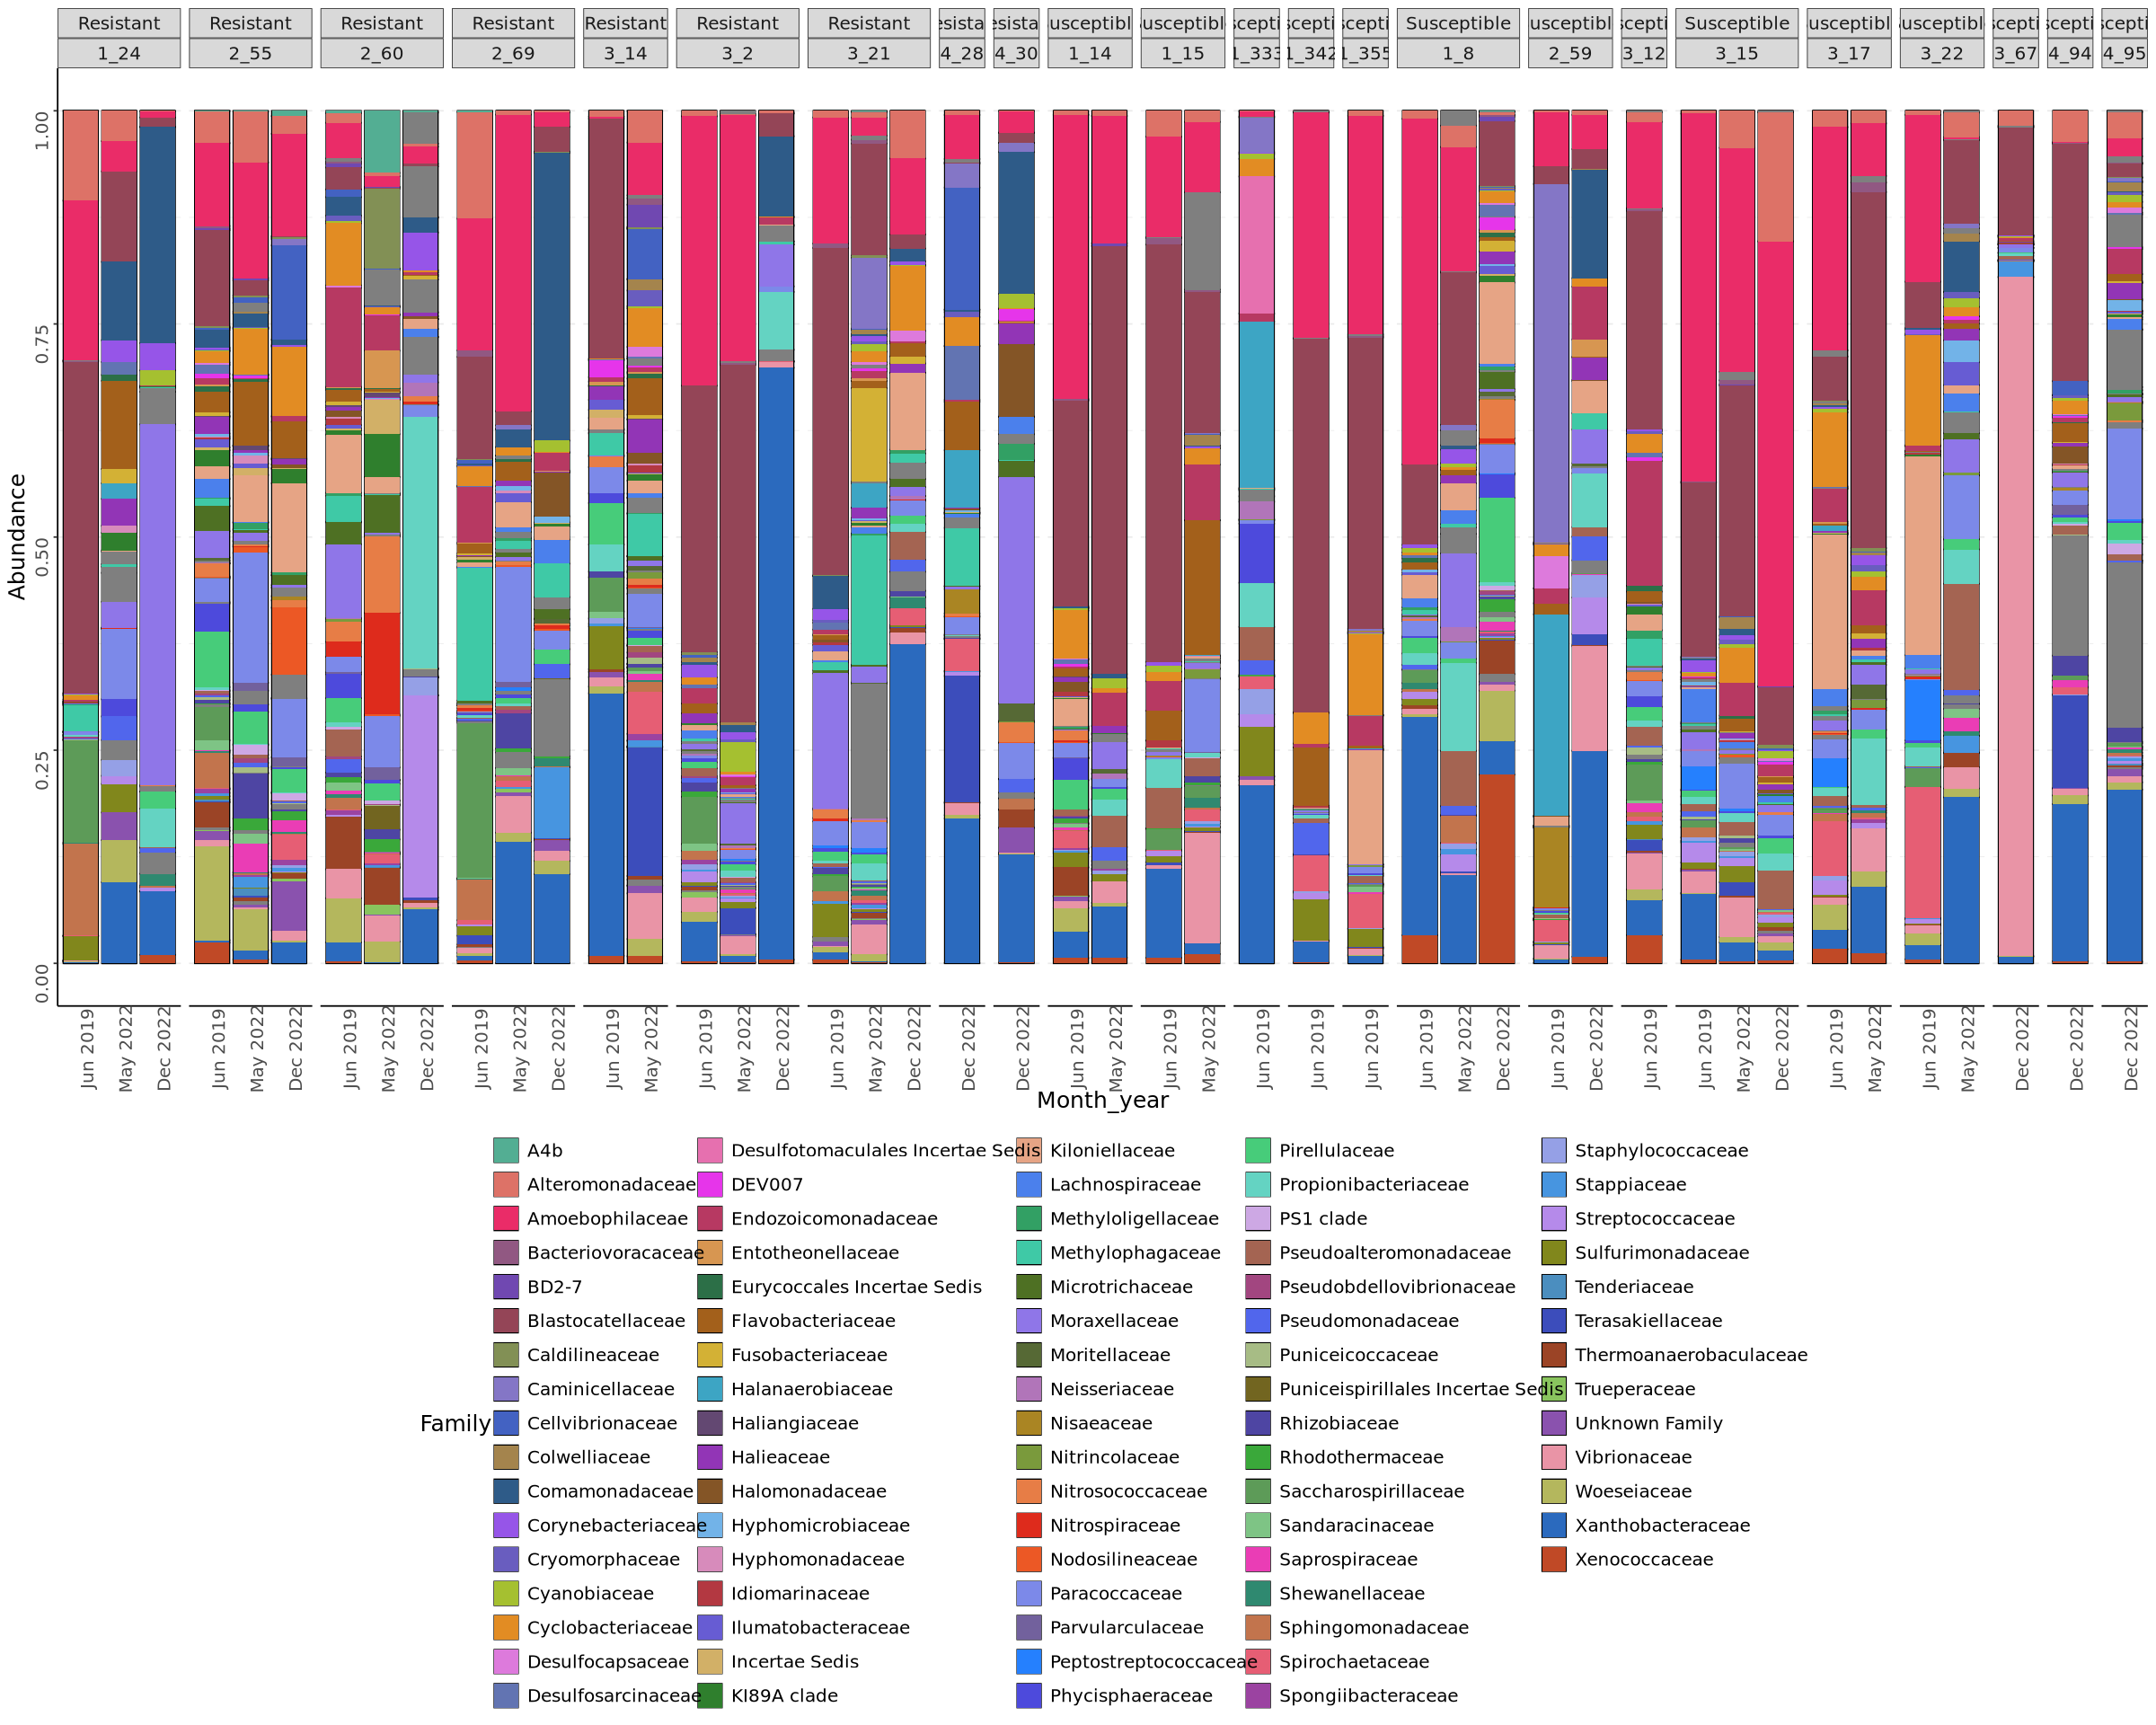

In [65]:
# want: single colony over time, facet by r vs s instead? 
# tried to use ggh4x:facet_nested but am getting weird error: could not find function "is_theme_element"
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(mcav_100_norm,x = "Month_year",fill='Family')
p+facet_grid(~RS+colony, scales="free_x", space = "free_x")+
    geom_bar(aes(x = Month_year,fill=Family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 100 OTUs (Family)
# individuals over time (healthy -> diseased tissue if susceptible)

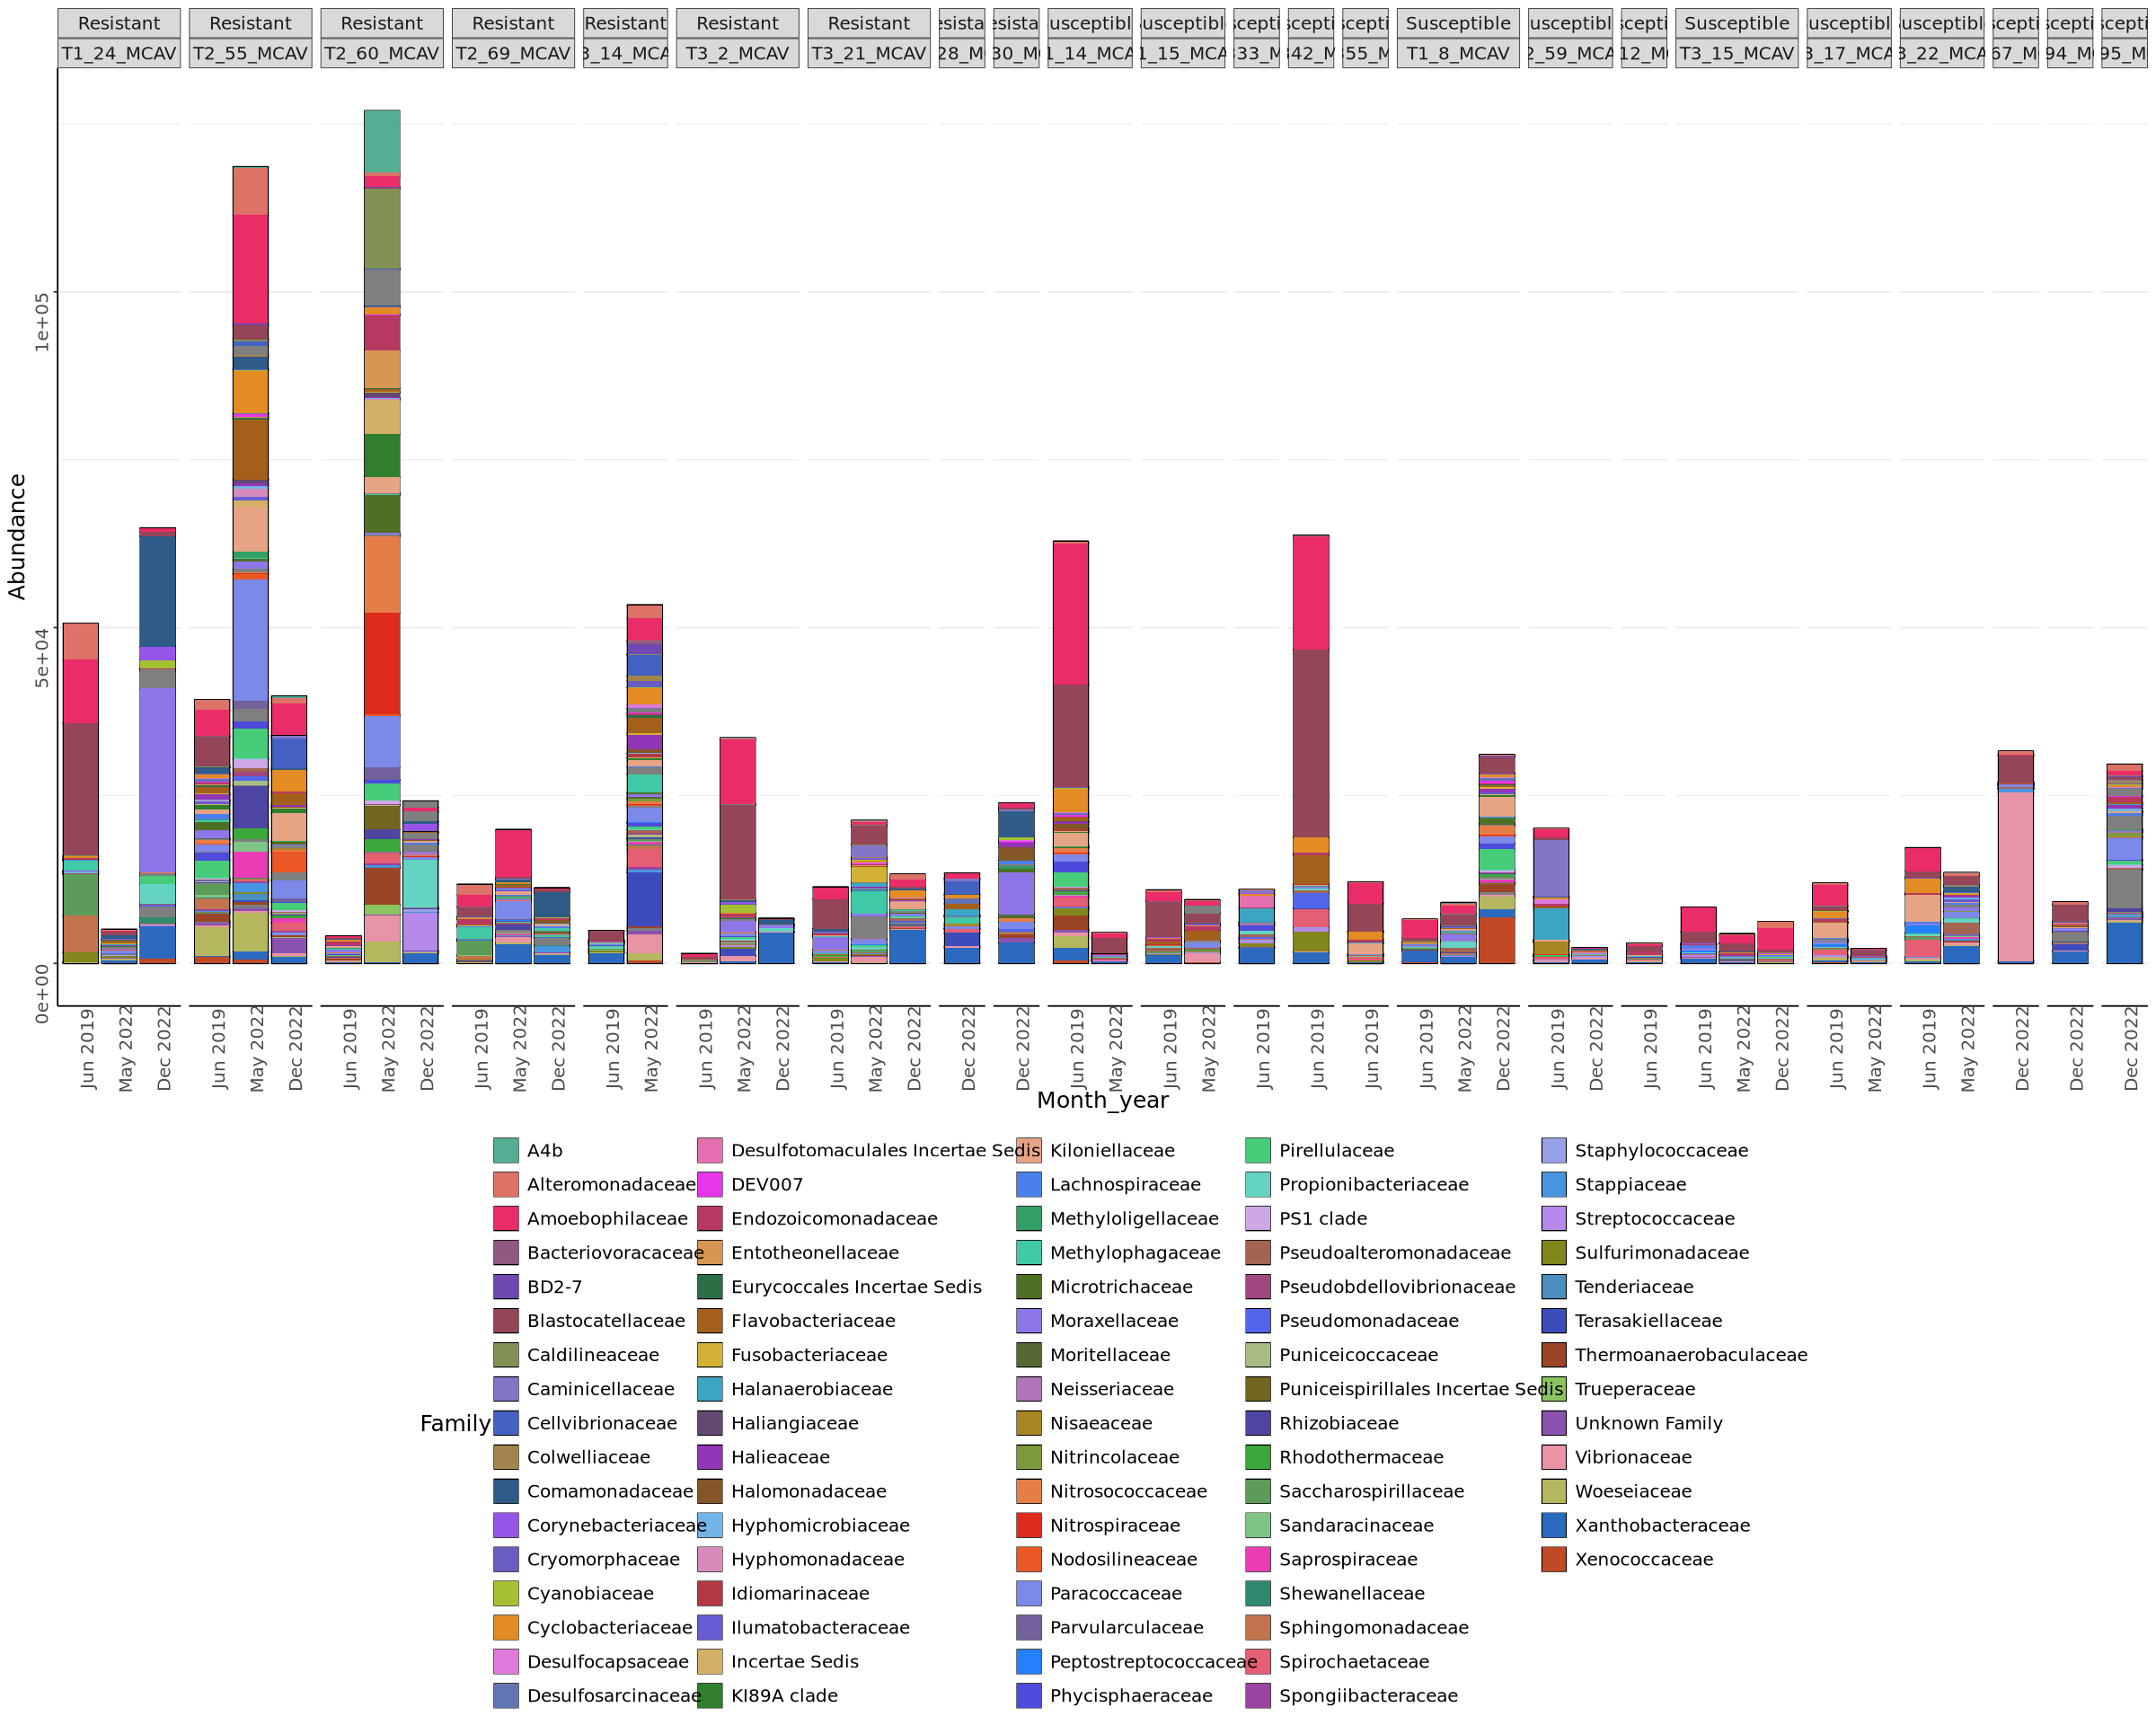

In [66]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(mcav_100,x = "Month_year",fill='Family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = Month_year,fill=Family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# abundances - top 100 Family rel abun

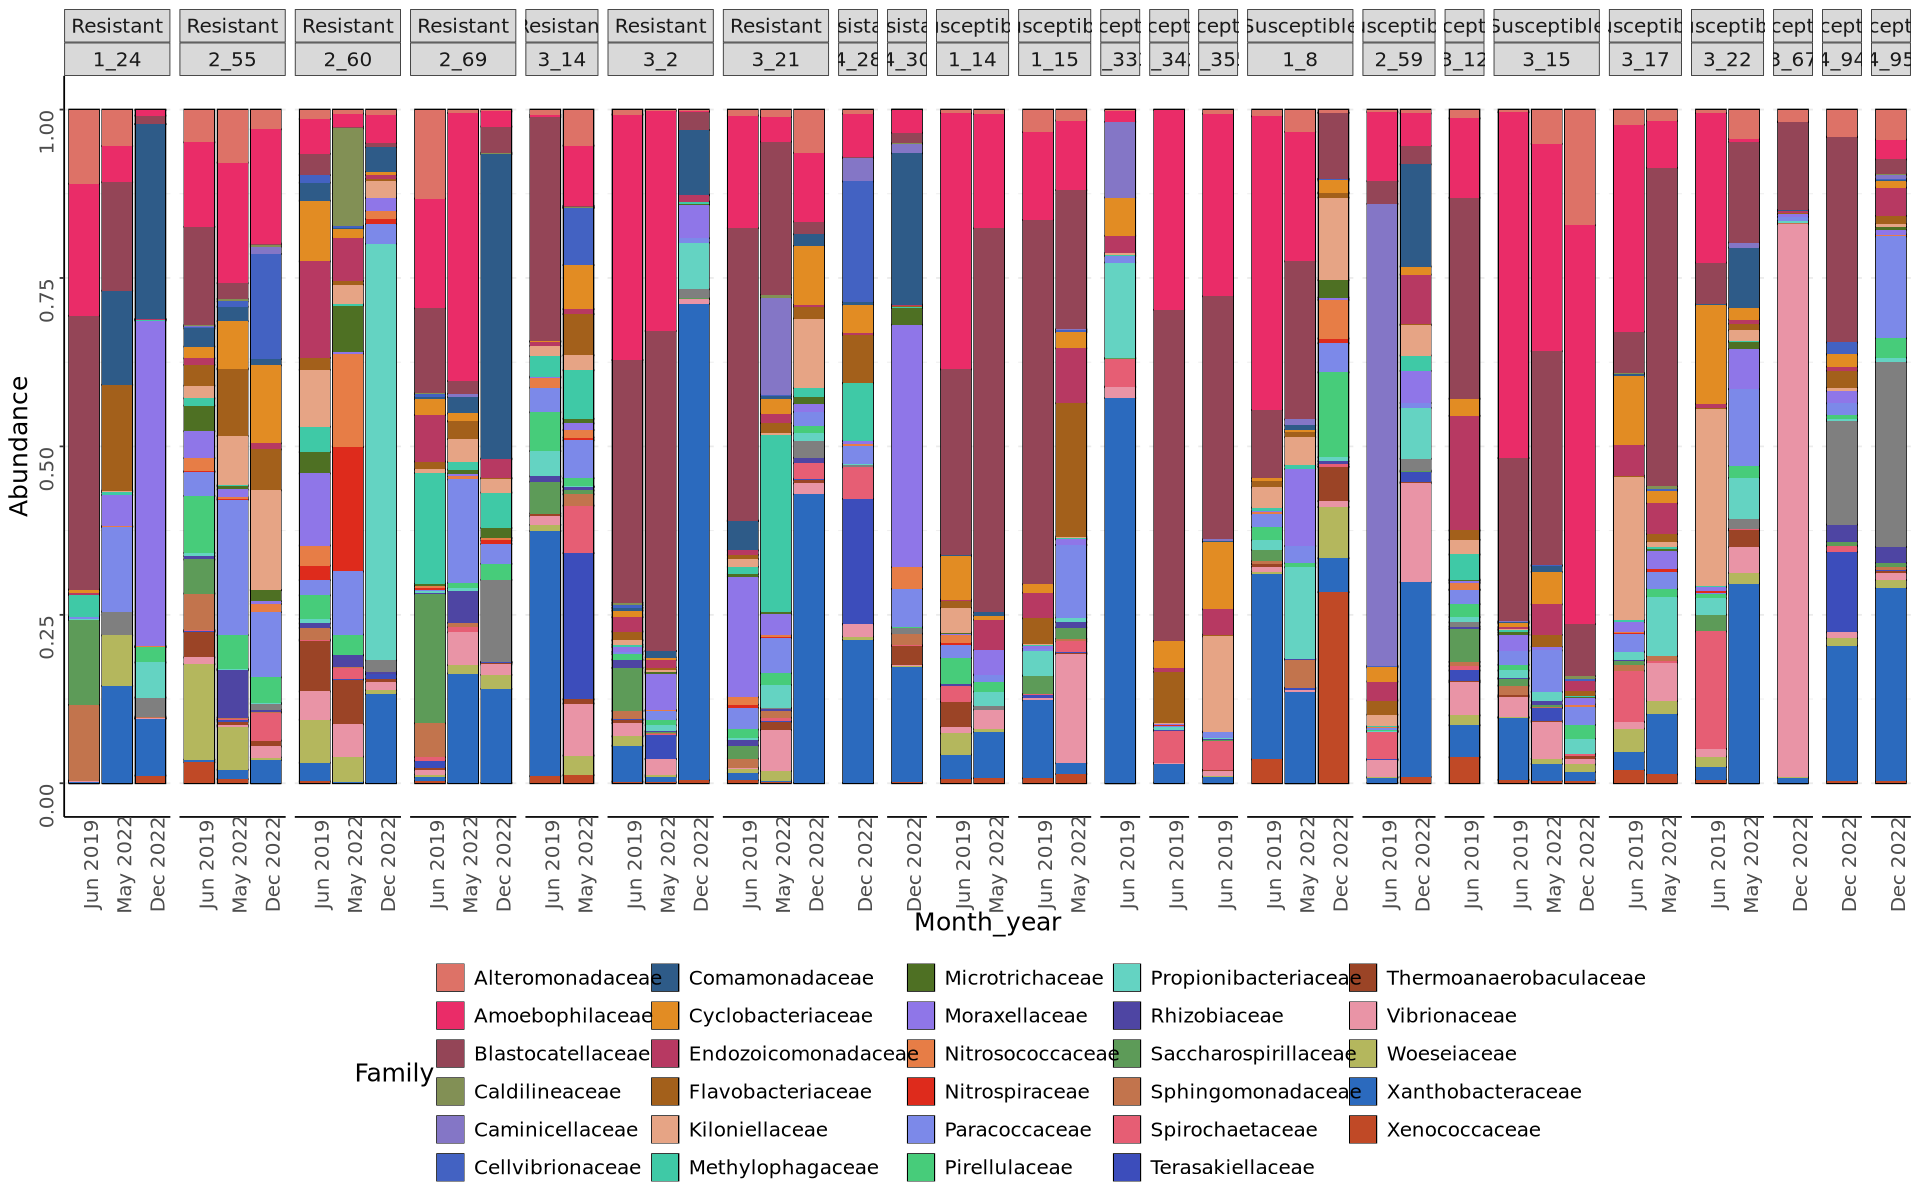

In [67]:
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(mcav_30_norm,x = "Month_year",fill='Family')
p+facet_grid(~RS+colony, scales="free_x", space = "free_x")+
    geom_bar(aes(x = Month_year,fill=Family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 30 Family - R vs S. individuals over time 

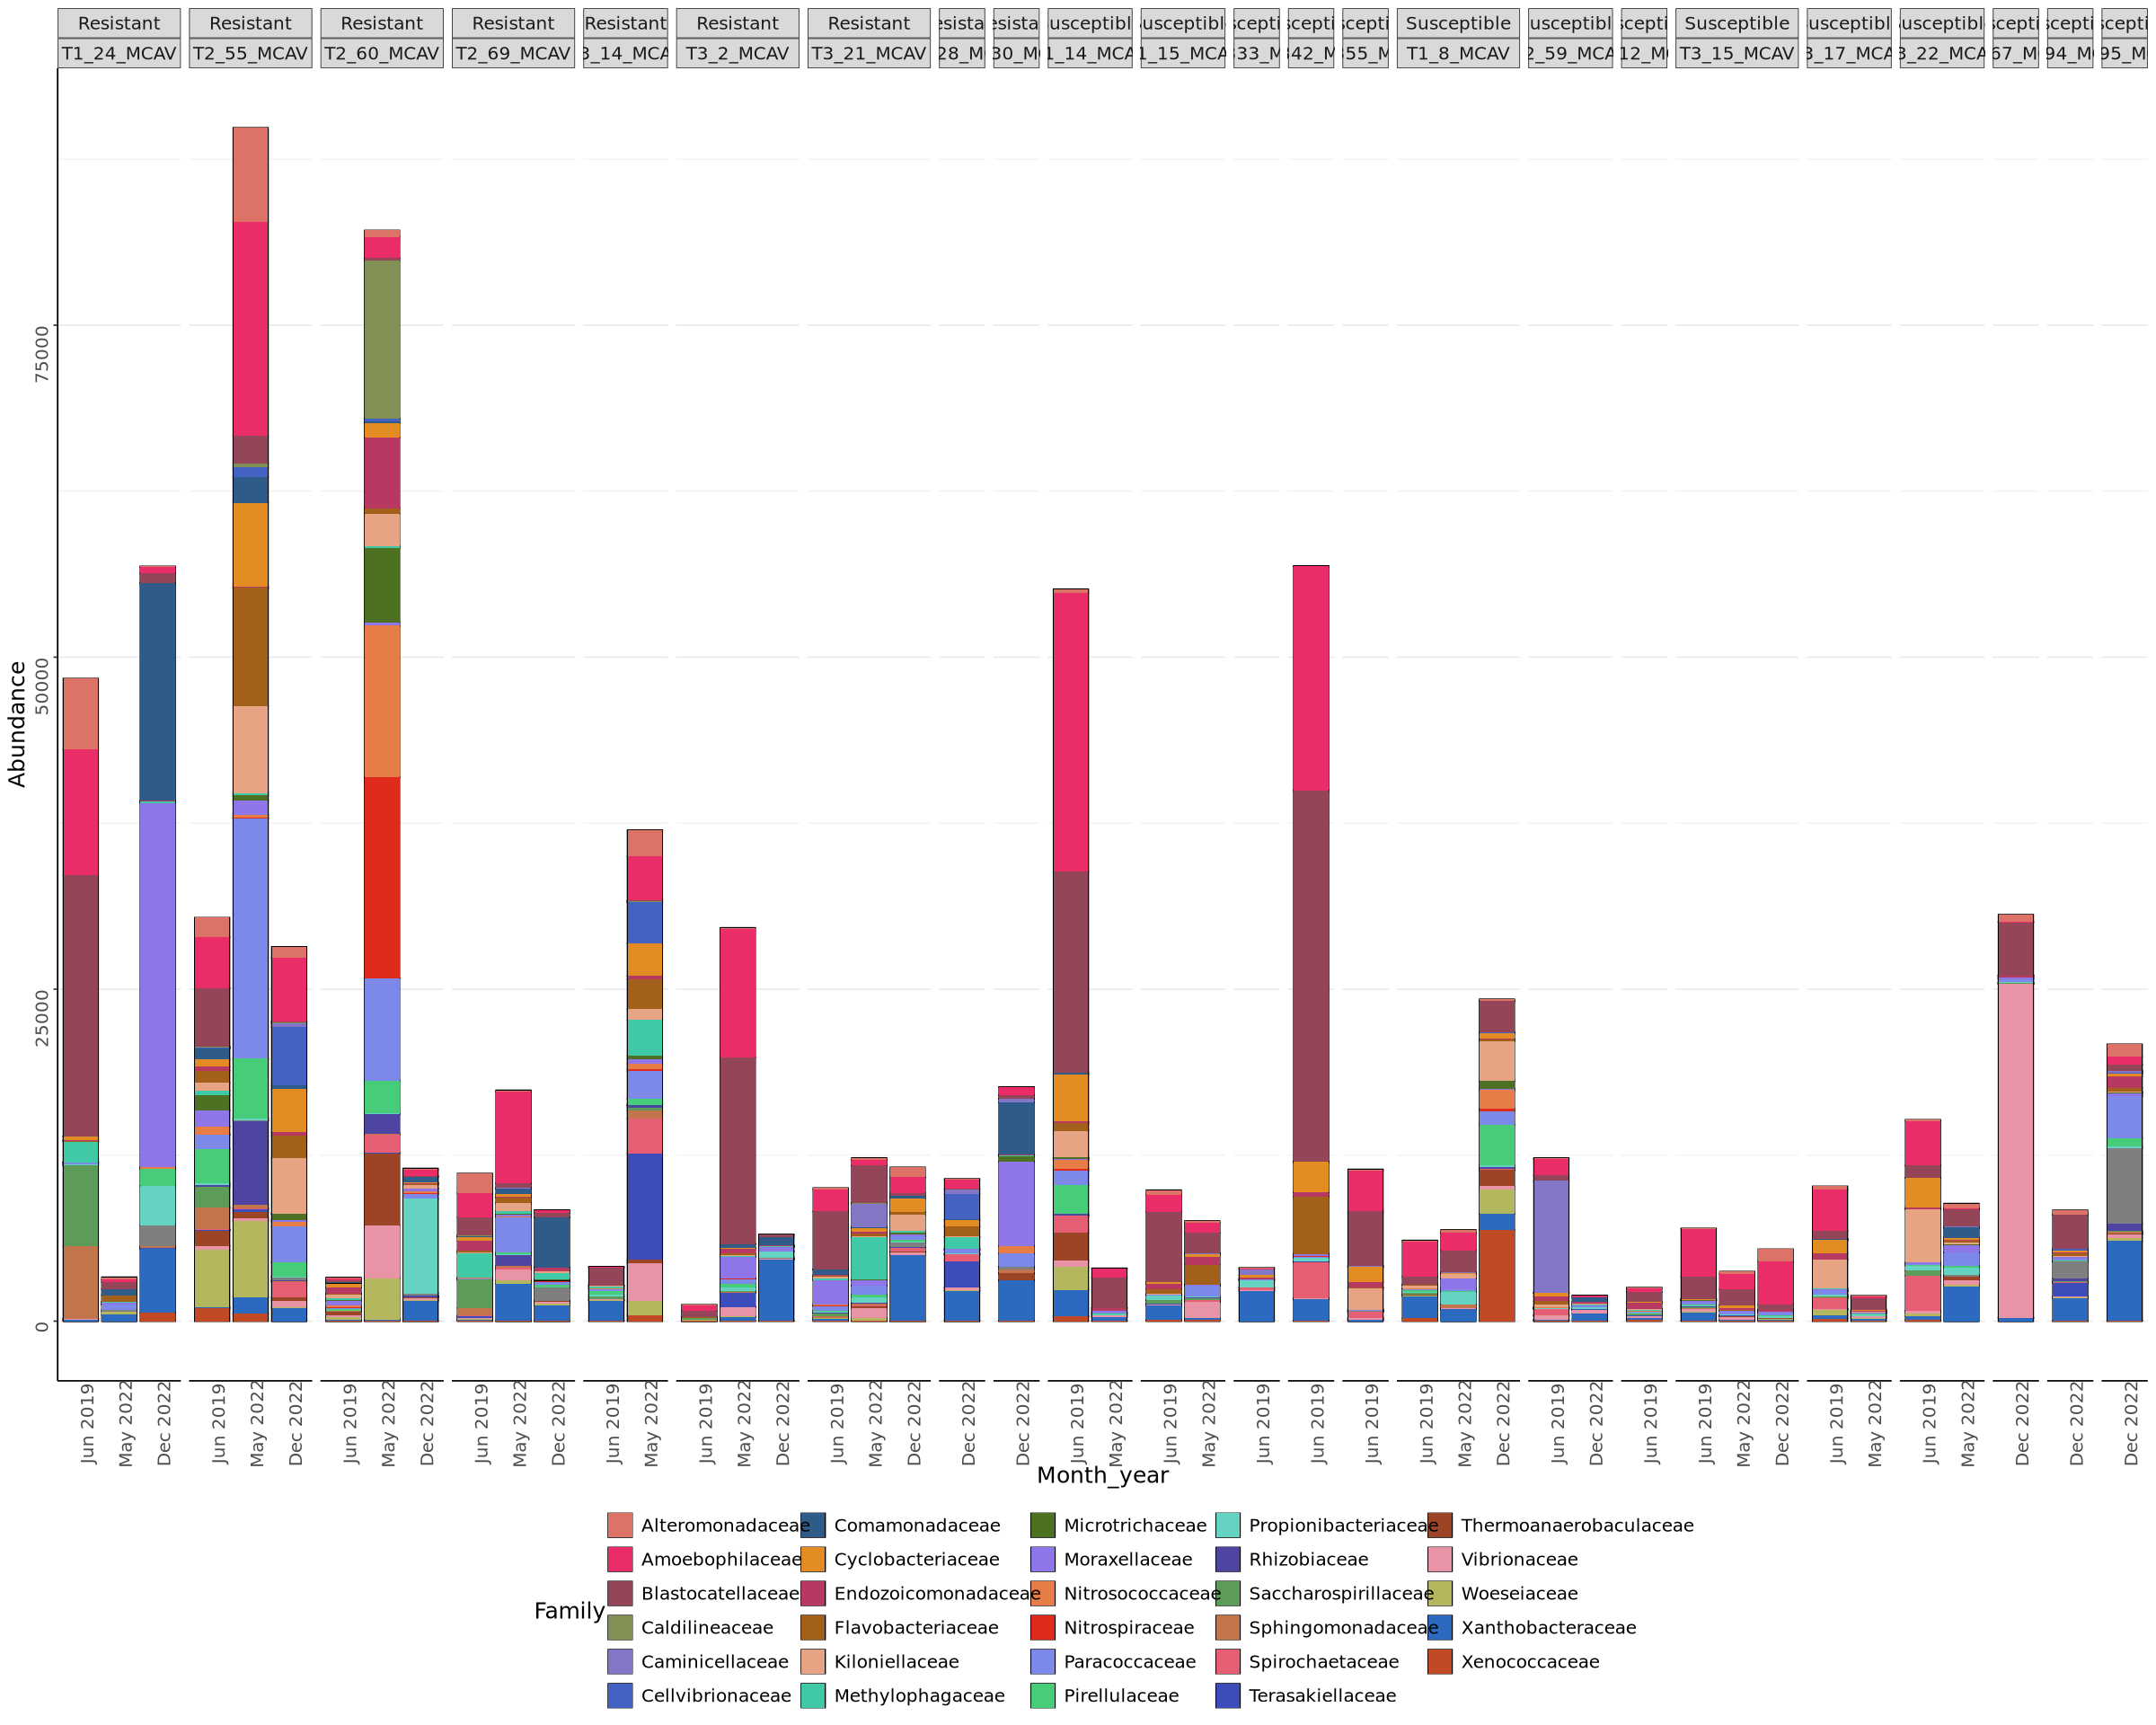

In [68]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(mcav_30,x = "Month_year",fill='Family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = Month_year,fill=Family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# abundances - top 30 Family

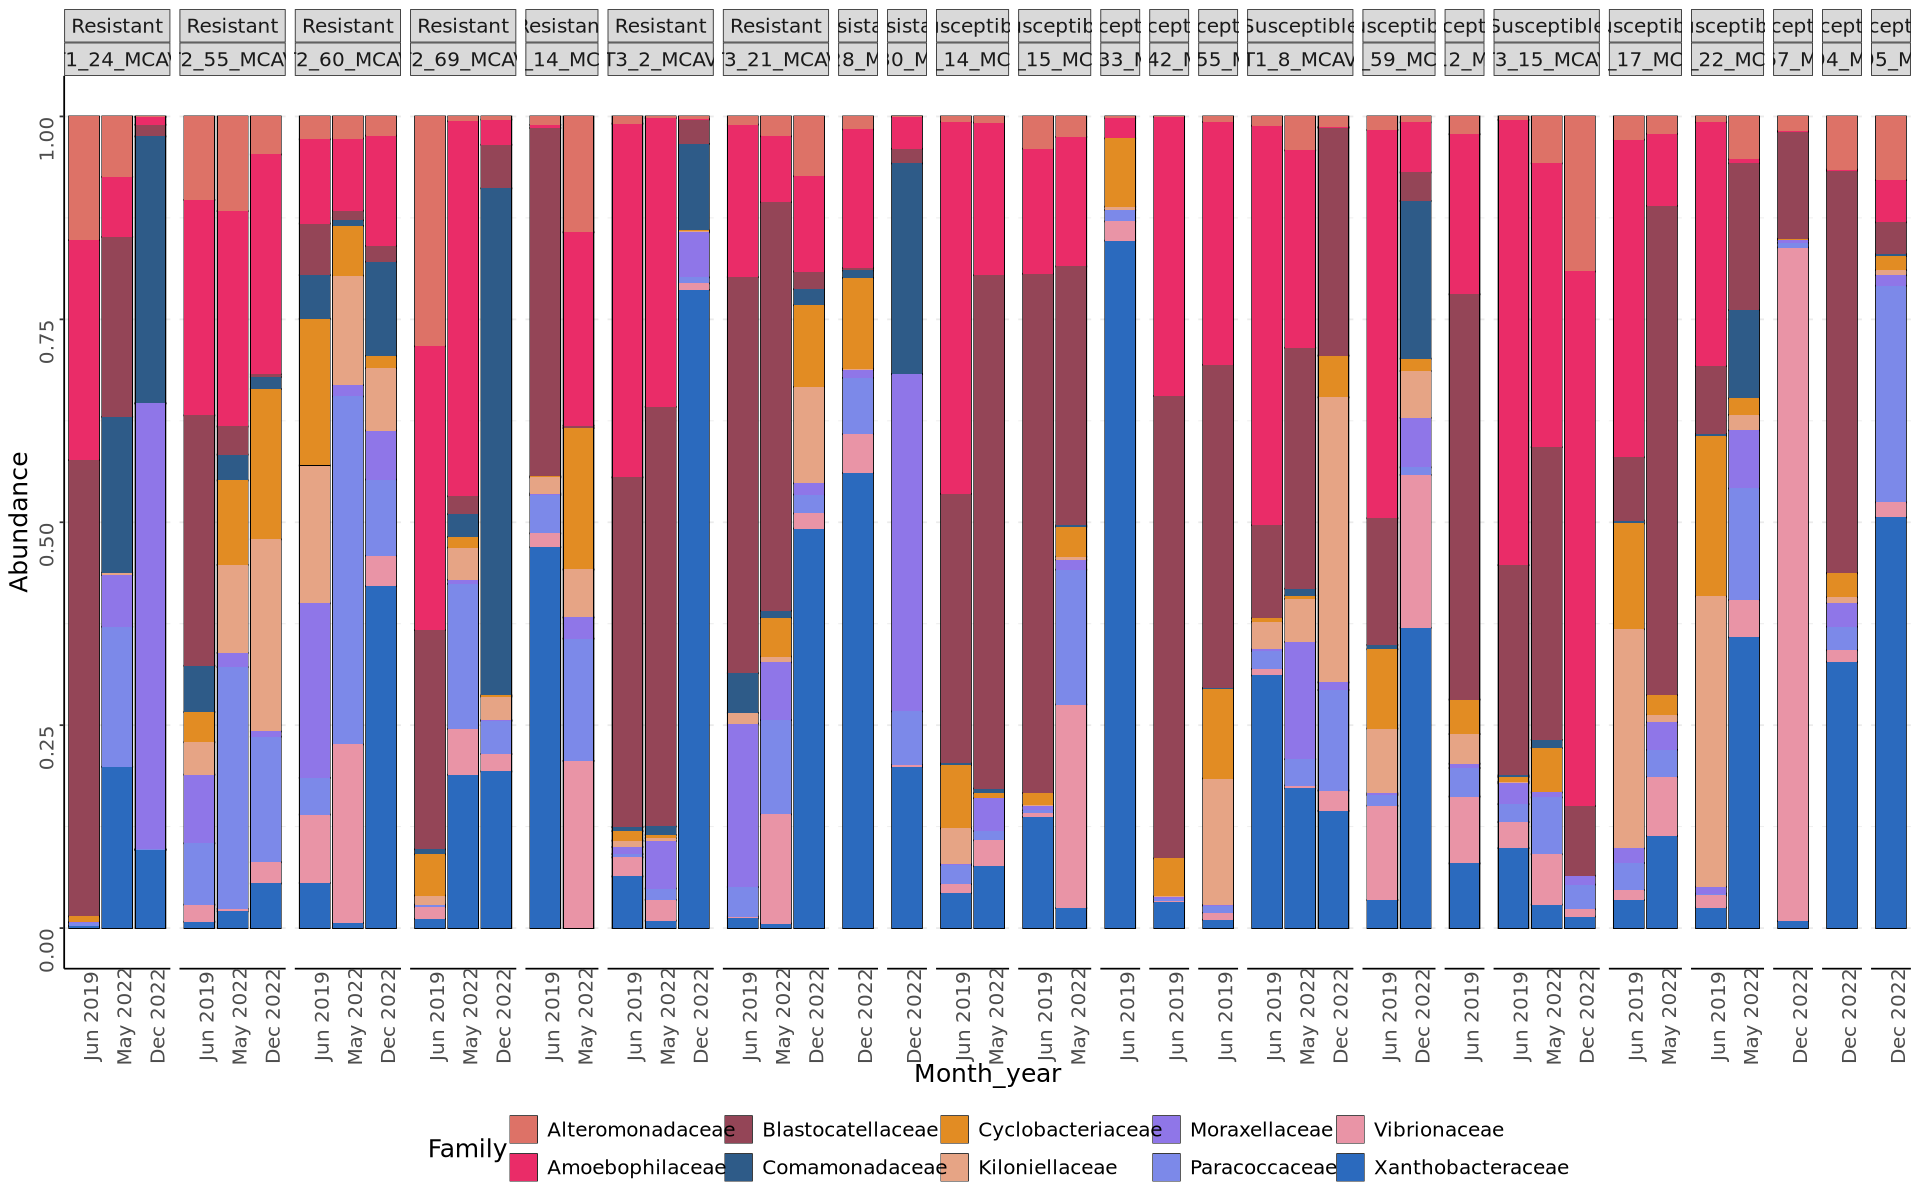

In [69]:
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(mcav_10_norm,x = "Month_year",fill='Family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = Month_year,fill=Family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 10 OTUs (Family)

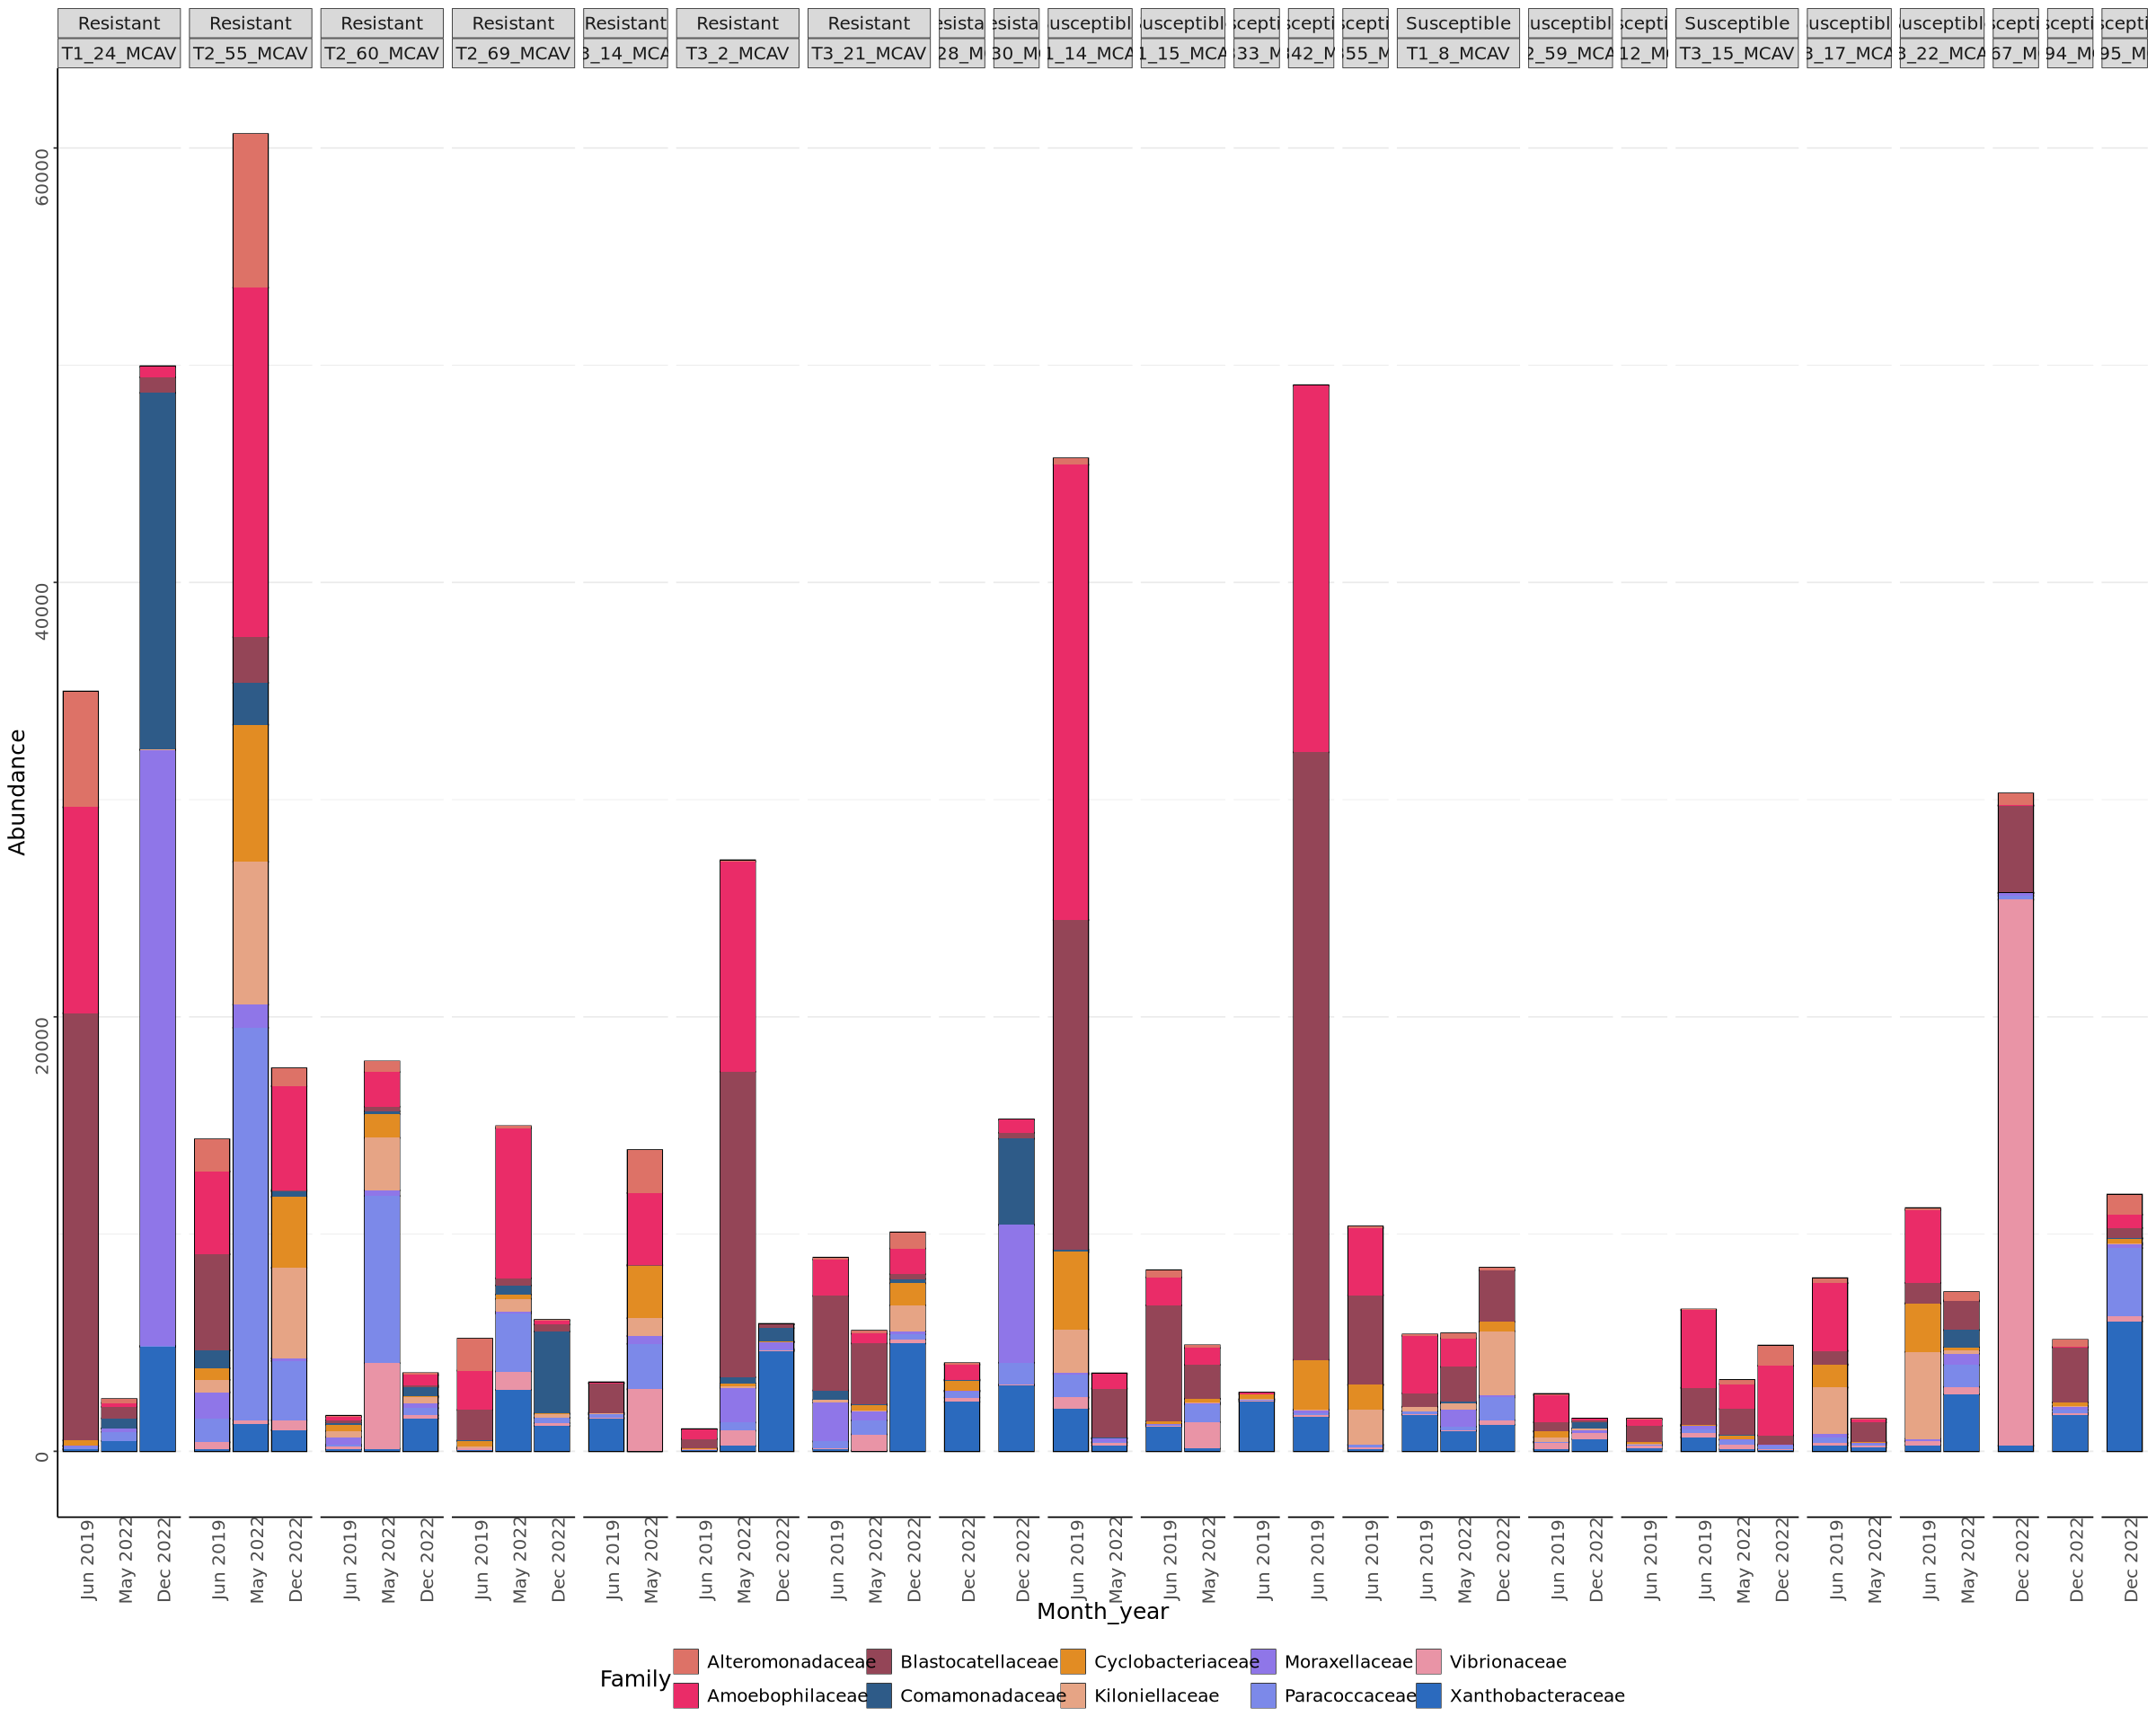

In [70]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(mcav_10,x = "Month_year",fill='Family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = Month_year,fill=Family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# abundances - top 10 Family 

#### PSTR --------------------------------------------------------------------------------

In [71]:
options(repr.plot.height = 13, repr.plot.width = 18)

In [72]:
# looking just at PSTR, remove disease margin

subset_PSTR<- subset_samples(ps, (Species == "PSTR" & Health_status != "Diseased_Margin"))
# and remove newly tagged colonies in 2022 
# dec_tags<-c('12/03/22','12/05/22')
# subset_PSTR<- subset_samples(subset_PSTR, (!(Date_InitialTag %in% dec_tags)))

In [73]:
PSTR_fam <- tax_glom(subset_PSTR, taxrank = "Family", NArm = FALSE)
PSTR_fam_norm <- transform_sample_counts(PSTR_fam, function(x) x / sum(x))
                                          
# filter for top families and normalize within each subsetted PS object
top100_names <- names(sort(taxa_sums(PSTR_fam), decreasing = TRUE)[1:100])
PSTR_100 <- prune_taxa(top100_names, PSTR_fam)
PSTR_100_norm <- transform_sample_counts(PSTR_100, function(x) x / sum(x))
                                          
top50_names <- names(sort(taxa_sums(PSTR_fam), decreasing = TRUE)[1:50])
PSTR_50 <- prune_taxa(top50_names, PSTR_fam)
PSTR_50_norm <- transform_sample_counts(PSTR_50, function(x) x / sum(x))

top30_names <- names(sort(taxa_sums(PSTR_fam), decreasing = TRUE)[1:30])
PSTR_30 <- prune_taxa(top30_names, PSTR_fam)
PSTR_30_norm <-  transform_sample_counts(PSTR_30, function(x) x / sum(x))

top10_names <- names(sort(taxa_sums(PSTR_fam), decreasing = TRUE)[1:10])
PSTR_10 <- prune_taxa(top10_names, PSTR_fam)
PSTR_10_norm <- transform_sample_counts(PSTR_10, function(x) x / sum(x))

In [74]:
df_meta <- data.frame(sample_data(subset_PSTR))

# 2. Re-level Sample IDs based on Month_year order
df_meta <- df_meta %>% 
  arrange(colony_id,Month_year) %>% 
  mutate(sampleid = factor(sampleid, levels = unique(sampleid)))

# 3. Update sample_data in your phyloseq object
sample_data(subset_PSTR) <- sample_data(df_meta)

In [75]:
# reorder colonies
PSTR_g_S<-subset_samples(subset_PSTR, RS == "Susceptible")
df_meta<-data.frame(sample_data(PSTR_g_S))
# make order for X122022_Condition
df_meta <- df_meta %>% 
    mutate(X122022_Condition = factor(X122022_Condition, levels = c('Healthy','Diseased','Dead','Not_Visited'))) %>%
    arrange(colony_id, X122022_Condition)
# reorder colonies by condition factor levels
col_order <- df_meta %>%
  distinct(colony_id, X122022_Condition) %>%
  arrange(X122022_Condition, colony_id) %>%
  pull(colony_id)

sample_data(PSTR_g_S)$colony_id <-
  factor(sample_data(PSTR_g_S)$colony_id, levels = col_order)

In [76]:
getwd()

[1] "/project/pi_sarah_gignouxwolfsohn_uml_edu/brooke/CBC_metagenomics/all_sctld"

In [77]:
# add new taxa to colors list (to keep the rest consistent)
top100pstr_fam<-as.character(tax_table(PSTR_100_norm)[, "Family"])
missing_fam <- setdiff(top100pstr_fam, names(colors))
missing_fam

[1] "Marinobacteraceae"   "Rubritaleaceae"      "Thiohalorhabdaceae" 
 [4] "Kordiimonadaceae"    "Marinomonadaceae"    "Balneolaceae"       
 [7] "Flammeovirgaceae"    "Desulfovibrionaceae" "Myxococcaceae"      
[10] "Oleiphilaceae"       "Phormidesmiaceae"    "Reyranellaceae"     
[13] "Thermotaleaceae"     "Marinilabiliaceae"   "Fusibacteraceae"    
[16] "Arenicellaceae"      "Nannocystaceae"      "Arcobacteraceae"    
[19] "Desulfobacteraceae"  "Micavibrionaceae"    "SM2D12"

In [82]:
# add more colors
colors_30 <- c( "#e28d99", "#ee7473", "#f2703f", "#dc966f", "#de9435", "#d6b36e", "#dbbf37", "#abb160", "#bdd630", "#bade6b", "#7ead3b", "#bcdc9c", "#66d34d", "#65d77c", "#66af7a", "#5ae5ac", "#77e3c6", "#47b1a5", "#5ae4e5", "#41aec3", "#5eceed", "#3ba1d2", "#78b0e7", "#7796ed", "#b5a5dd", "#aa7df5", "#c891e3", "#e66dd5", "#de95c9", "#f2699f" )
colors<-append(colors, colors_30)

In [88]:
# index last named color in the list 
last_named_pos <- length(names(colors)[names(colors) != "" & !is.na(names(colors))])
target_slots <- (last_named_pos + 1):(last_named_pos + length(missing_fam))
# add new colors to existing colors list
names(colors)[target_slots] <- missing_fam

In [91]:
# append missing family to 16S top family list
# top100family_16S<-append(top100family_16S, missing_fam)
# # export list to add to colors list in metagenomics plots
# saveRDS(top100family_16S, file = "top100family_16S.rds")
# just export existing colors list
saveRDS(colors, file = "family16s_colors.rds")

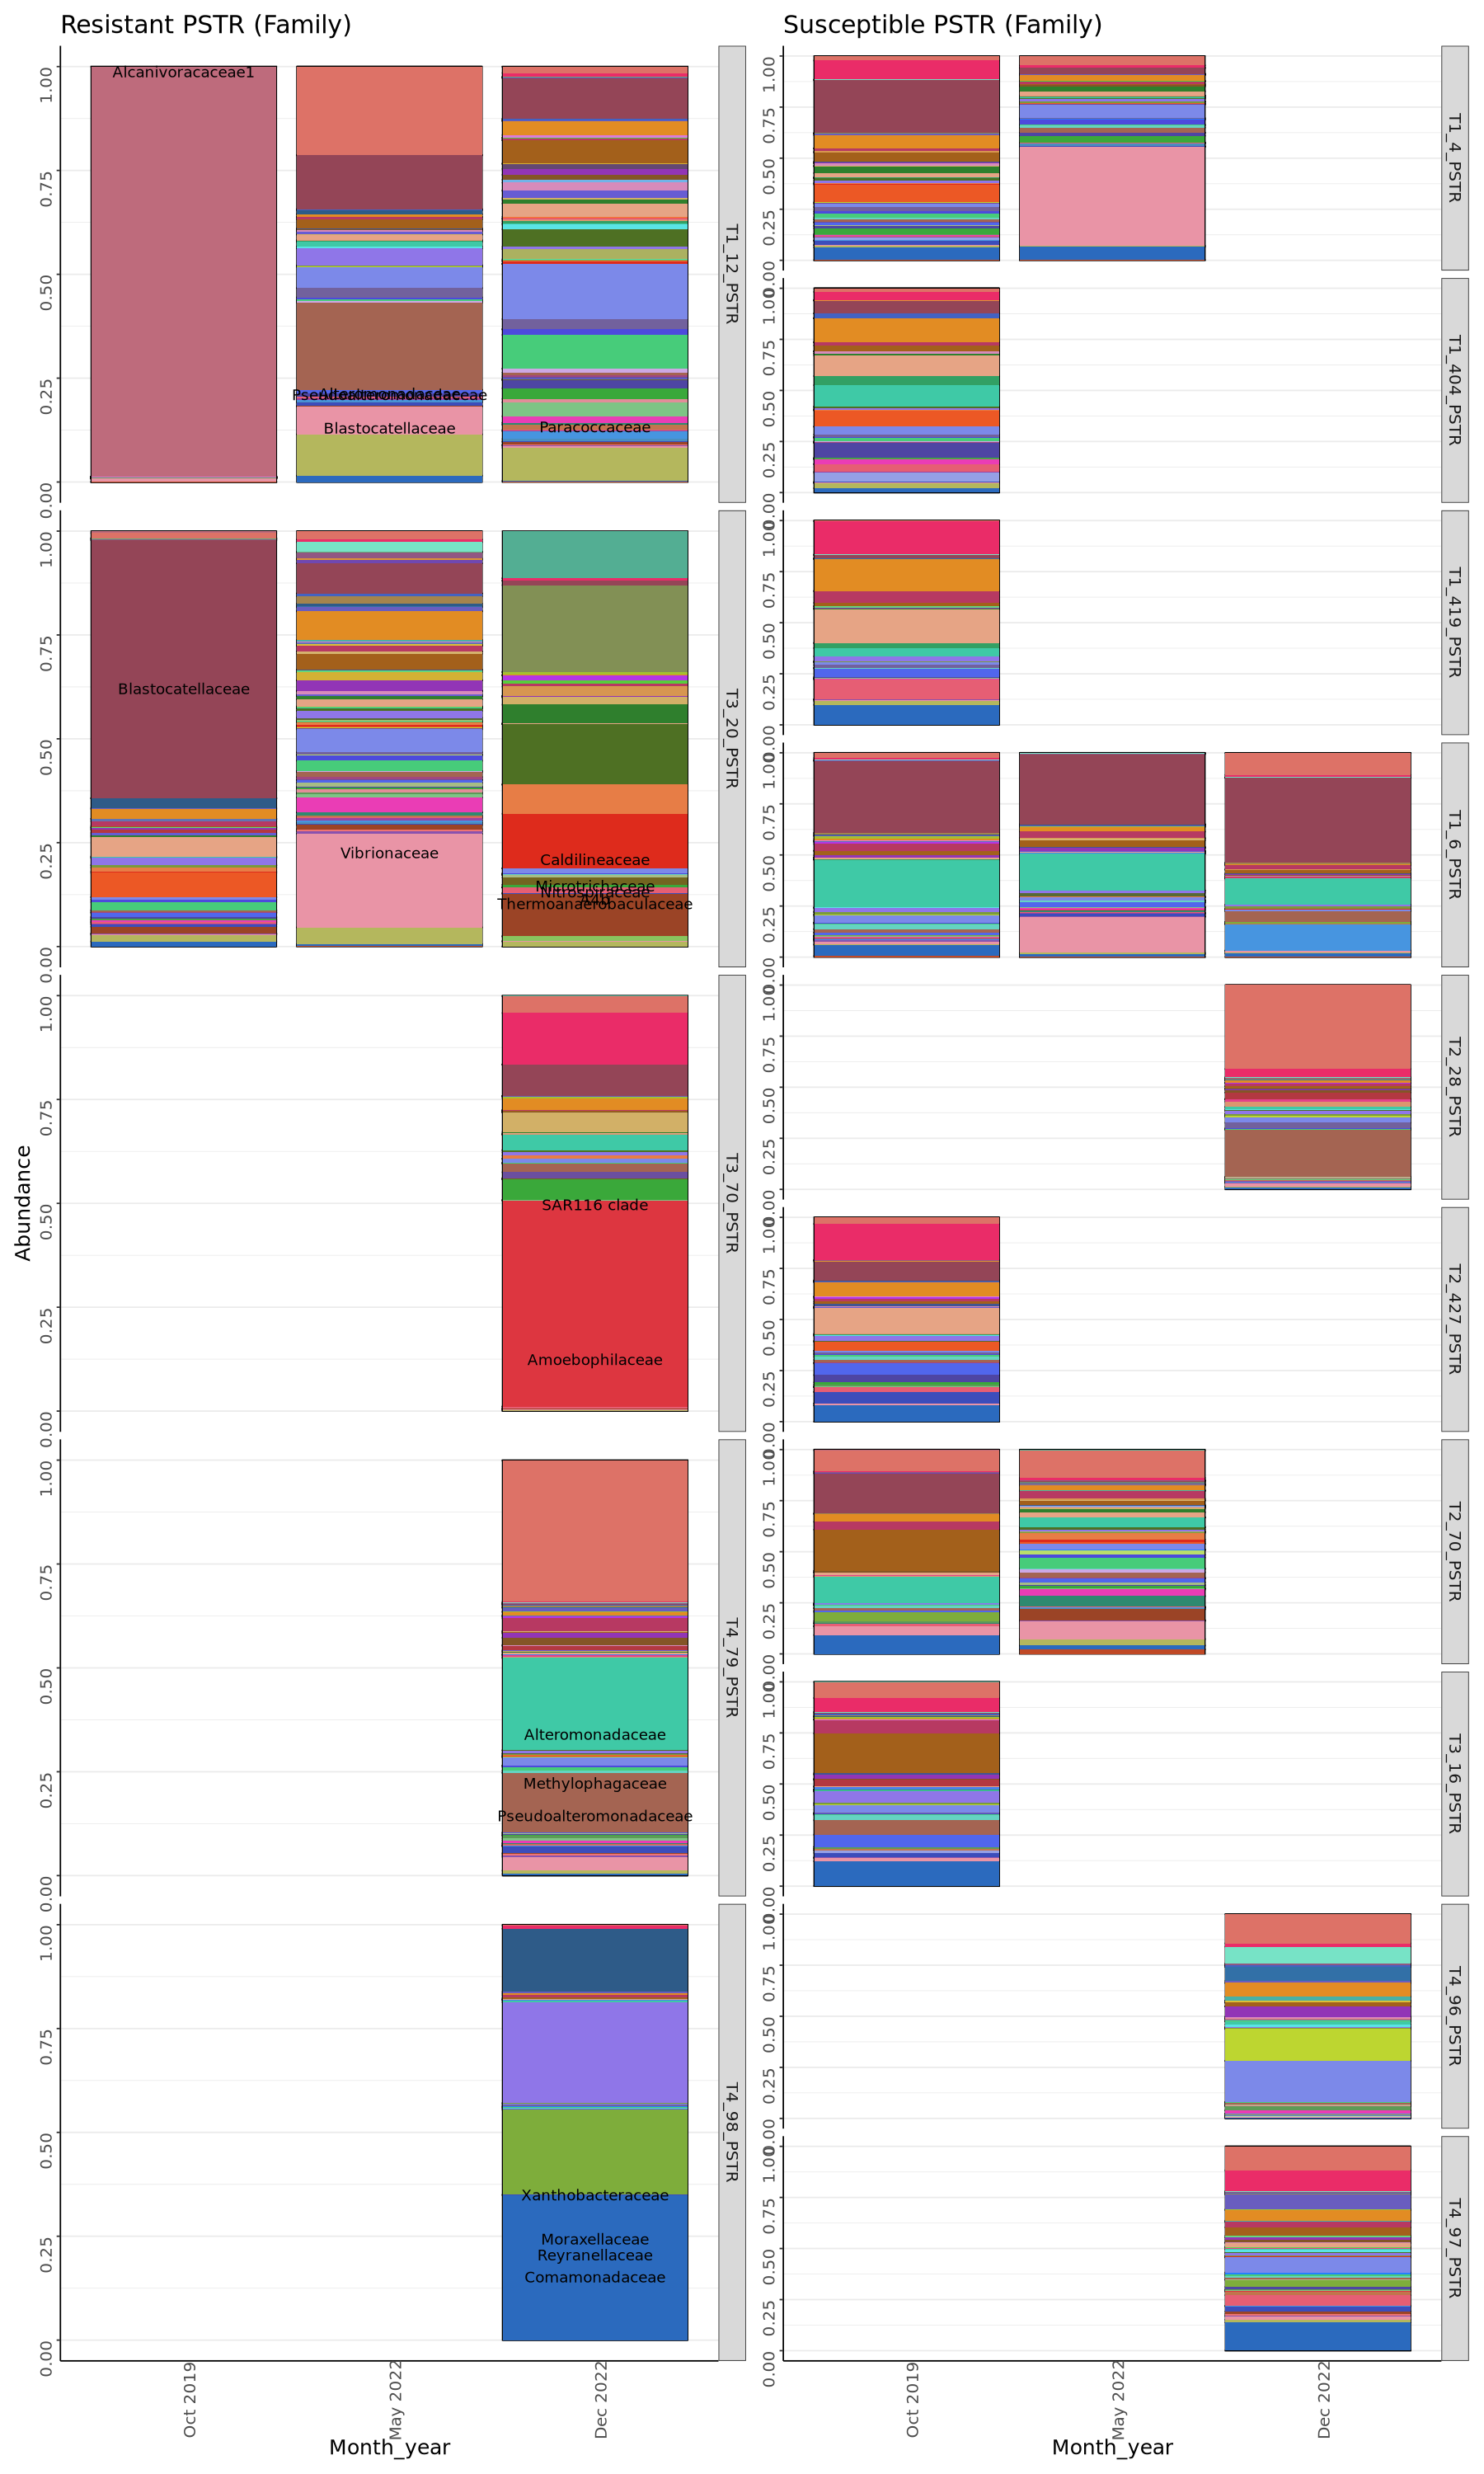

In [92]:
options(repr.plot.height = 25, repr.plot.width = 15)
p_R <- plot_bar(subset_samples(PSTR_100_norm, RS == "Resistant"),x = "Month_year", fill = "Family")+
    facet_grid(colony_id ~ .)+
    geom_bar(aes(x = Month_year,fill=Family), stat="identity",position="stack")+
    geom_text(aes(label = ifelse(Abundance > 0.10, as.character(Family), "")))+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position = "none",panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))+
    labs(title = "Resistant PSTR (Family)")
p_S <- plot_bar(subset_samples(PSTR_100_norm, RS == "Susceptible"),x = "Month_year", fill = "Family") +
    facet_grid(colony_id ~ .)+
    geom_bar(aes(x = Month_year,fill=Family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position = "none",panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))+
    labs(title = "Susceptible PSTR (Family)", y = NULL)
p_R | p_S +
  plot_layout(guides = "collect") +
  theme(legend.position = "none")
# top 100 Family

In [93]:
# again need to sort

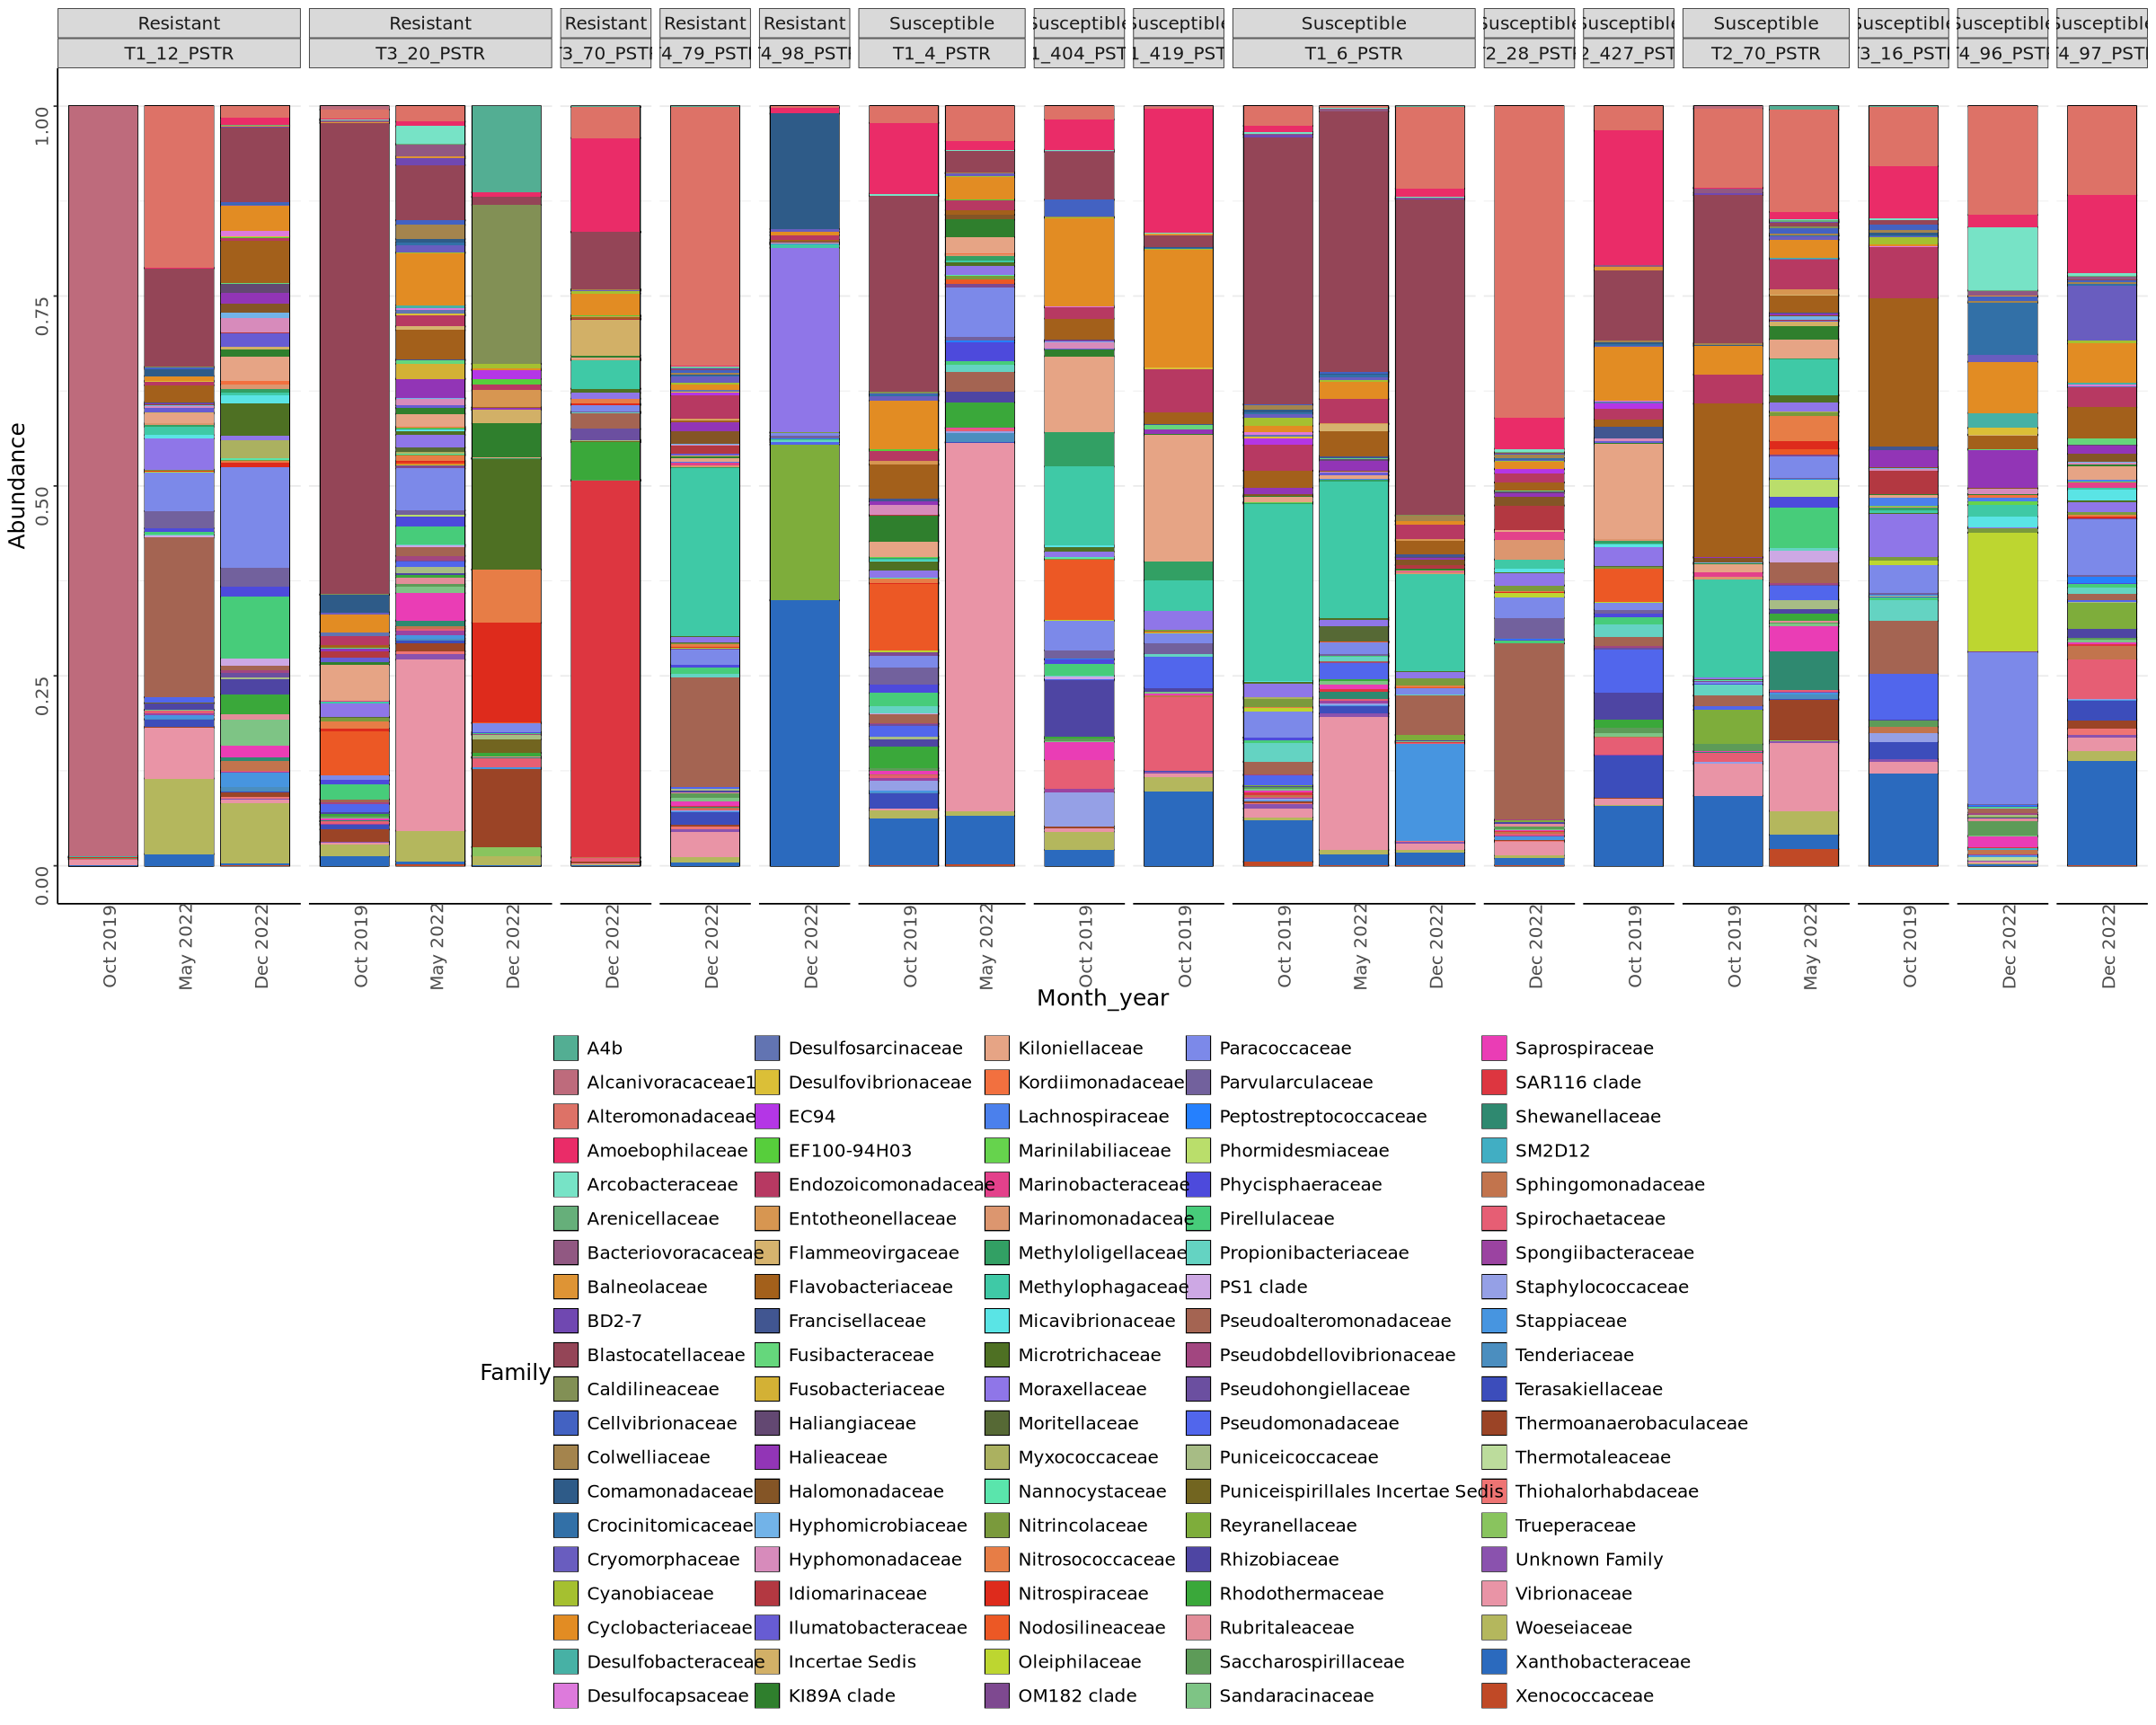

In [94]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(PSTR_100_norm,x = "Month_year",fill='Family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = Month_year,fill=Family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 100 OTUs (Family)

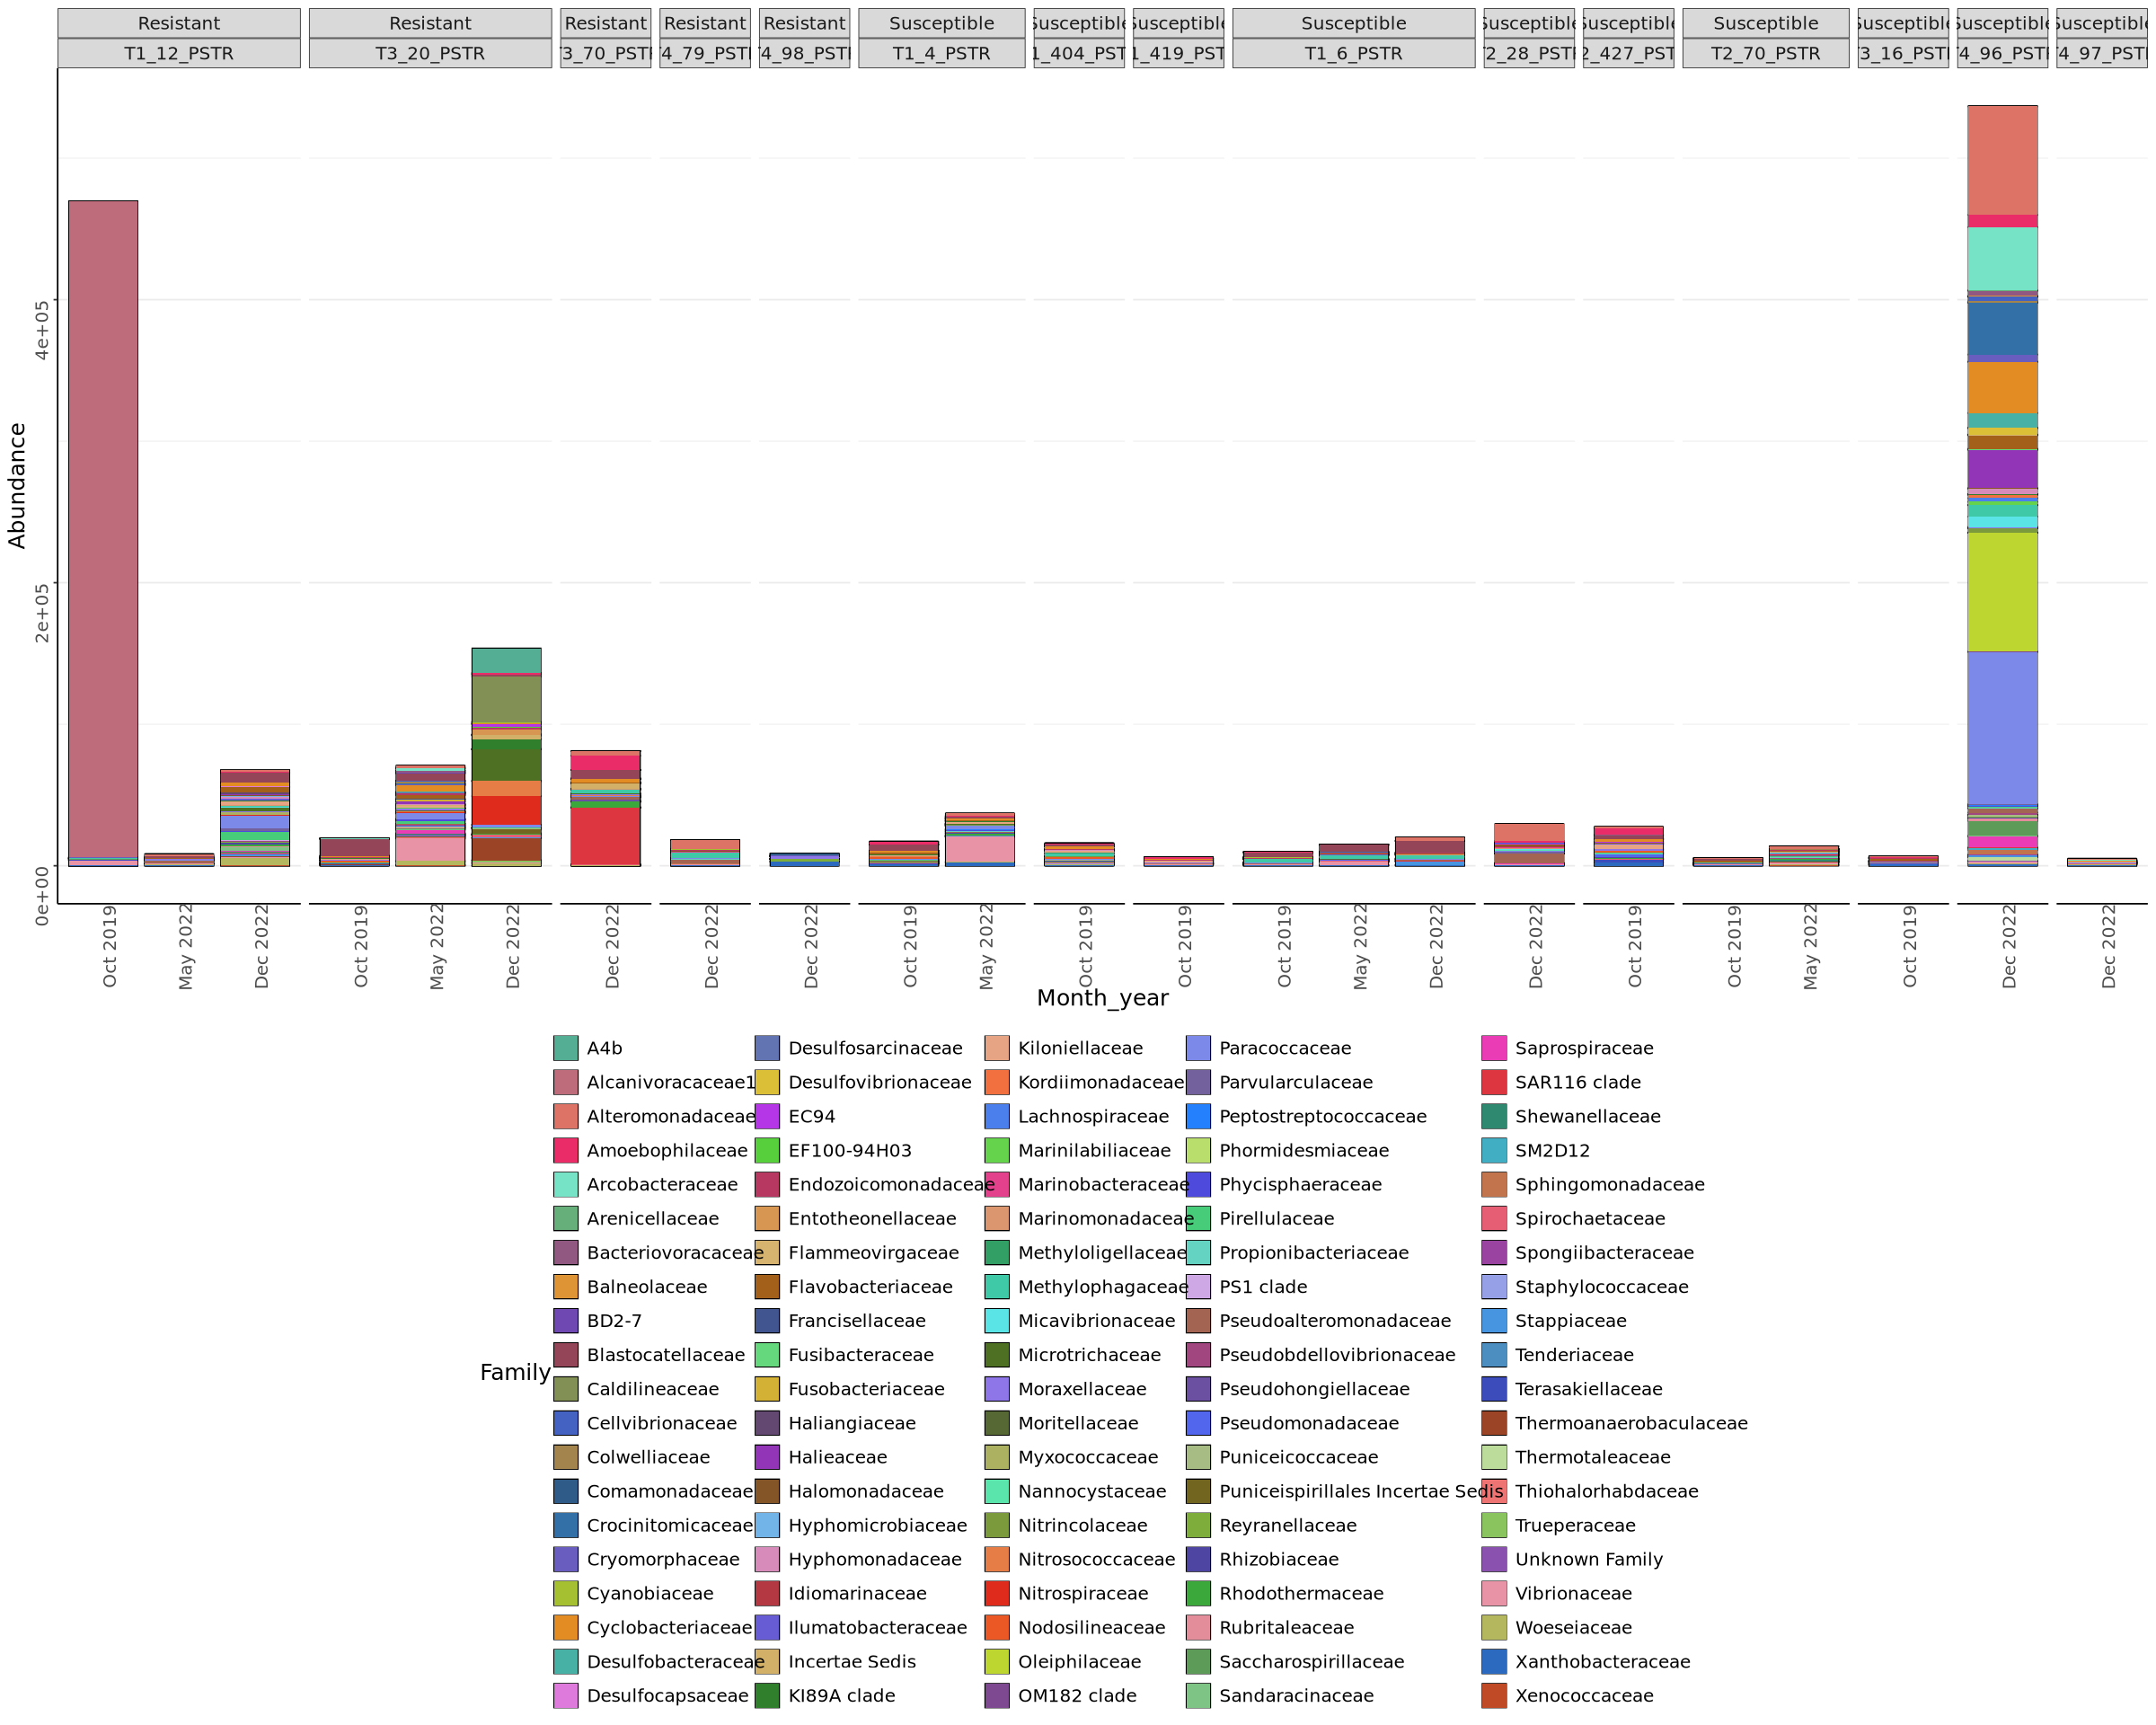

In [95]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(PSTR_100,x = "Month_year",fill='Family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = Month_year,fill=Family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# abundances - top 100 OTUs (Family)

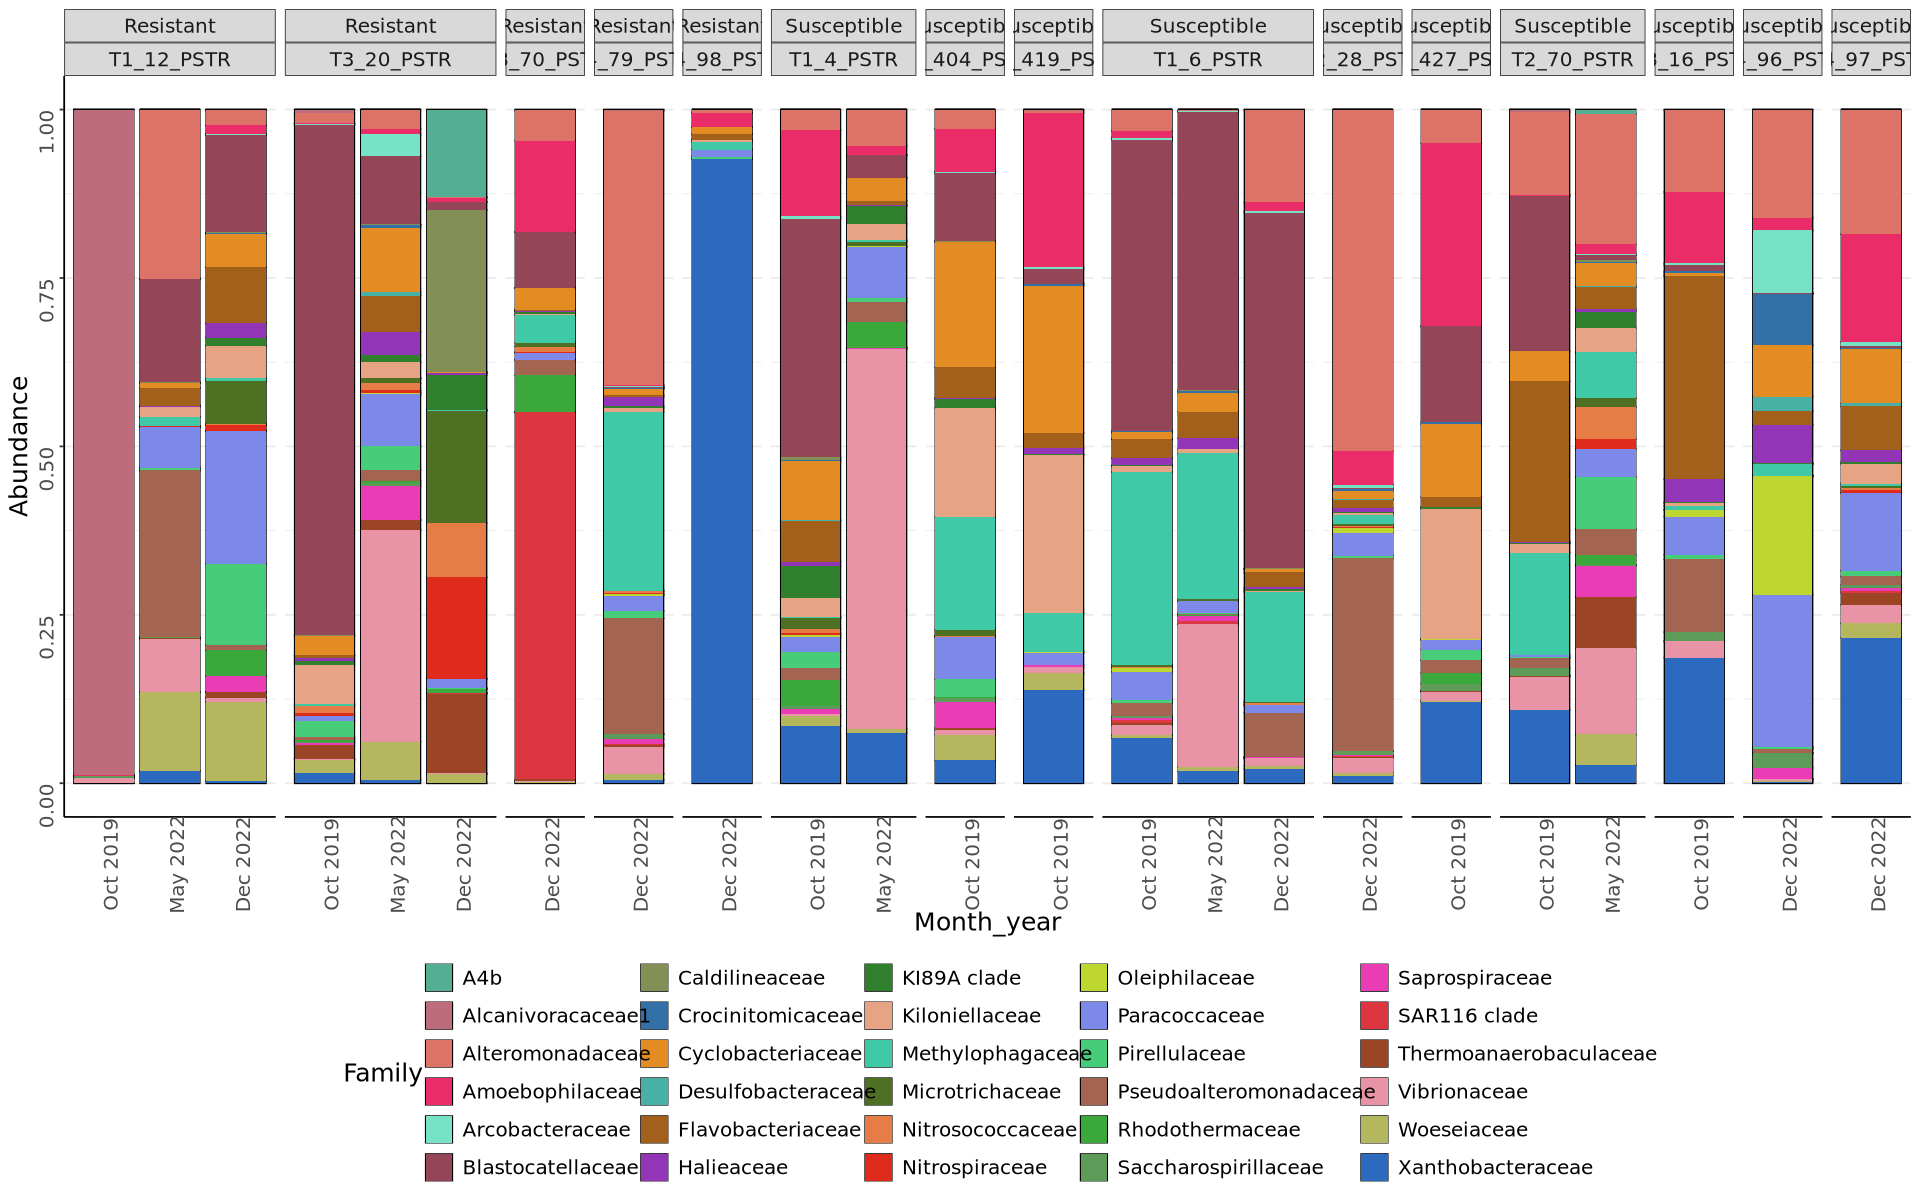

In [96]:
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(PSTR_30_norm,x = "Month_year",fill='Family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = Month_year,fill=Family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 30 Family - R vs S. individuals over time 

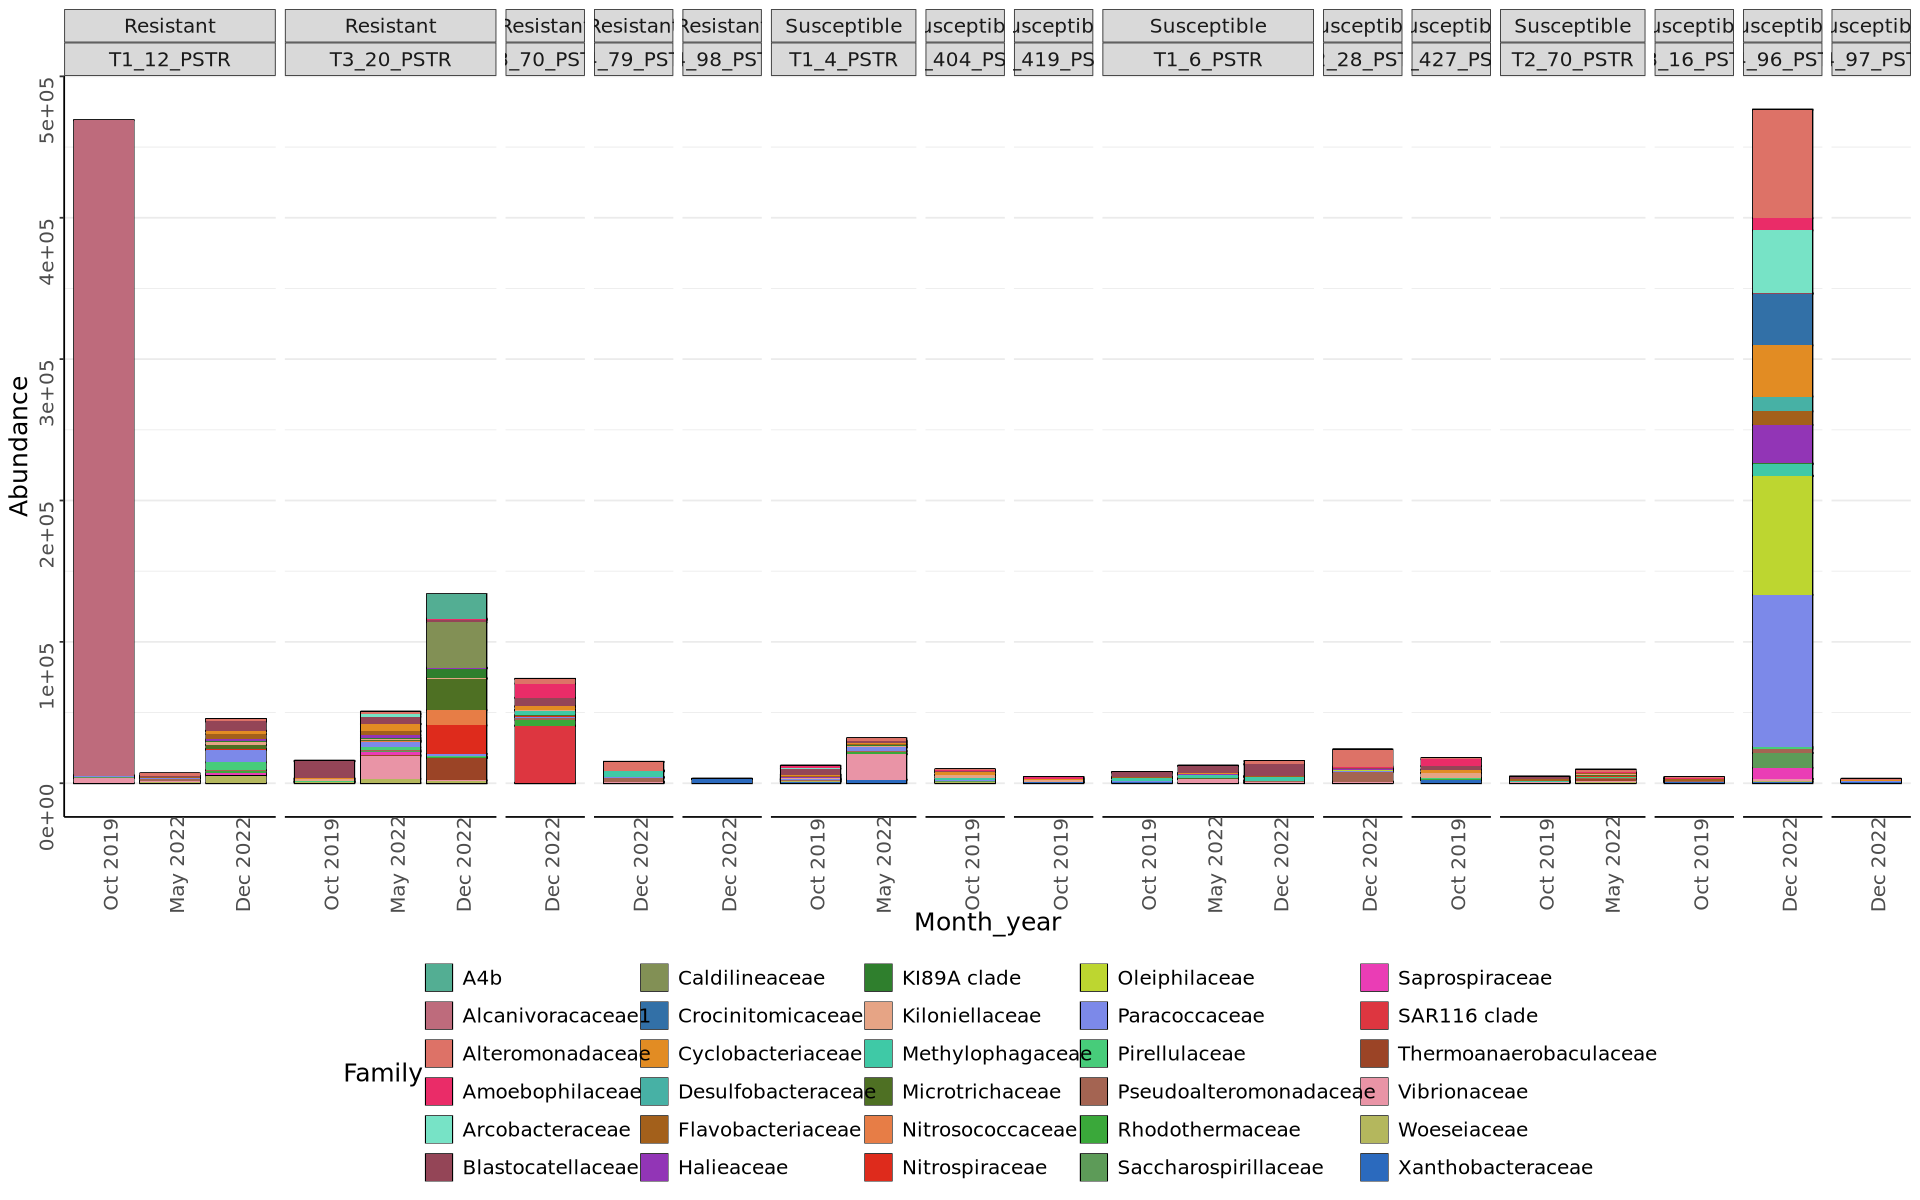

In [97]:
p<-plot_bar(PSTR_30,x = "Month_year",fill='Family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = Month_year,fill=Family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# abundances - top 30 OTUs (Family)

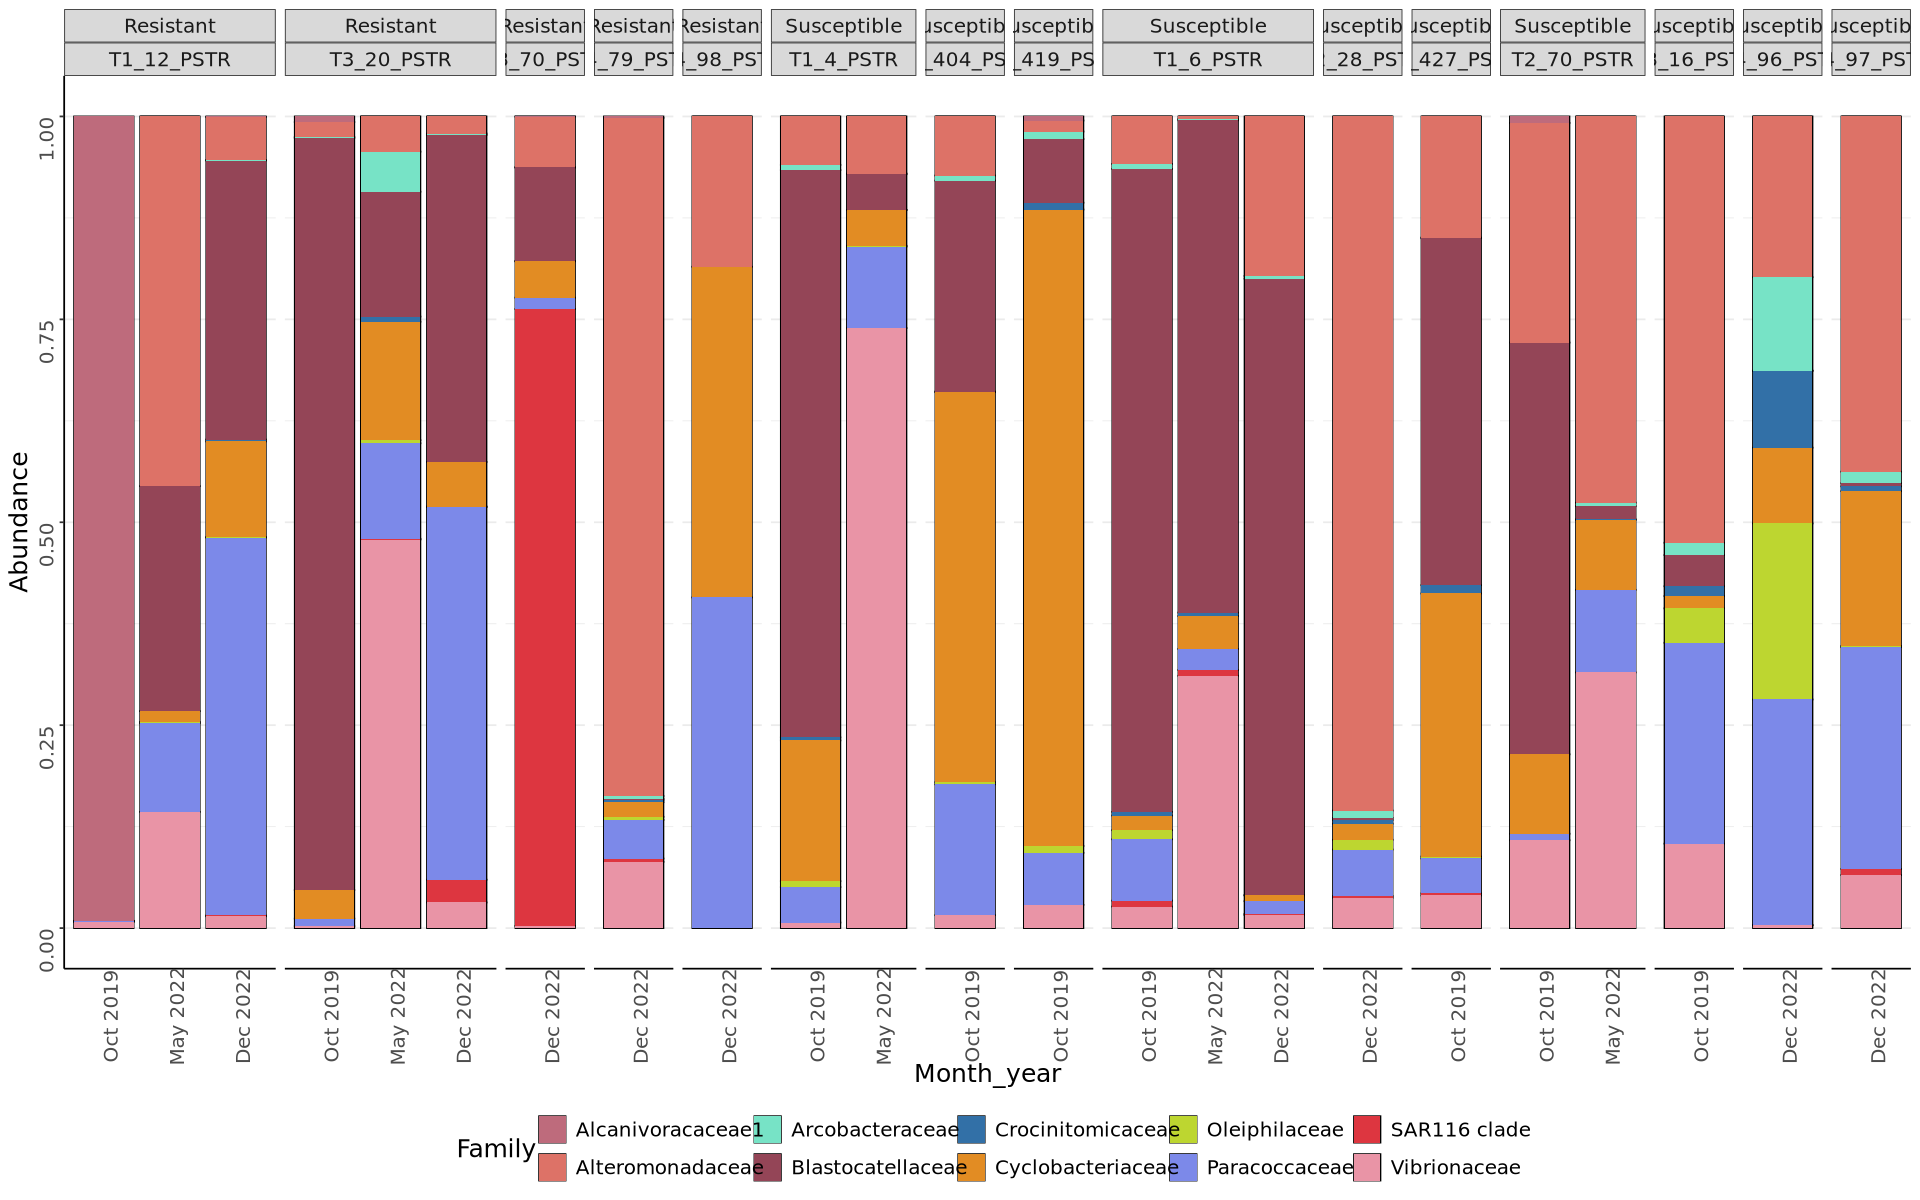

In [98]:
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(PSTR_10_norm,x = "Month_year",fill='Family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = Month_year,fill=Family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 10 OTUs (Family)

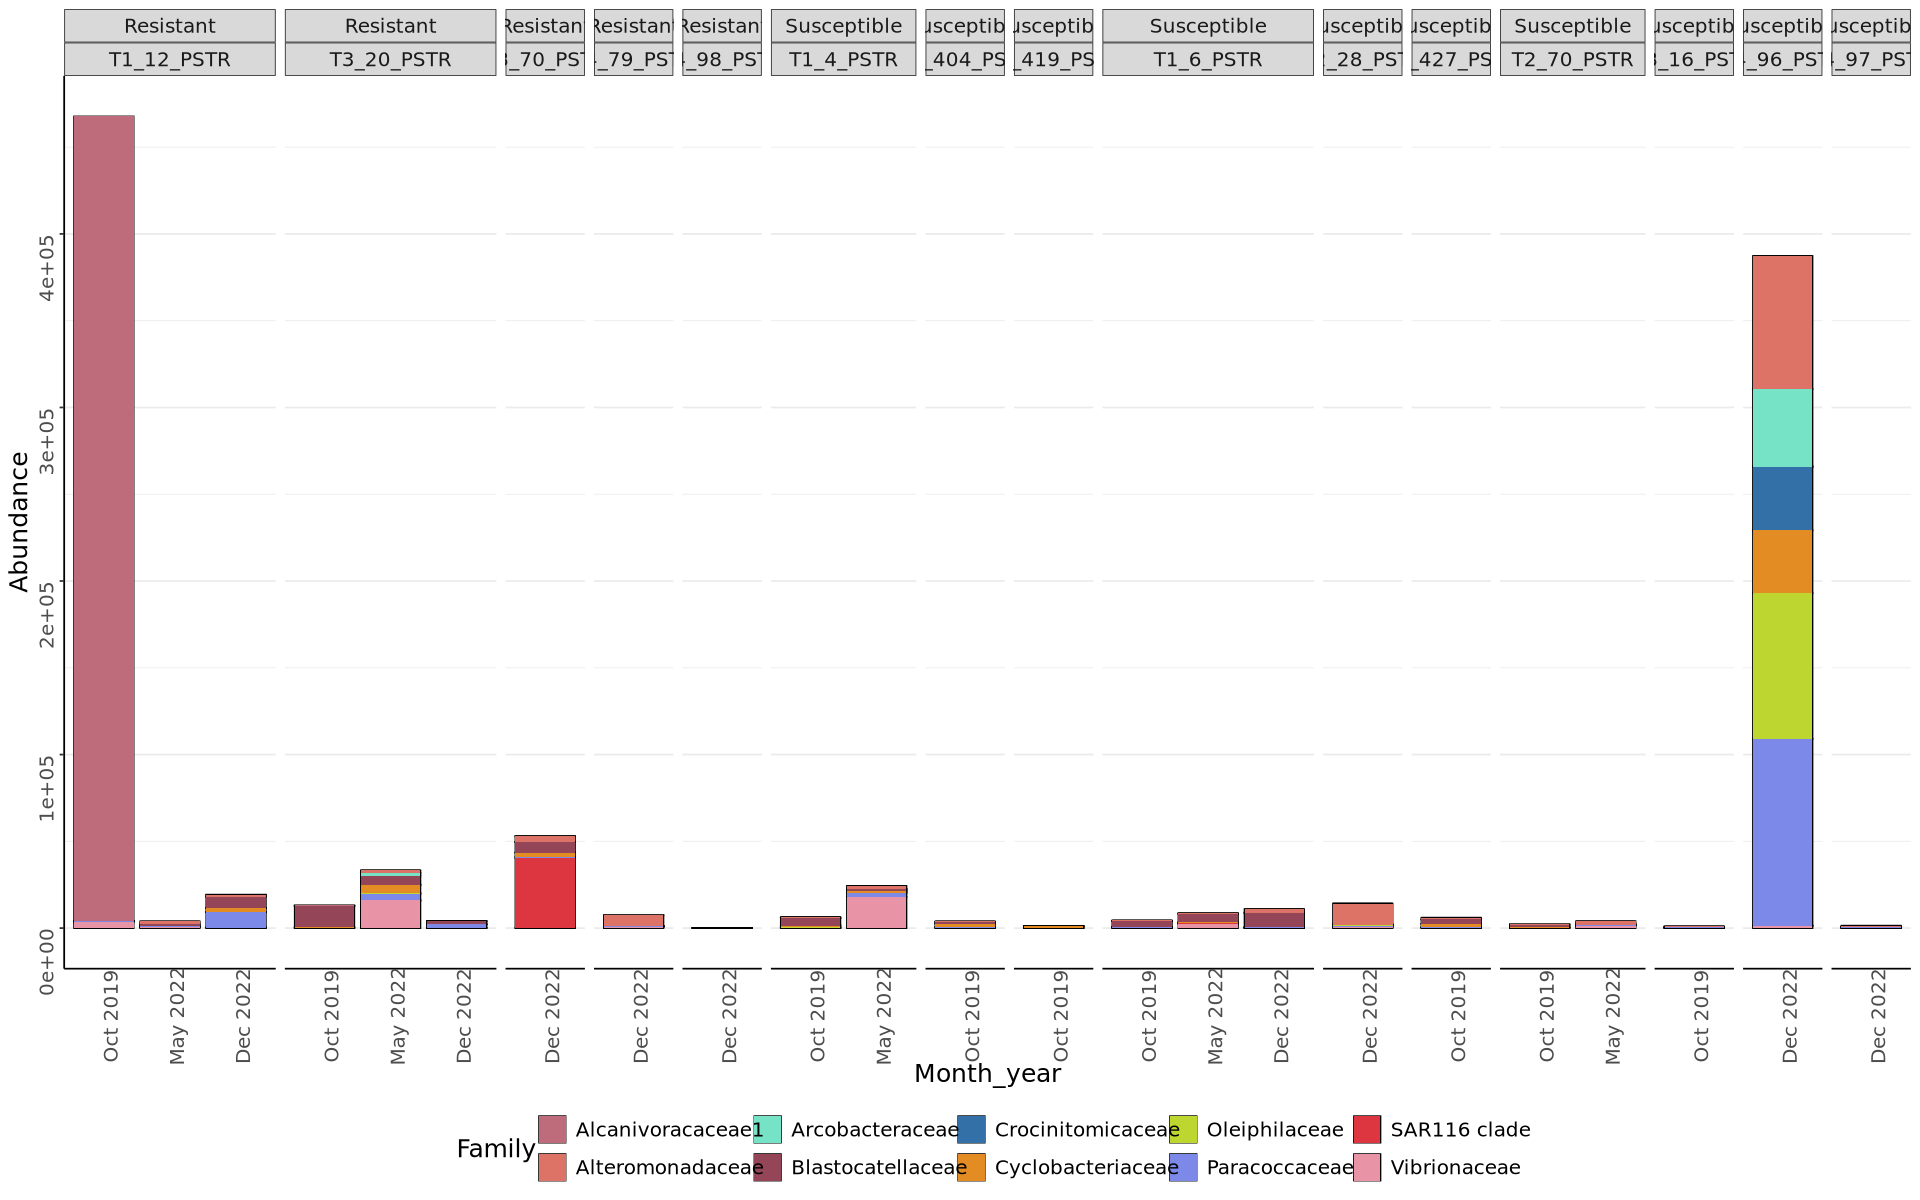

In [99]:
p<-plot_bar(PSTR_10,x = "Month_year",fill='Family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = Month_year,fill=Family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# abundances - top 10 OTUs (Family)

#### PAST --------------------------------------------------------------------------------

In [100]:
options(repr.plot.height = 13, repr.plot.width = 18)

In [101]:
# looking just at PAST, remove disease margin
subset_PAST<- subset_samples(ps, (Species == "PAST" & Health_status != "Diseased_Margin"))
# and remove newly tagged colonies in 2022 
# dec_tags<-c('12/03/22','12/05/22')
# subset_PAST<- subset_samples(subset_PAST, (!(Date_InitialTag %in% dec_tags)))

In [102]:
past_fam <- tax_glom(subset_PAST, taxrank = "Family", NArm = FALSE)
past_fam_norm <- transform_sample_counts(past_fam, function(x) x / sum(x))
                                          
# filter for top families and normalize within each subsetted PS object
top100_names <- names(sort(taxa_sums(past_fam), decreasing = TRUE)[1:100])
past_100_2019 <- prune_taxa(top100_names, past_fam)
past_100_2019_norm <- transform_sample_counts(past_100_2019, function(x) x / sum(x))
                                          
top50_names <- names(sort(taxa_sums(past_fam), decreasing = TRUE)[1:50])
past_50_2019 <- prune_taxa(top50_names, past_fam)
past_50_2019_norm <- transform_sample_counts(past_50_2019, function(x) x / sum(x))

top30_names <- names(sort(taxa_sums(past_fam), decreasing = TRUE)[1:30])
past_30_2019 <- prune_taxa(top30_names, past_fam)
past_30_2019_norm <-  transform_sample_counts(past_30_2019, function(x) x / sum(x))

top10_names <- names(sort(taxa_sums(past_fam), decreasing = TRUE)[1:10])
past_10_2019 <- prune_taxa(top10_names, past_fam)
past_10_2019_norm <- transform_sample_counts(past_10_2019, function(x) x / sum(x))

In [103]:
df_meta <- data.frame(sample_data(subset_PAST))

# 2. Re-level Sample IDs based on Month_year order
df_meta <- df_meta %>% 
  arrange(colony_id,Month_year) %>% 
  mutate(sampleid = factor(sampleid, levels = unique(sampleid)))

# 3. Update sample_data in your phyloseq object
sample_data(subset_PAST) <- sample_data(df_meta)

In [104]:
# # "resistant" colonies that don't have 2022 data 
# df_meta %>%
#     filter(colony_id == "T2_47_PAST" | colony_id == "T3_13_PAST") %>%
#     select(colony_id, X122022_Condition, X092023_Condition)
# t3 13 was found again and sampled as healthy in 4/2024, looks like just missed the sample but we have healthy documented in 122022
# remove t2 47 - next sample in 6/2025 and I'm not convinced its the same colony 
# SUS T2 347 was Dead in 05/2022

# i dont think ccd has these colonirs in her subset

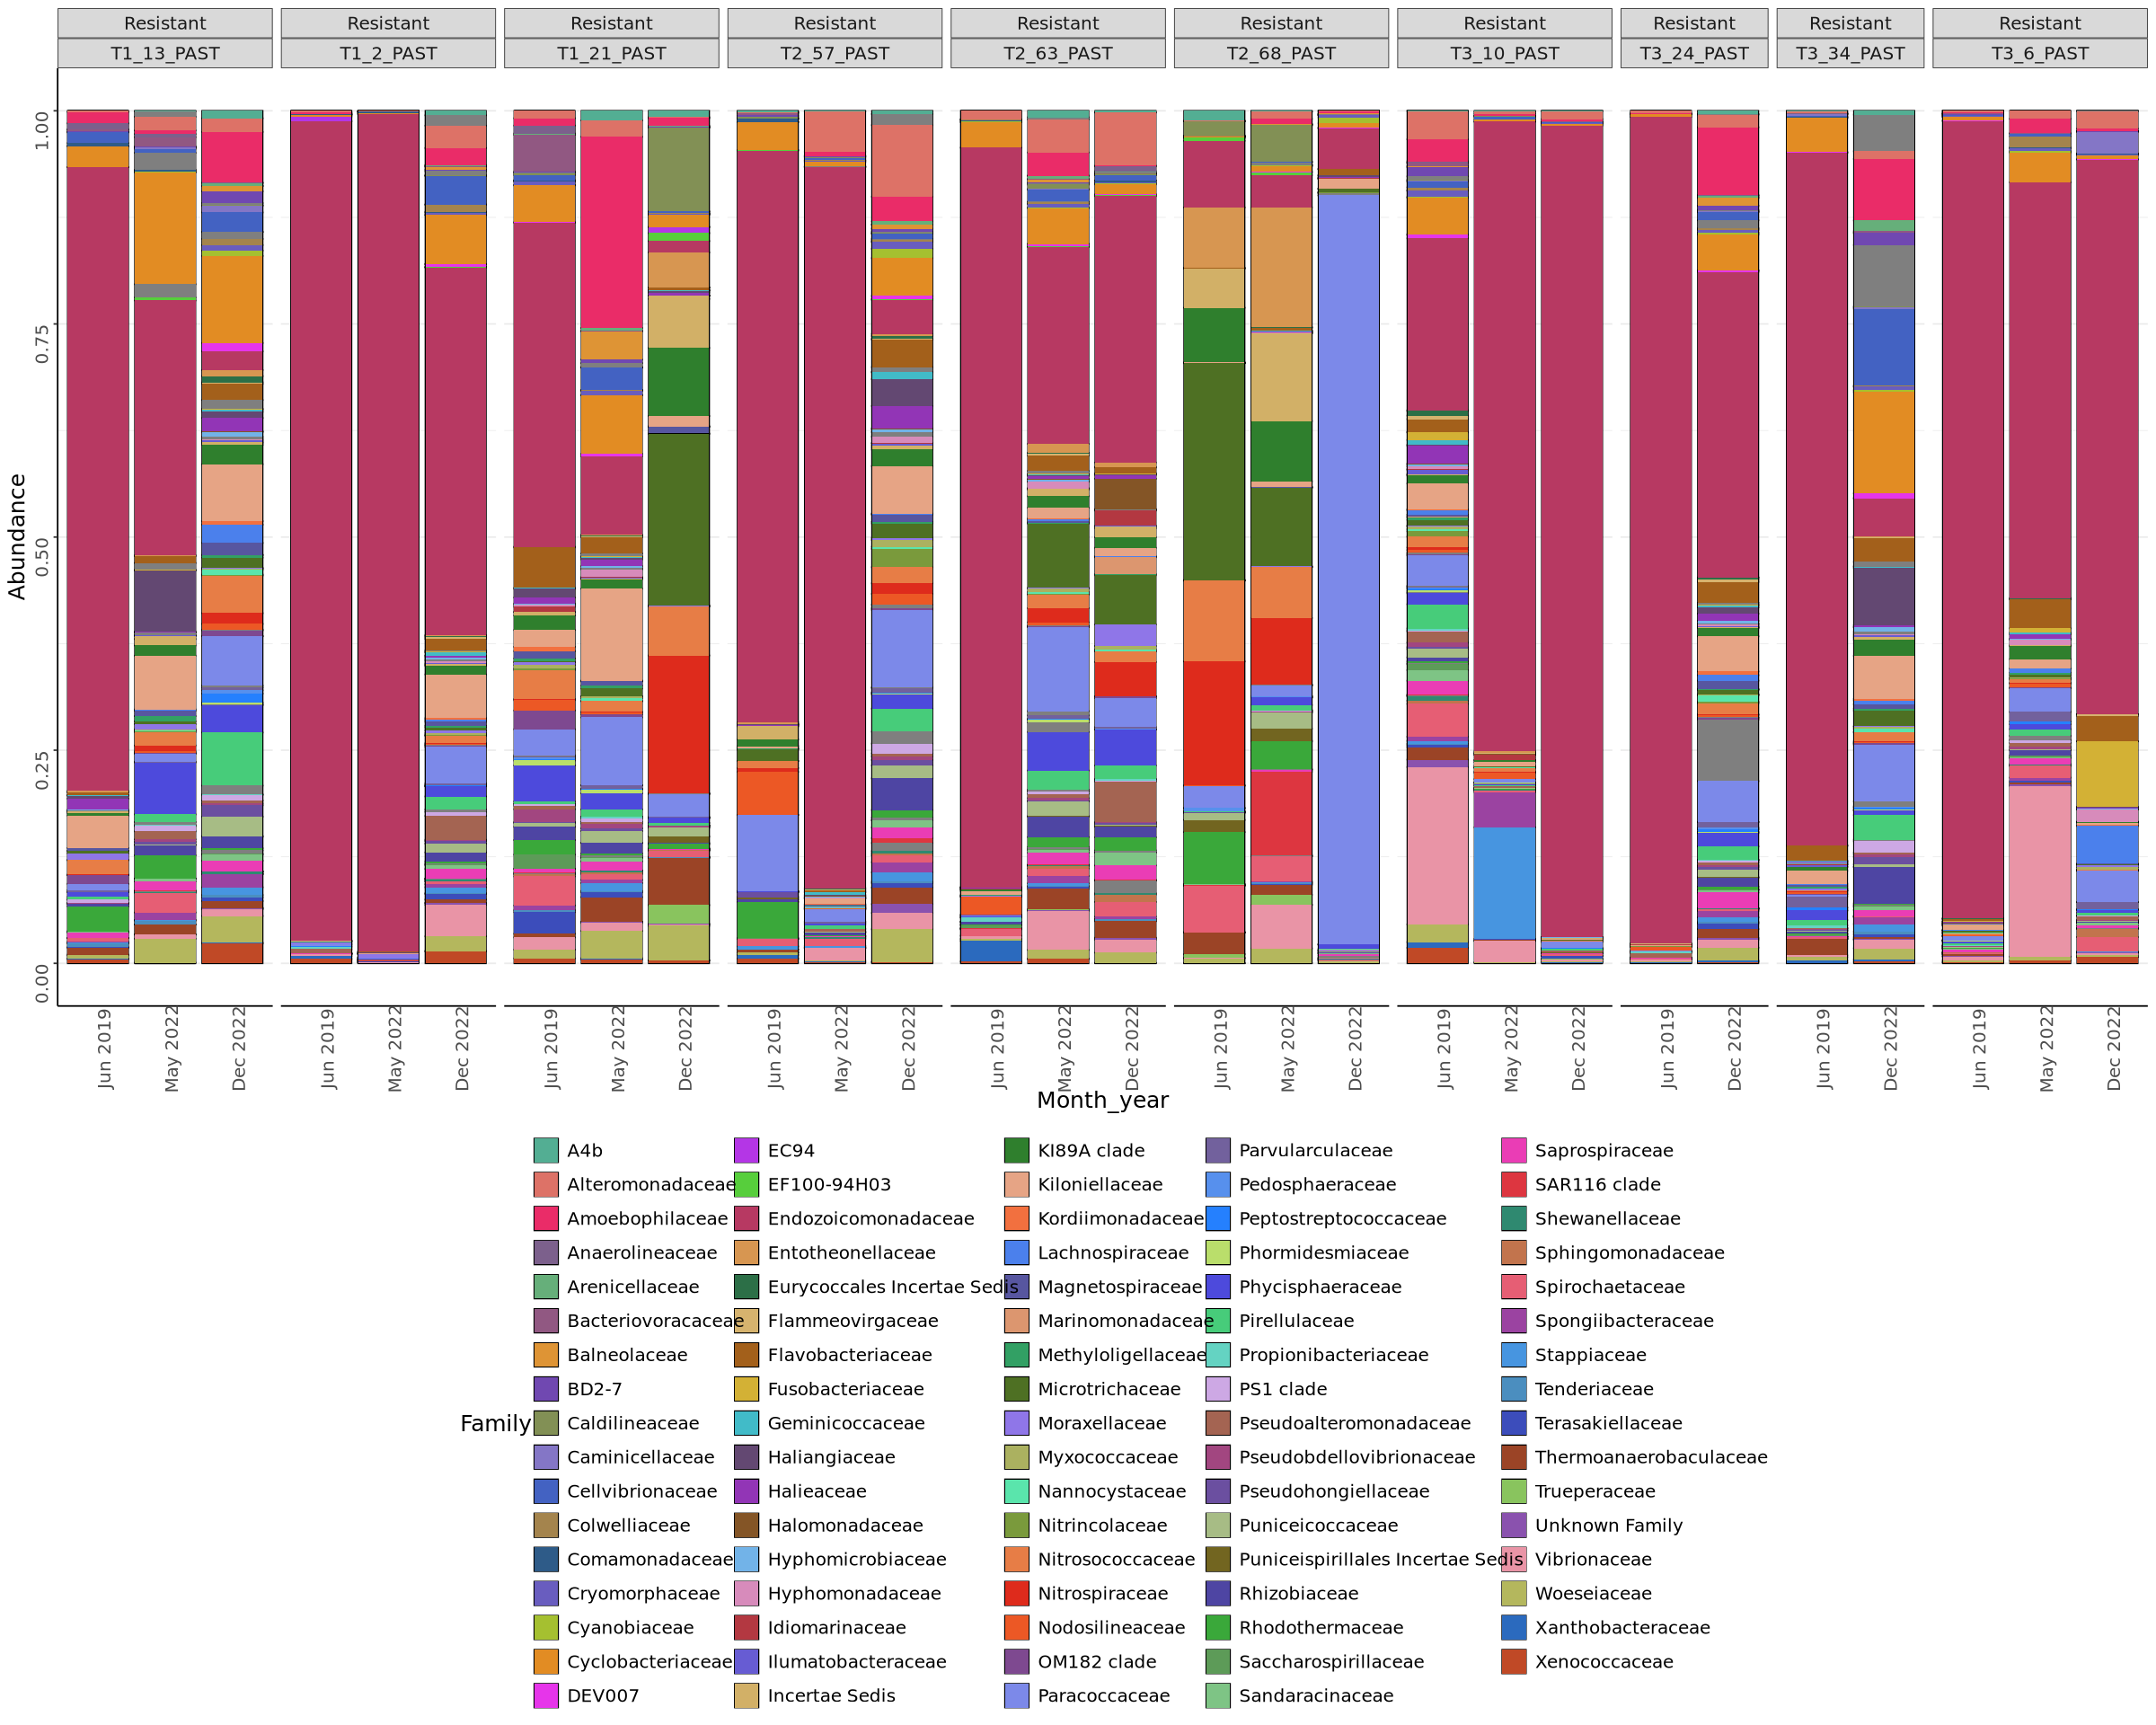

In [105]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(past_100_2019_norm,x = "Month_year",fill='Family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = Month_year,fill=Family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 100 OTUs (Family)

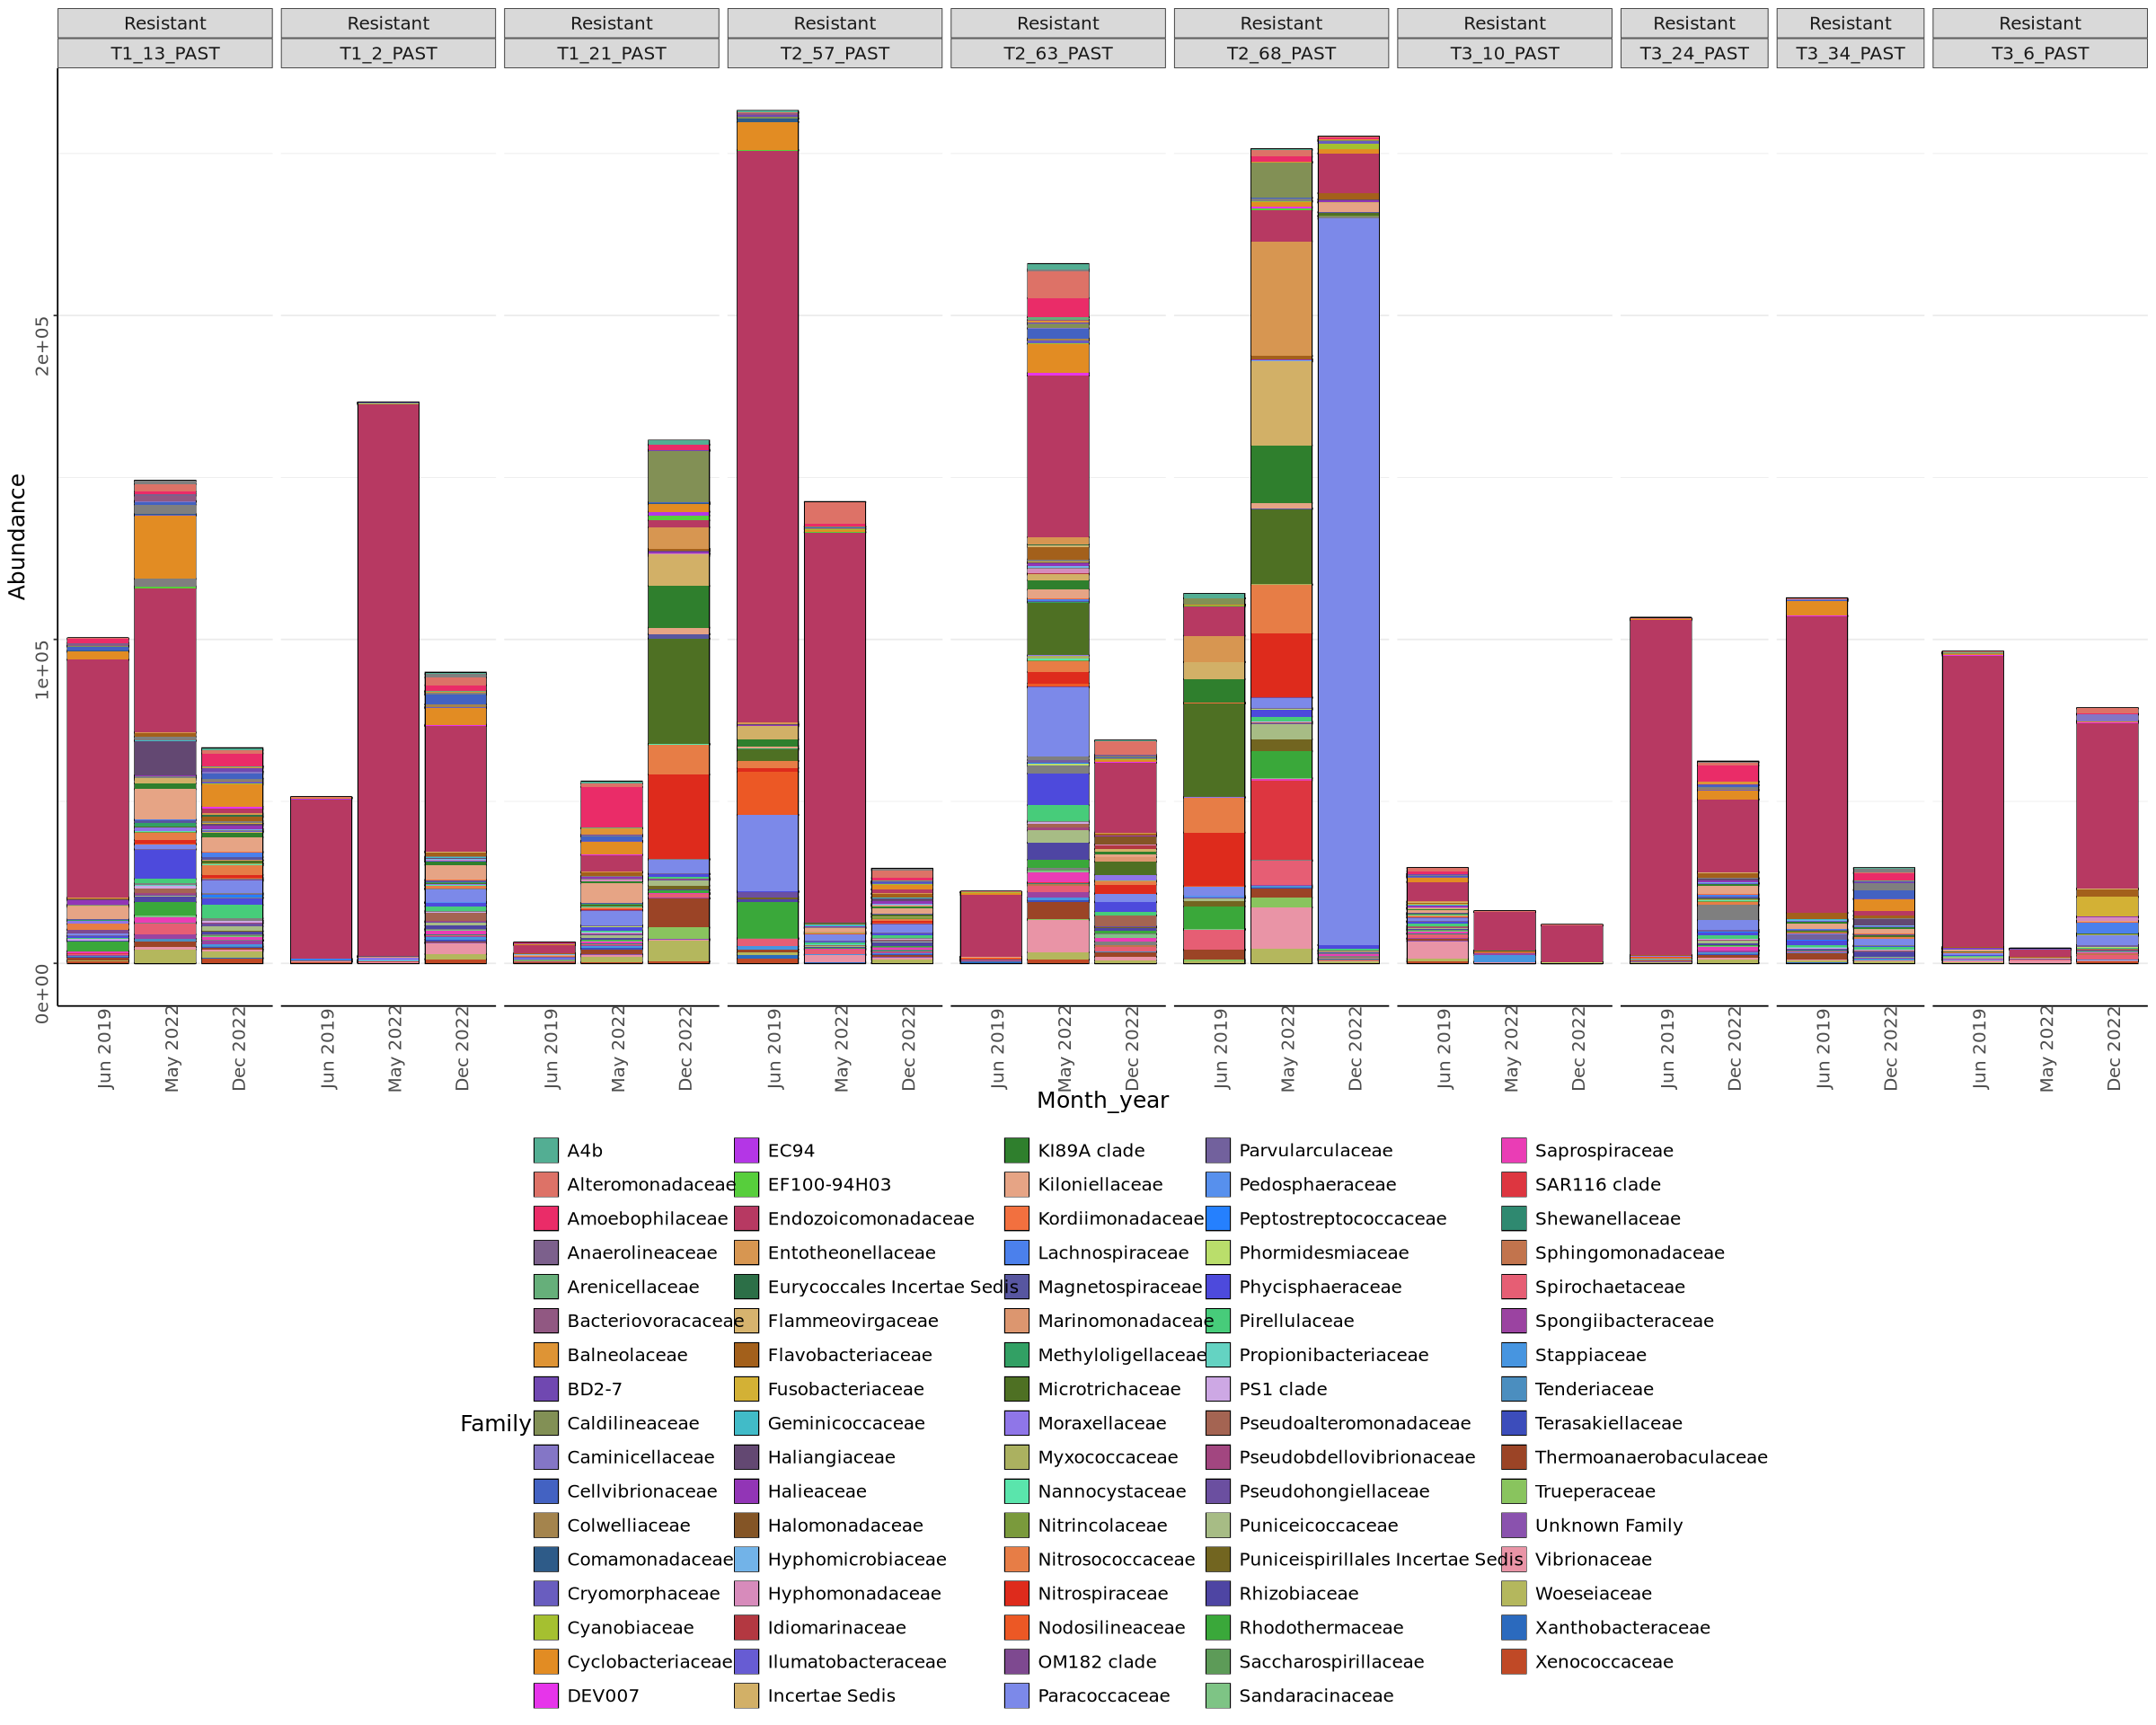

In [106]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(past_100_2019,x = "Month_year",fill='Family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = Month_year,fill=Family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# abundances - top 100 OTUs (Family)

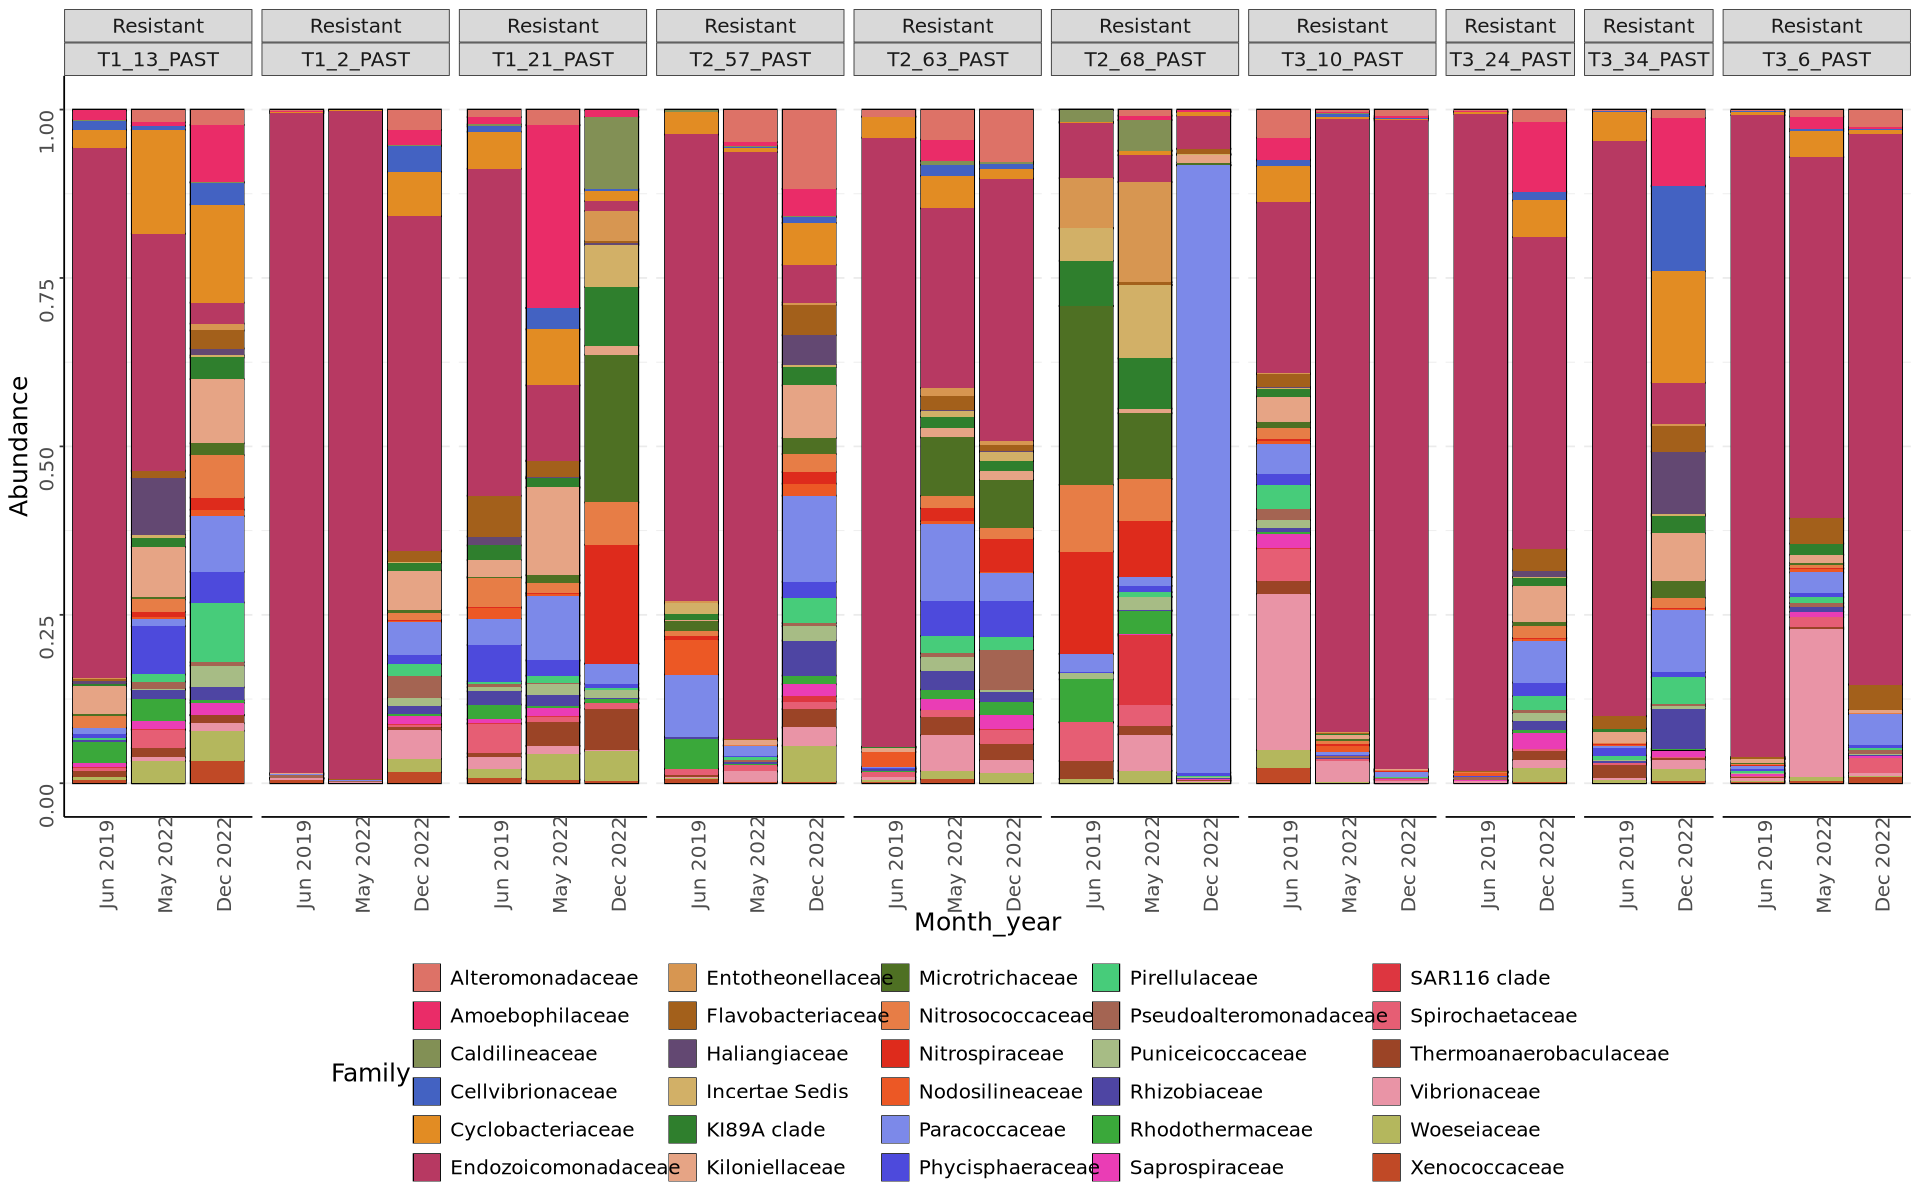

In [107]:
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(past_30_2019_norm,x = "Month_year",fill='Family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = Month_year,fill=Family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 30 Family - R vs S. individuals over time 

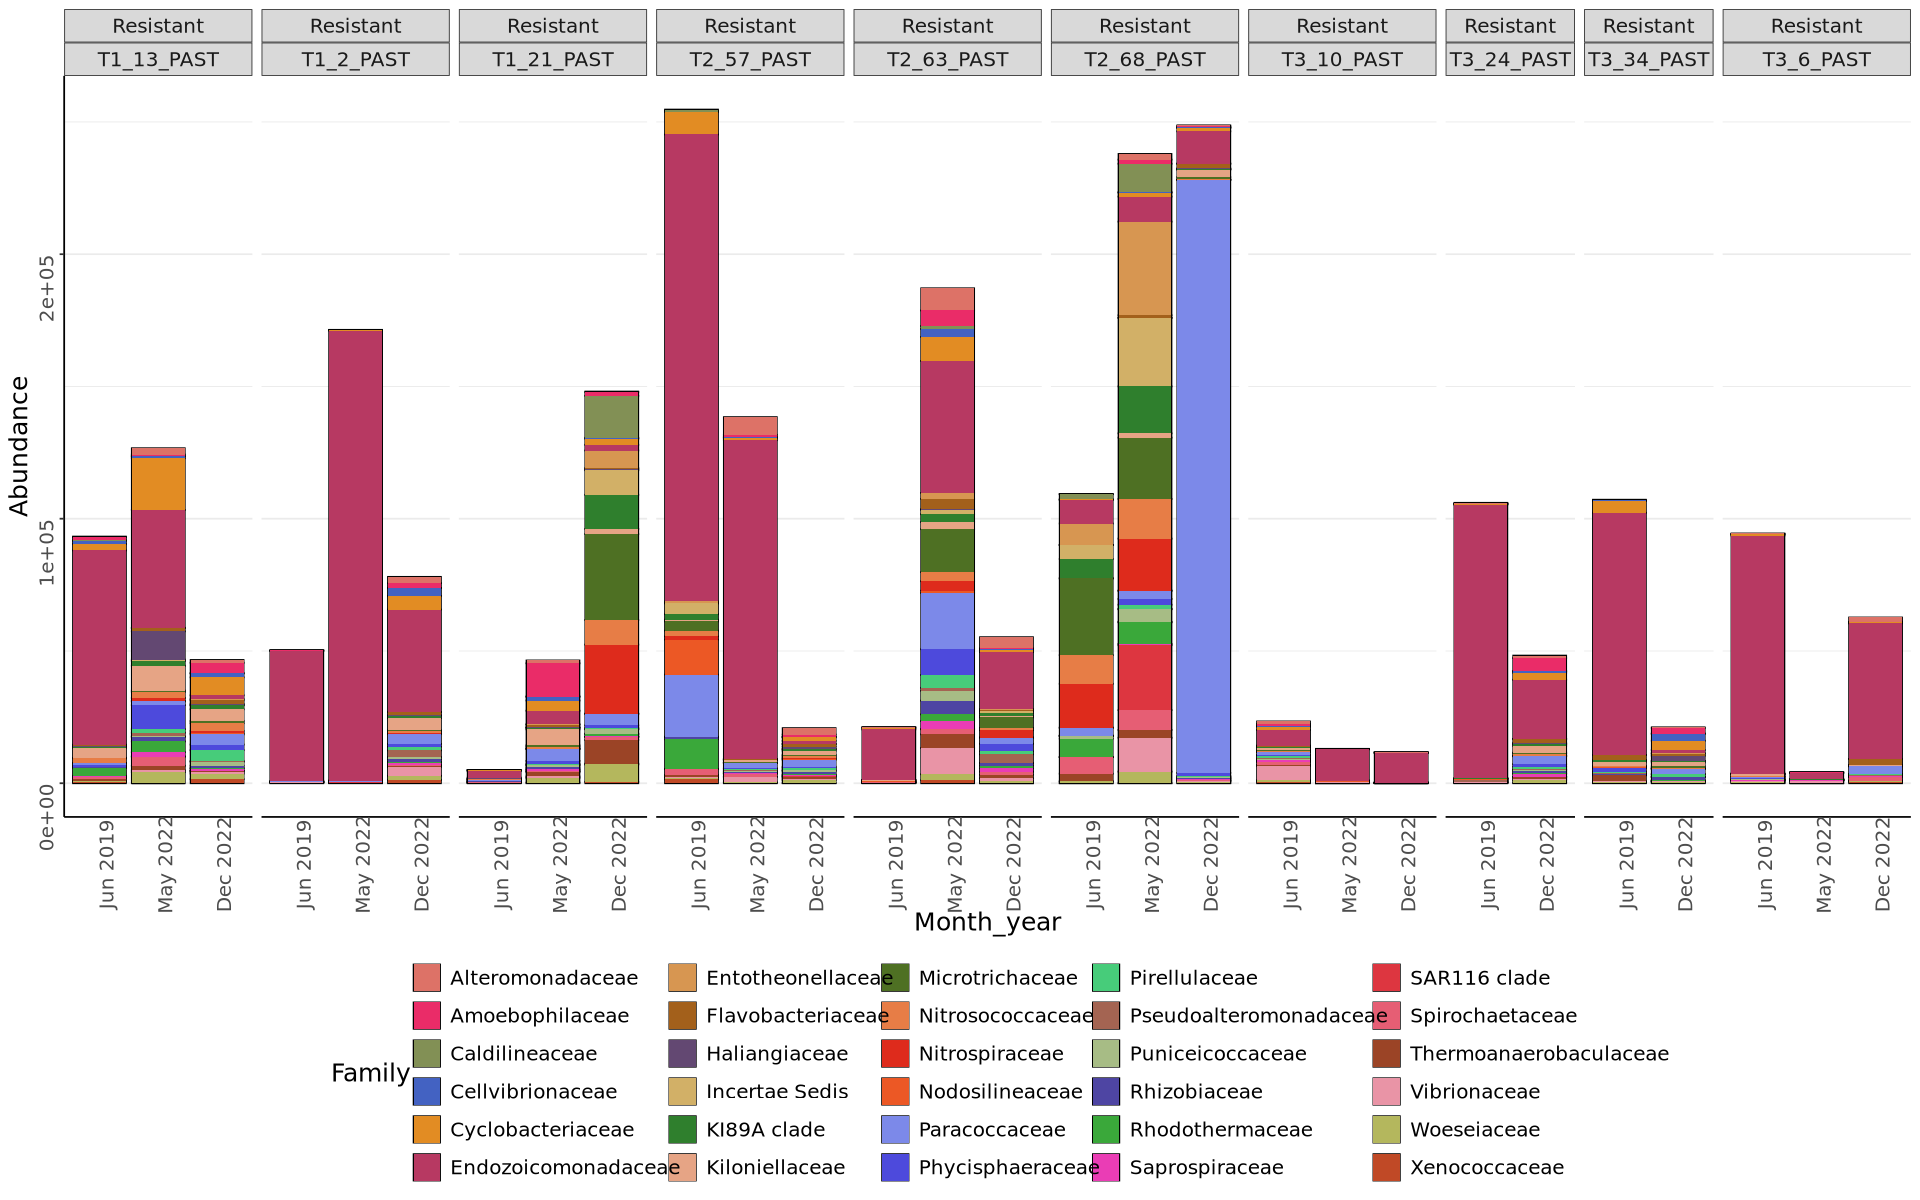

In [108]:
p<-plot_bar(past_30_2019,x = "Month_year",fill='Family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = Month_year,fill=Family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# abundances - top 30 OTUs (Family)

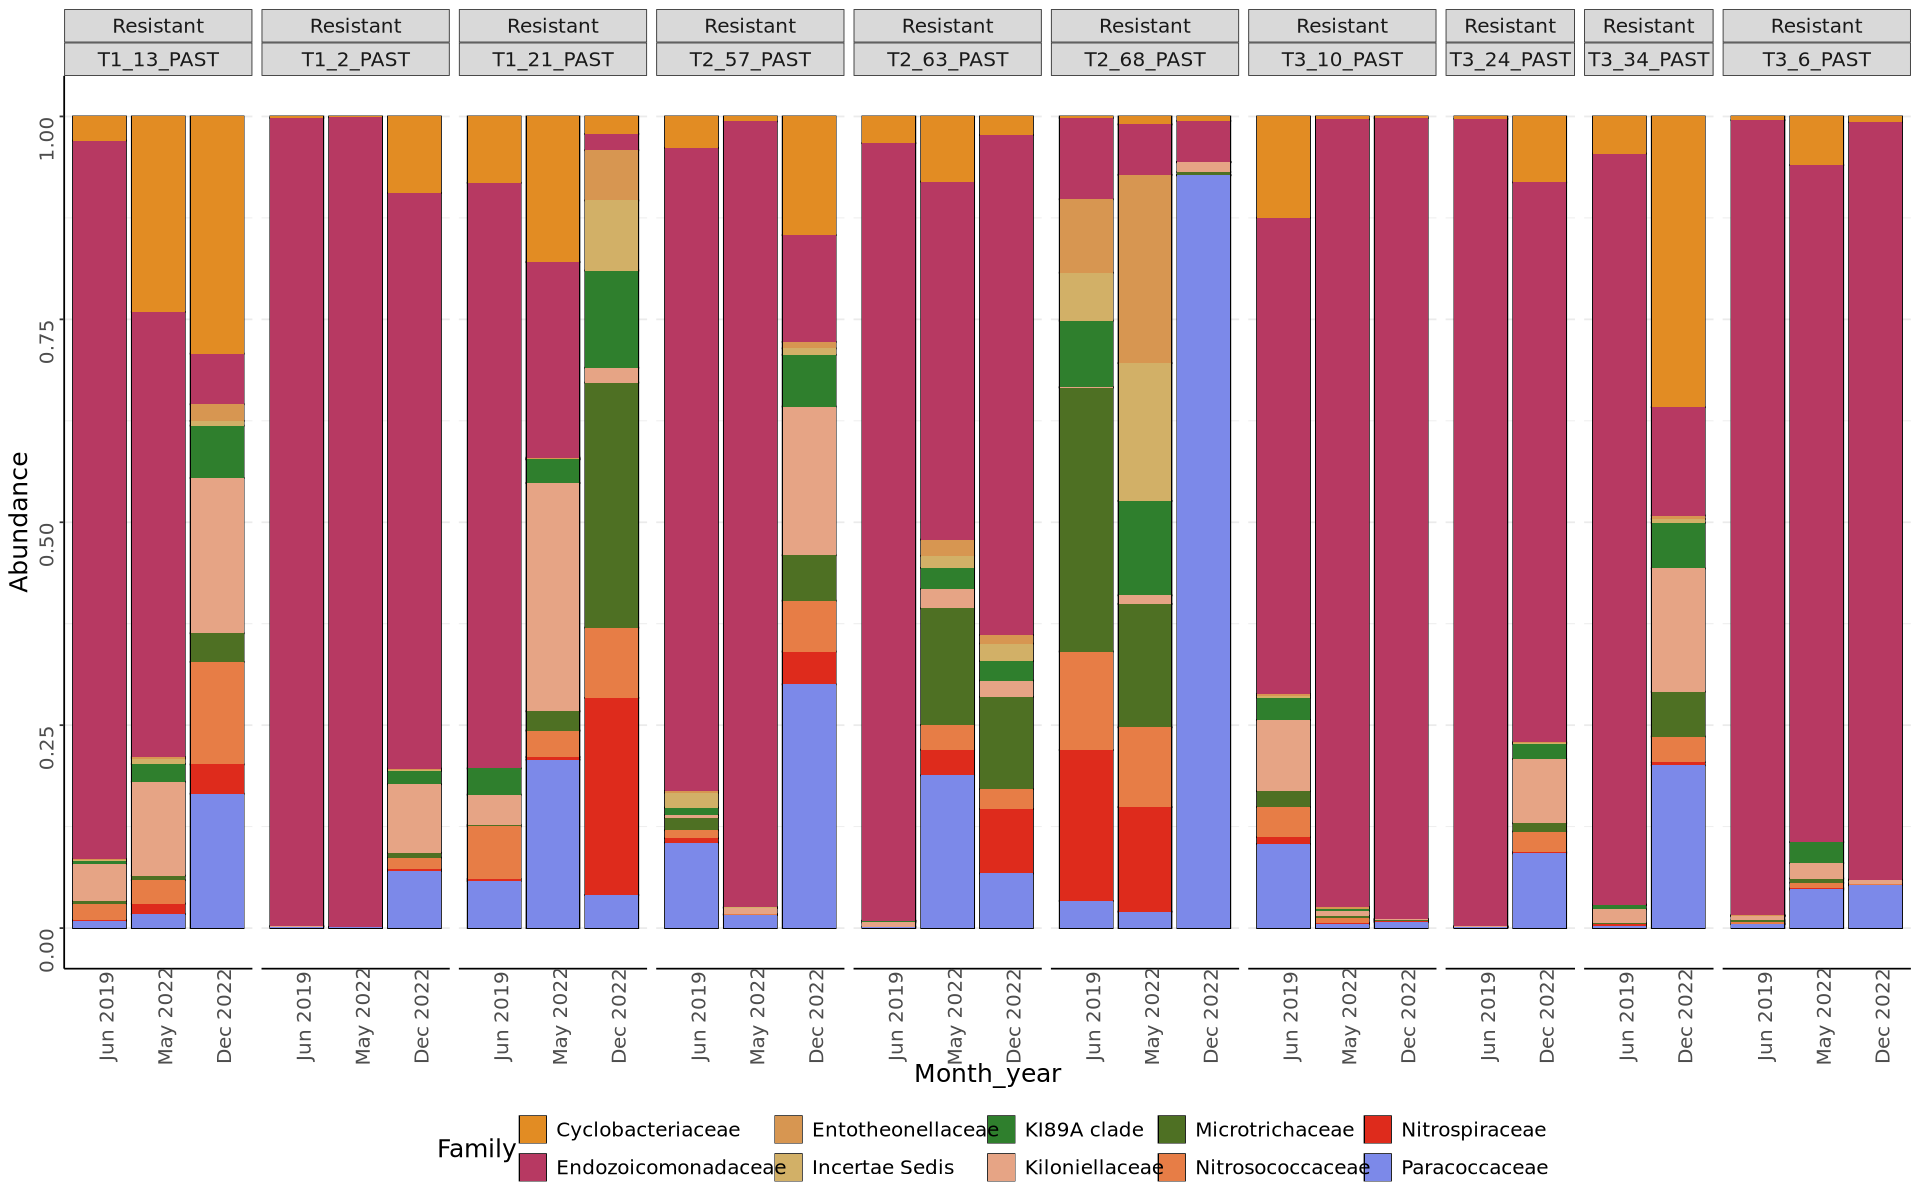

In [109]:
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(past_10_2019_norm,x = "Month_year",fill='Family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = Month_year,fill=Family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 10 OTUs (species)

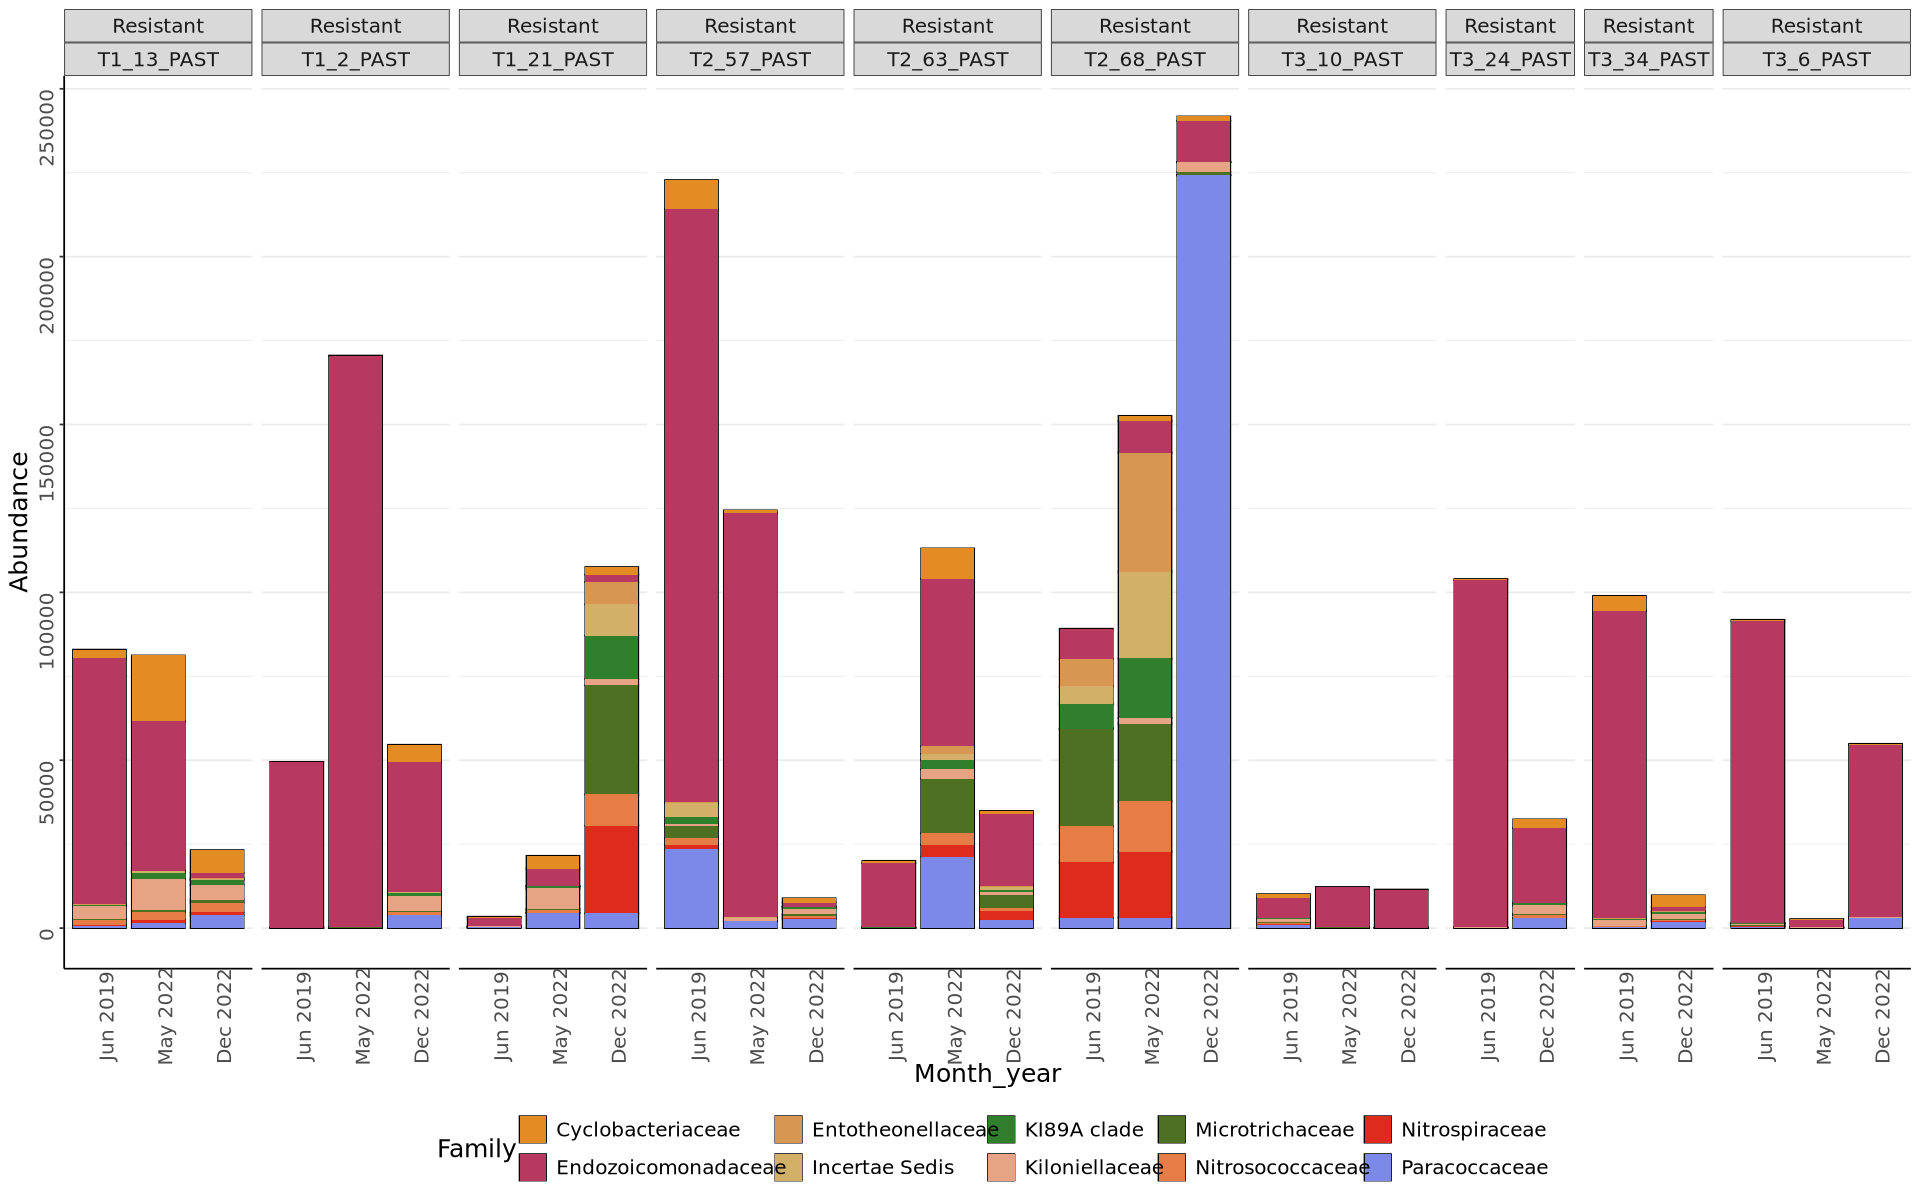

In [110]:
p<-plot_bar(past_10_2019,x = "Month_year",fill='Family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = Month_year,fill=Family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# abundances - top 10 OTUs (species)